In [1]:
%load_ext autoreload
%autoreload 2

from scripts.lattice import *
from scripts.scba import *
from scripts.plot import *
from scripts.obs import *
from scripts.utils import *
from triqs.gf import *
from triqs.lattice.tight_binding import dos

dim = 3
save_dir = f'data/{dim}d/rpa_ba'

Starting serial run at: 2026-09-02 19:47:54.273697


In [4]:
lat = LATTICE(dim=2)
nk = 200

lat.get_bz(nk, ibz=False)
lat.get_e_k()

kx = lat.k_vecs[:,0].reshape(nk,nk)
ky = lat.k_vecs[:,1].reshape(nk,nk)
e_k = lat.e_k.reshape(nk,nk)

kx -= np.pi
ky -= np.pi
e_k = np.roll(np.roll(e_k, nk//2, axis=0), nk//2, axis=1)

Gamma = 0.1
mu = get_mu(e_k=lat.e_k, n_goal=0.75, beta=1/0.01)
A_k0 = (1/np.pi) * Gamma / (Gamma**2 + (e_k - mu)**2)

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

cf = axs[0].contourf(kx, ky, e_k, levels=50)
plt.colorbar(cf, ax=axs[0], label=r'$\varepsilon(\mathbf{k})$')
axs[0].contour(kx, ky, e_k, levels=[mu], colors='black', linewidths=2)

cf = axs[1].contourf(kx, ky, A_k0, levels=50, cmap='hot')
plt.colorbar(cf, ax=axs[1], label=r'$A(\omega=0, \mathbf{k})$')

for ax in axs:
    ax.set_xlabel(r'$k_x$')
    ax.set_ylabel(r'$k_y$')
    ax.set_xticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi], labels=[r'$-\pi$', r'$-\pi/2$', '0', r'$\pi/2$', r'$\pi$'])
    ax.set_yticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi], labels=[r'$-\pi$', r'$-\pi/2$', '0', r'$\pi/2$', r'$\pi$'])
    ax.set_aspect('equal')

plt.tight_layout()
plt.show()

KeyboardInterrupt: 

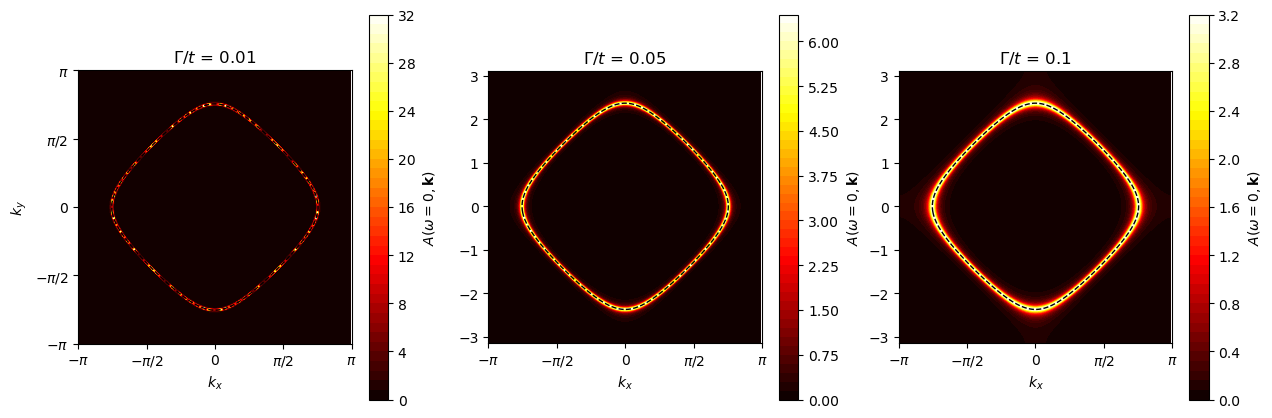

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

Gamma_list = [0.01, 0.05, 0.1]
for i, Gamma in enumerate(Gamma_list):

    lat = LATTICE(dim=2)
    nk = 200

    lat.get_bz(nk, ibz=False)
    lat.get_e_k()

    kx = lat.k_vecs[:,0].reshape(nk,nk)
    ky = lat.k_vecs[:,1].reshape(nk,nk)
    e_k = lat.e_k.reshape(nk,nk)

    kx -= np.pi
    ky -= np.pi
    e_k = np.roll(np.roll(e_k, nk//2, axis=0), nk//2, axis=1)

    T = 0.01
    mu = get_mu(e_k=lat.e_k, n_goal=0.75, beta=1/0.01)
    A_k0 = (1/np.pi) * Gamma / (Gamma**2 + (e_k - mu)**2)

    cf = axs[i].contourf(kx, ky, A_k0, levels=50, cmap='hot')
    plt.colorbar(cf, ax=axs[i], label=r'$A(\omega=0, \mathbf{k})$')
    axs[i].contour(kx, ky, e_k, levels=[mu], colors='black', linewidths=1)

    axs[i].set_title(f"$\Gamma/t$ = {Gamma}")

    axs[i].set_xlabel(r'$k_x$')
    axs[i].set_xticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi], labels=[r'$-\pi$', r'$-\pi/2$', '0', r'$\pi/2$', r'$\pi$'])
    axs[i].set_aspect('equal')

axs[0].set_ylabel(r'$k_y$')
axs[0].set_yticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi], labels=[r'$-\pi$', r'$-\pi/2$', '0', r'$\pi/2$', r'$\pi$'])

plt.show()

Gamma =  0.1


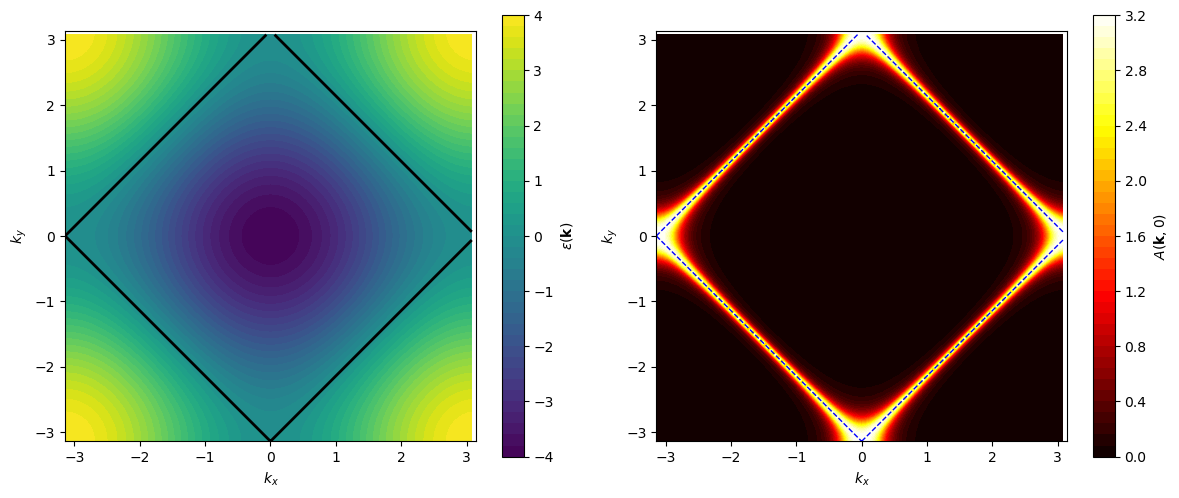

In [ ]:
square = LATTICE(dim=2, tp=0.)
nk = 100

square.get_e_k(nk)
eps = square.e_k.data[:, 0, 0].real
eps = eps.reshape(nk, nk)
eps = np.roll(np.roll(eps, nk//2, axis=0), nk//2, axis=1)

_, k_arr = square.get_k_mesh(nk)
kx = k_arr[:, 0].reshape(nk, nk) - np.pi
ky = k_arr[:, 1].reshape(nk, nk) - np.pi


v = 1
rho = dos(square.H_r.tb, nk, n_eps=100, name='')[0]
rho_0 = np.interp(0.0, rho.eps, rho.rho)
Gamma = np.pi * v**2 * rho_0
Gamma = 0.1
print('Gamma = ', Gamma)

T = 0.1
n = 1
mu = get_mu(e_k=square.e_k, n_goal=n, beta=1/T)
Ak0 = (1/np.pi) * Gamma / (Gamma**2 + (eps - mu)**2)


fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
cf = ax.contourf(kx, ky, eps, levels=50)
plt.colorbar(cf, ax=ax, label=r'$\varepsilon(\mathbf{k})$')
ax.contour(kx, ky, eps, levels=[mu], colors='black', linewidths=2)
ax.set_xlim(-np.pi, np.pi)
ax.set_ylim(-np.pi, np.pi)
ax.set_xlabel(r'$k_x$')
ax.set_ylabel(r'$k_y$')
ax.set_aspect('equal')

ax = axes[1]
cf2 = ax.contourf(kx, ky, Ak0, levels=50, cmap='hot')
plt.colorbar(cf2, ax=ax, label=r'$A(\mathbf{k}, 0)$')
ax.contour(kx, ky, eps, levels=[mu], colors='blue', linewidths=1, linestyles='--')
ax.set_xlim(-np.pi, np.pi)
ax.set_ylim(-np.pi, np.pi)
ax.set_xlabel(r'$k_x$')
ax.set_ylabel(r'$k_y$')
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

[[0.         0.         0.01      ]
 [0.         0.         0.01      ]
 [0.         0.         0.01      ]
 [0.         0.         0.01      ]
 [0.         0.         0.01      ]
 [0.         0.         0.01      ]
 [0.         0.         0.01      ]
 [0.         0.         0.01      ]
 [0.         0.         0.0112652 ]
 [0.         0.         0.01296234]
 [0.         0.         0.01482997]
 [0.         0.         0.01686813]
 [0.         0.         0.01913847]
 [0.         0.         0.02165289]
 [0.         0.         0.02451261]
 [0.         0.         0.02776097]
 [0.         0.         0.03150741]
 [0.         0.         0.03589467]
 [0.         0.         0.04111114]
 [0.         0.         0.04750792]
 [0.         0.         0.05546341]]


/home/carlo/Desktop/qc/scripts/plot.py:129: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


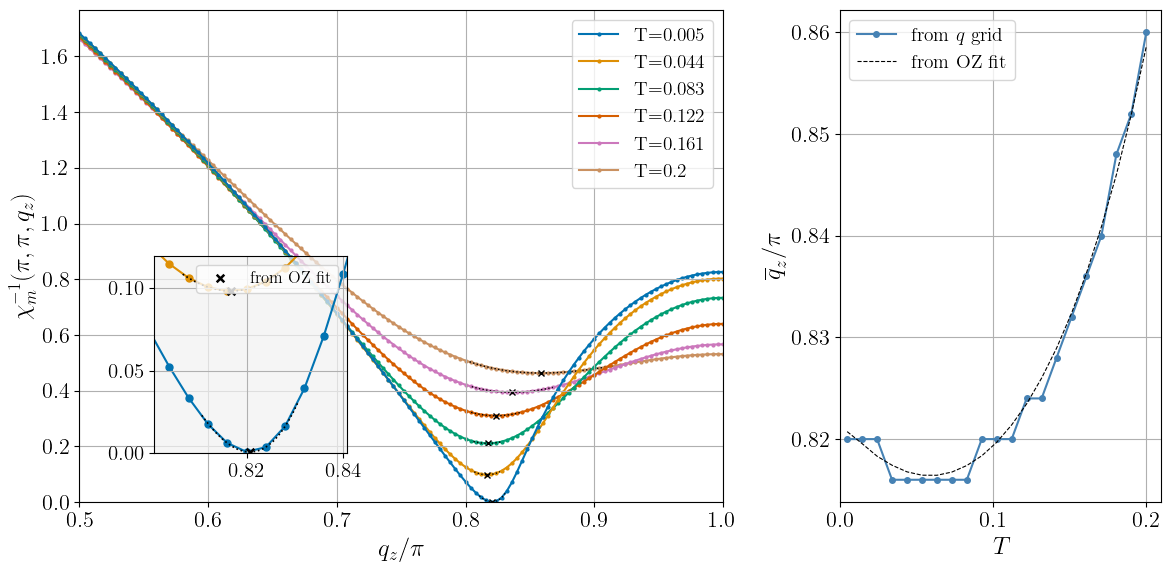

In [4]:
n = 0.851
U = 3

with HDFArchive(f"data/chimin/G0.05tp0n{n:.5g}U{U:.5g}.h5", "r") as ar:
    data = {k: ar[k] for k in ar}

print(data['xi_range'])
plot_chimin(data)
plt.show()

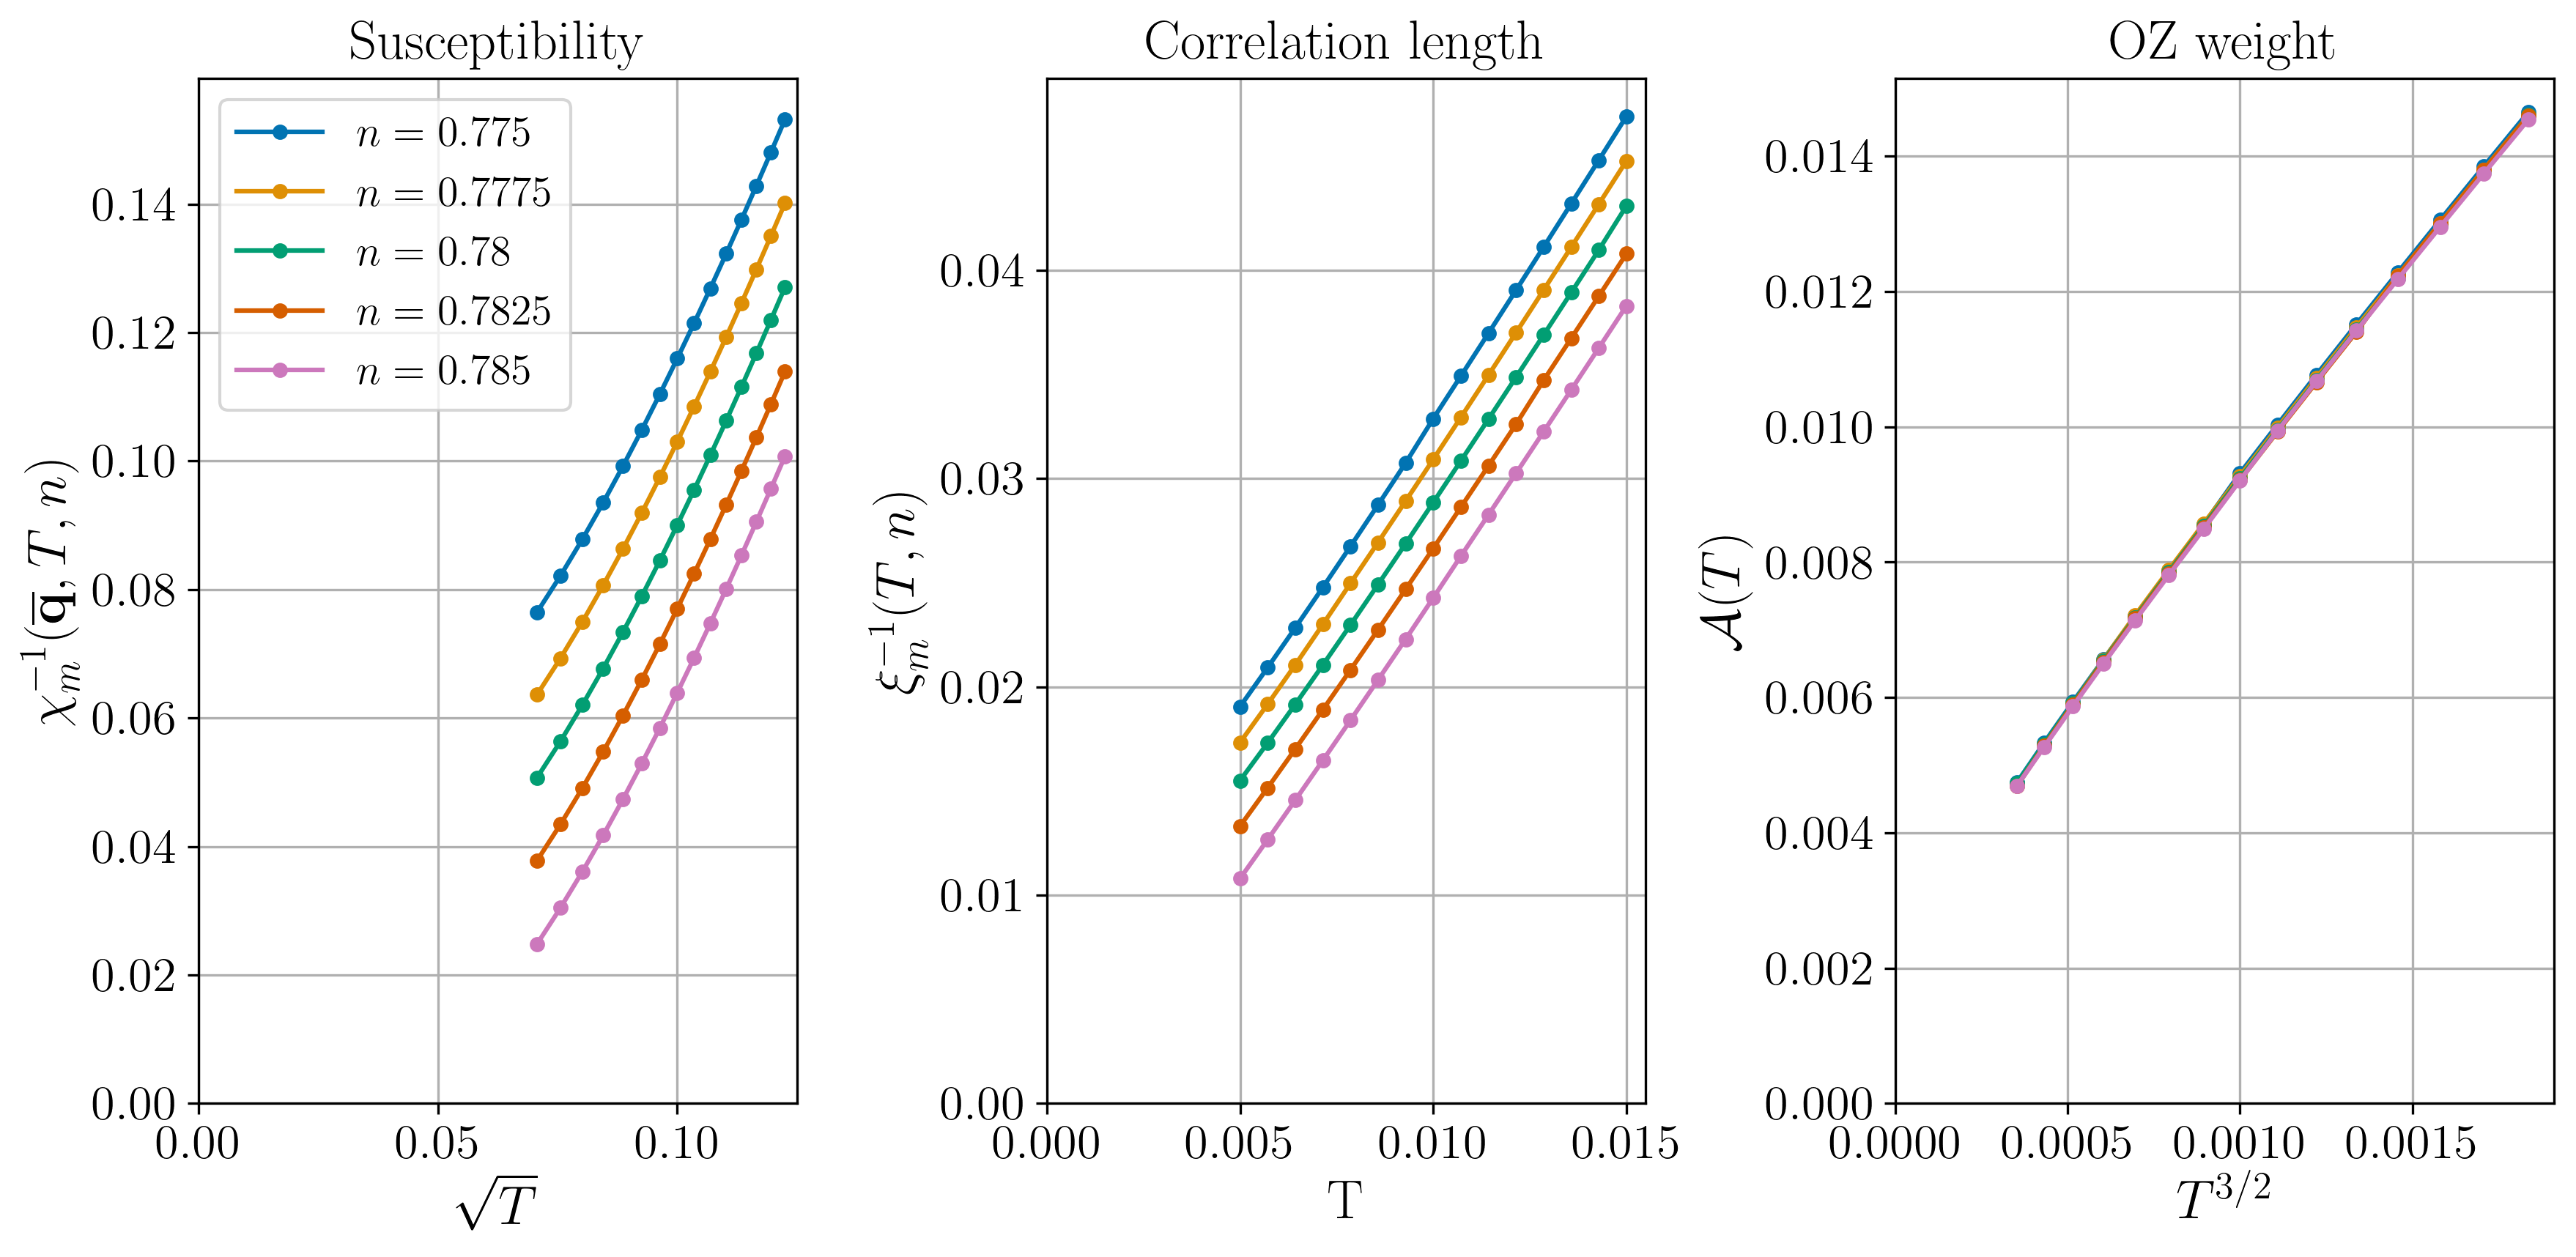

In [3]:
U = 3
Gamma = 0.005

data = {}
with HDFArchive(f"data/scaling/G{Gamma:.5g}tp0U{U:.5g}.h5", "r") as ar:
    data = {k: ar[k] for k in ar}

plot_scaling(data, x_exp=(0.5, 1, 1.5), fit=False, right='OZ')
plt.show()

In [ ]:
U = 3
Gamma = 0.01

data = {}
with HDFArchive(f"data/scaling/G{Gamma:.5g}tp0U{U:.5g}.h5", "r") as ar:
    data = {k: ar[k] for k in ar}

plot_scaling(data, x_exp=(0.5, 1, 1.5), fit=True, right='OZ')
plt.show()

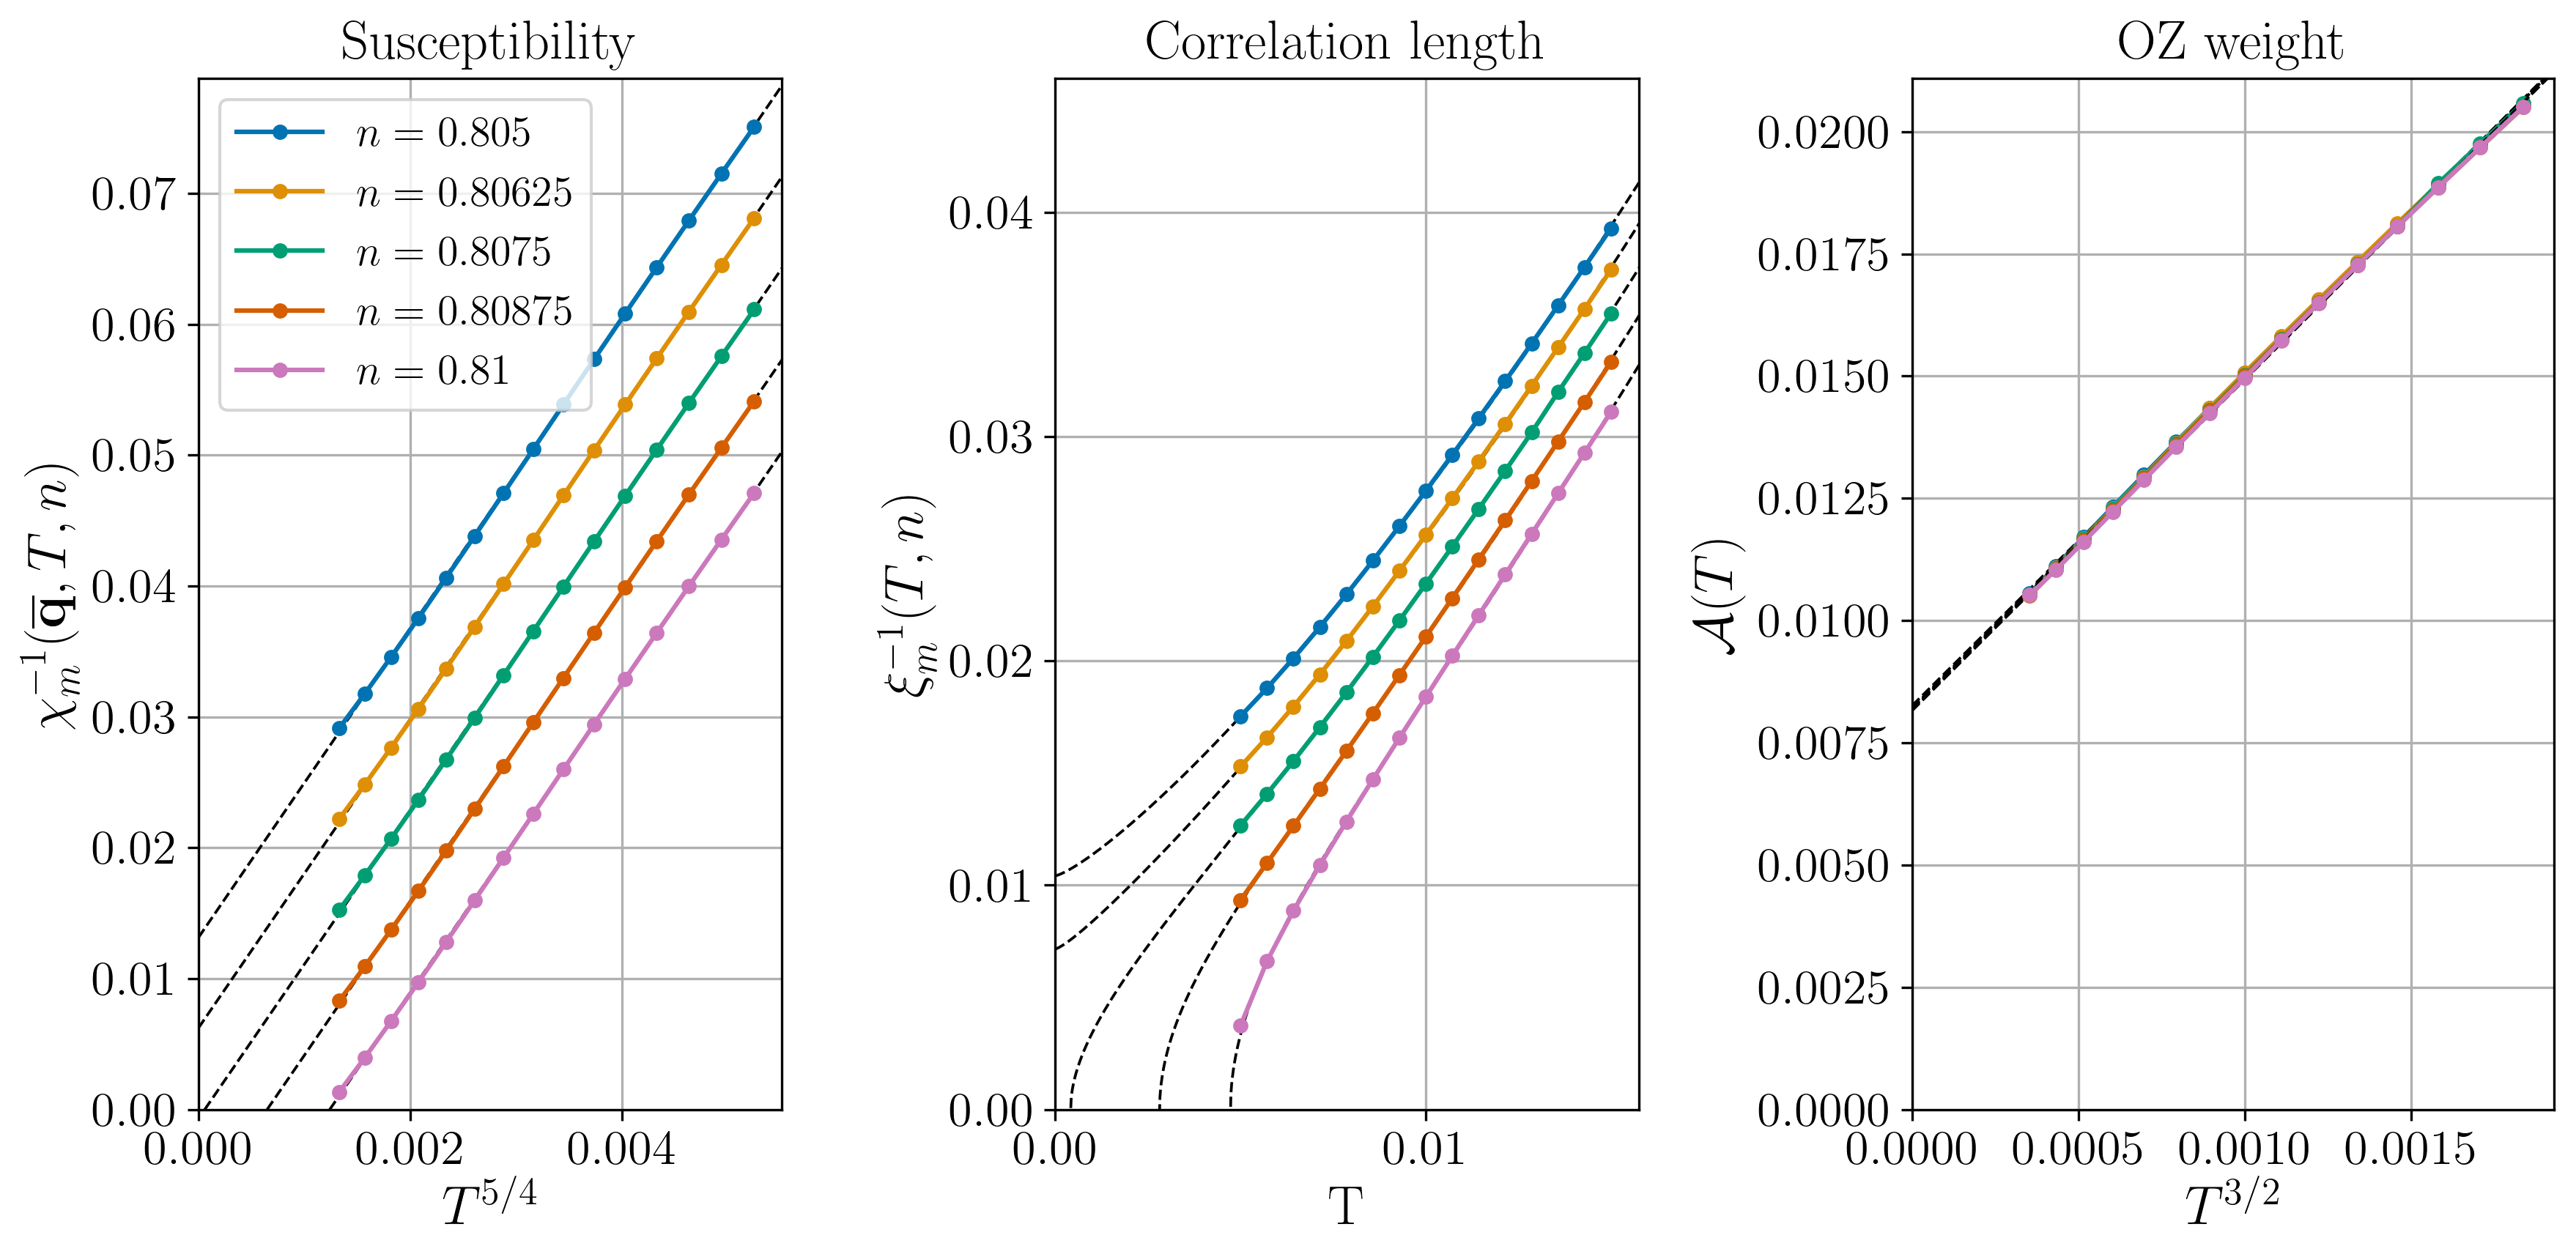

In [76]:
U = 3
Gamma = 0.015

data = {}
with HDFArchive(f"data/scaling/G{Gamma:.5g}tp0U{U:.5g}.h5", "r") as ar:
    data = {k: ar[k] for k in ar}

plot_scaling(data, x_exp=(1.25, 1, 1.5), fit=True, right='OZ')
plt.show()

In [ ]:
U = 3
Gamma = 0.02

data = {}
with HDFArchive(f"data/scaling/G{Gamma:.5g}tp0U{U:.5g}.h5", "r") as ar:
    data = {k: ar[k] for k in ar}

plot_scaling(data, x_exp=(0.5, 1, 1.5), fit=False, right='OZ')
plt.show()

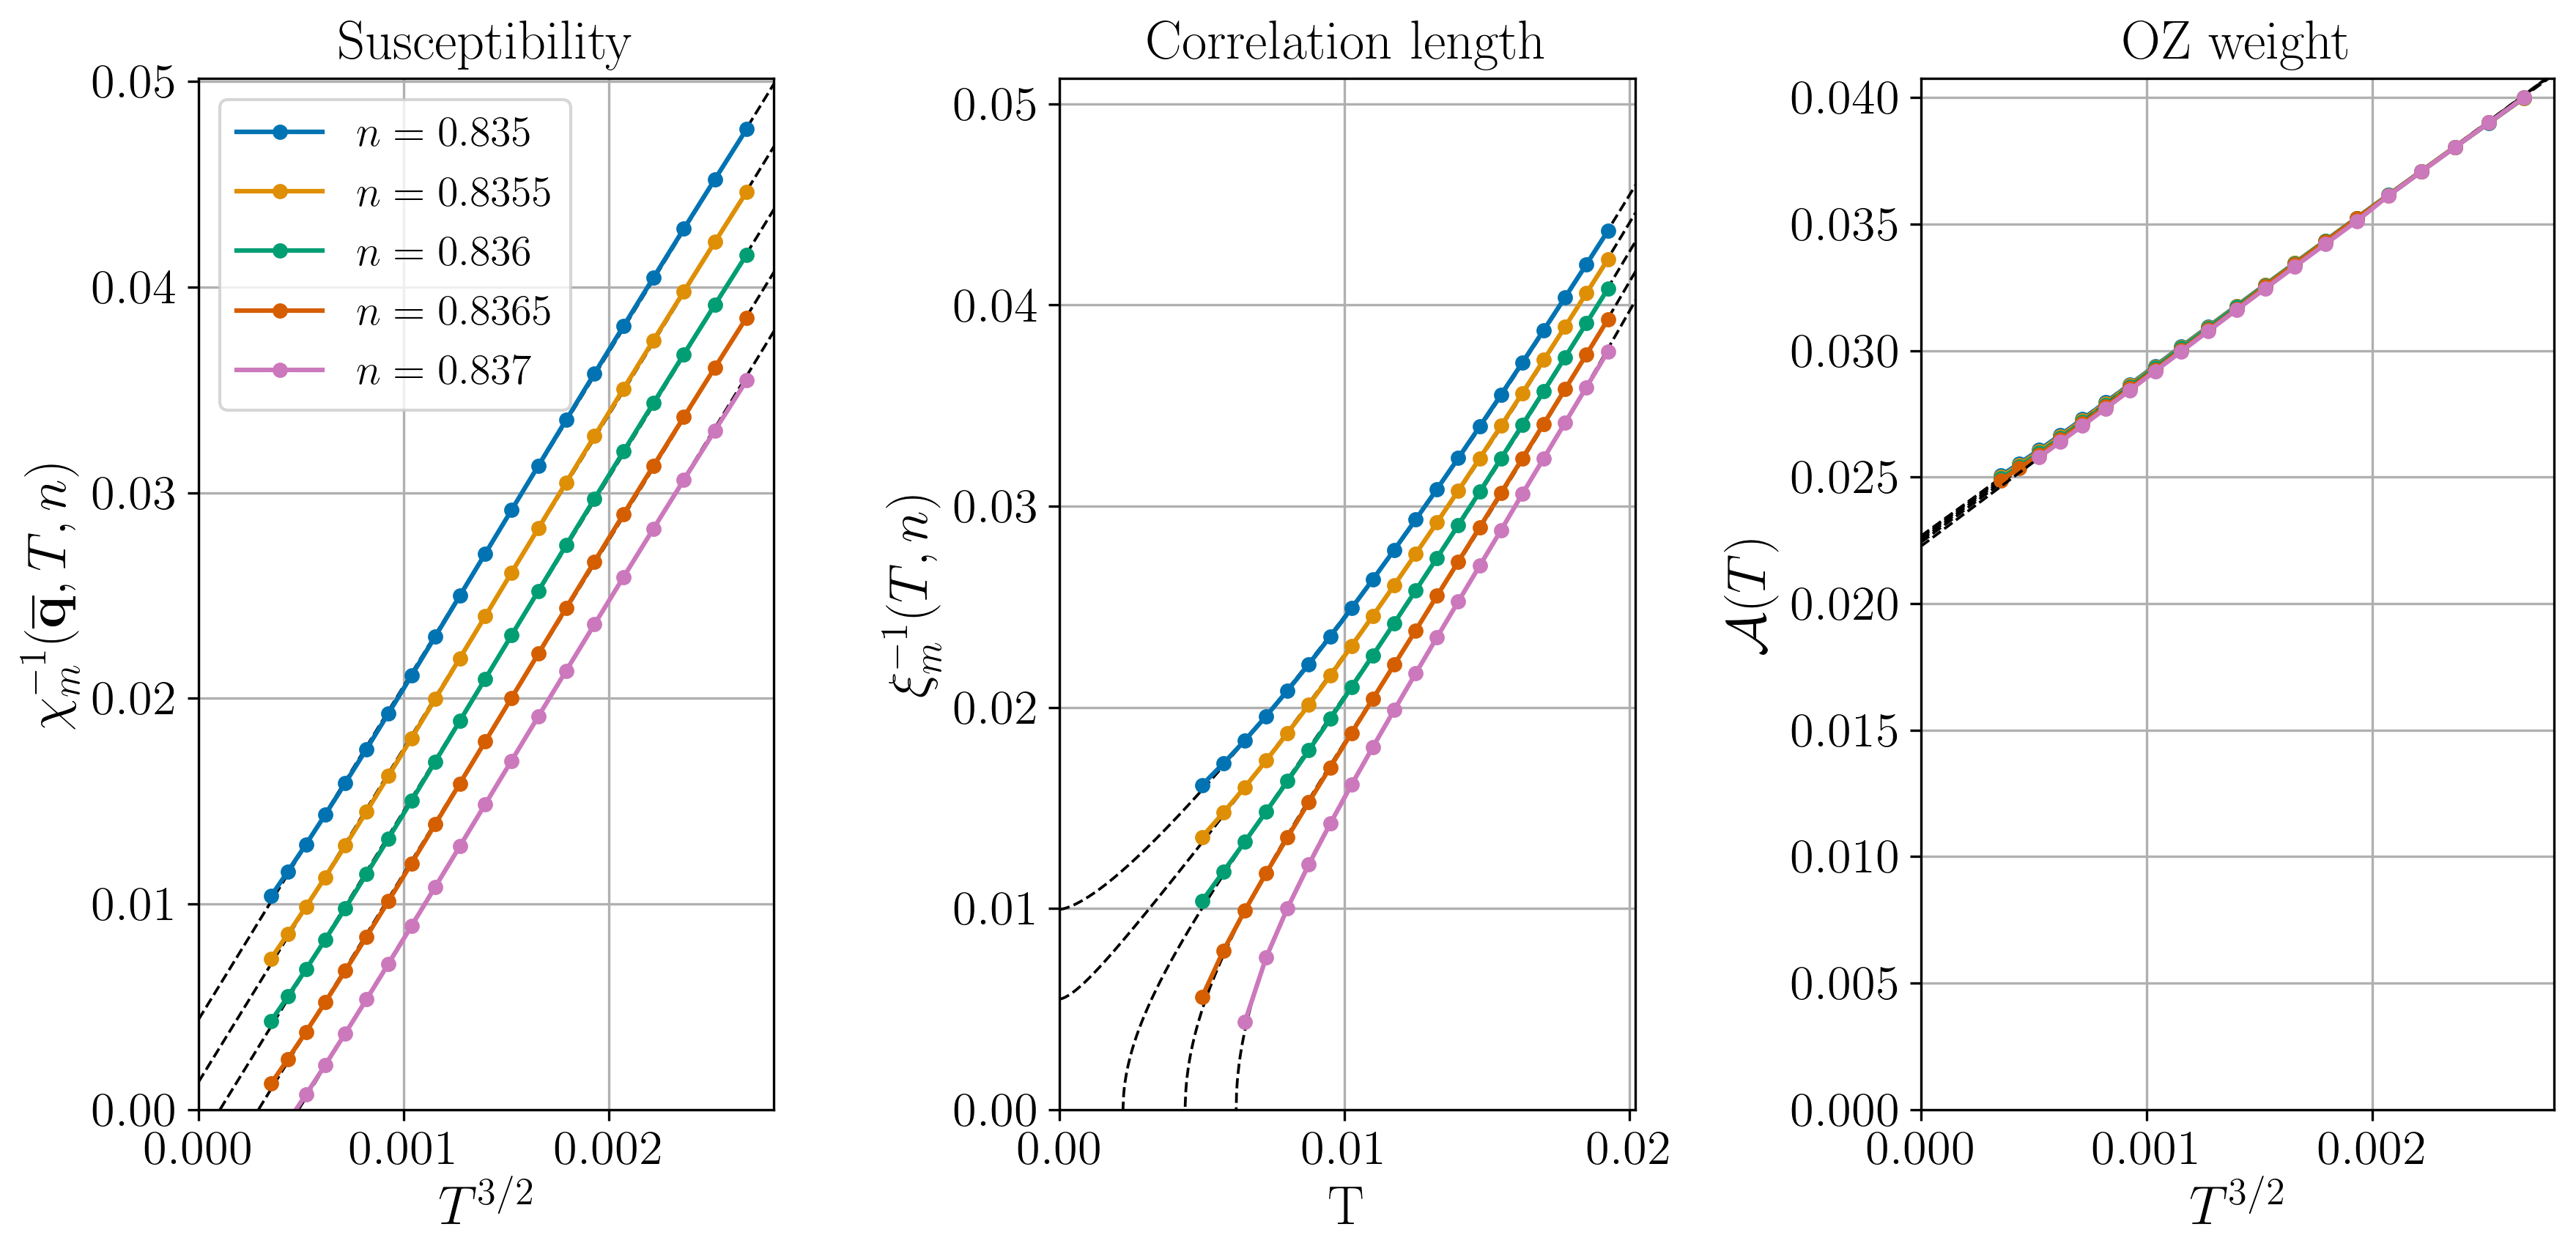

In [2]:
U = 3
Gamma = 0.035

data = {}
with HDFArchive(f"data/scaling/G{Gamma:.5g}tp0U{U:.5g}.h5", "r") as ar:
    data = {k: ar[k] for k in ar}

plot_scaling(data, x_exp=(1.5, 1, 1.5), fit=True, right='OZ')
plt.show()

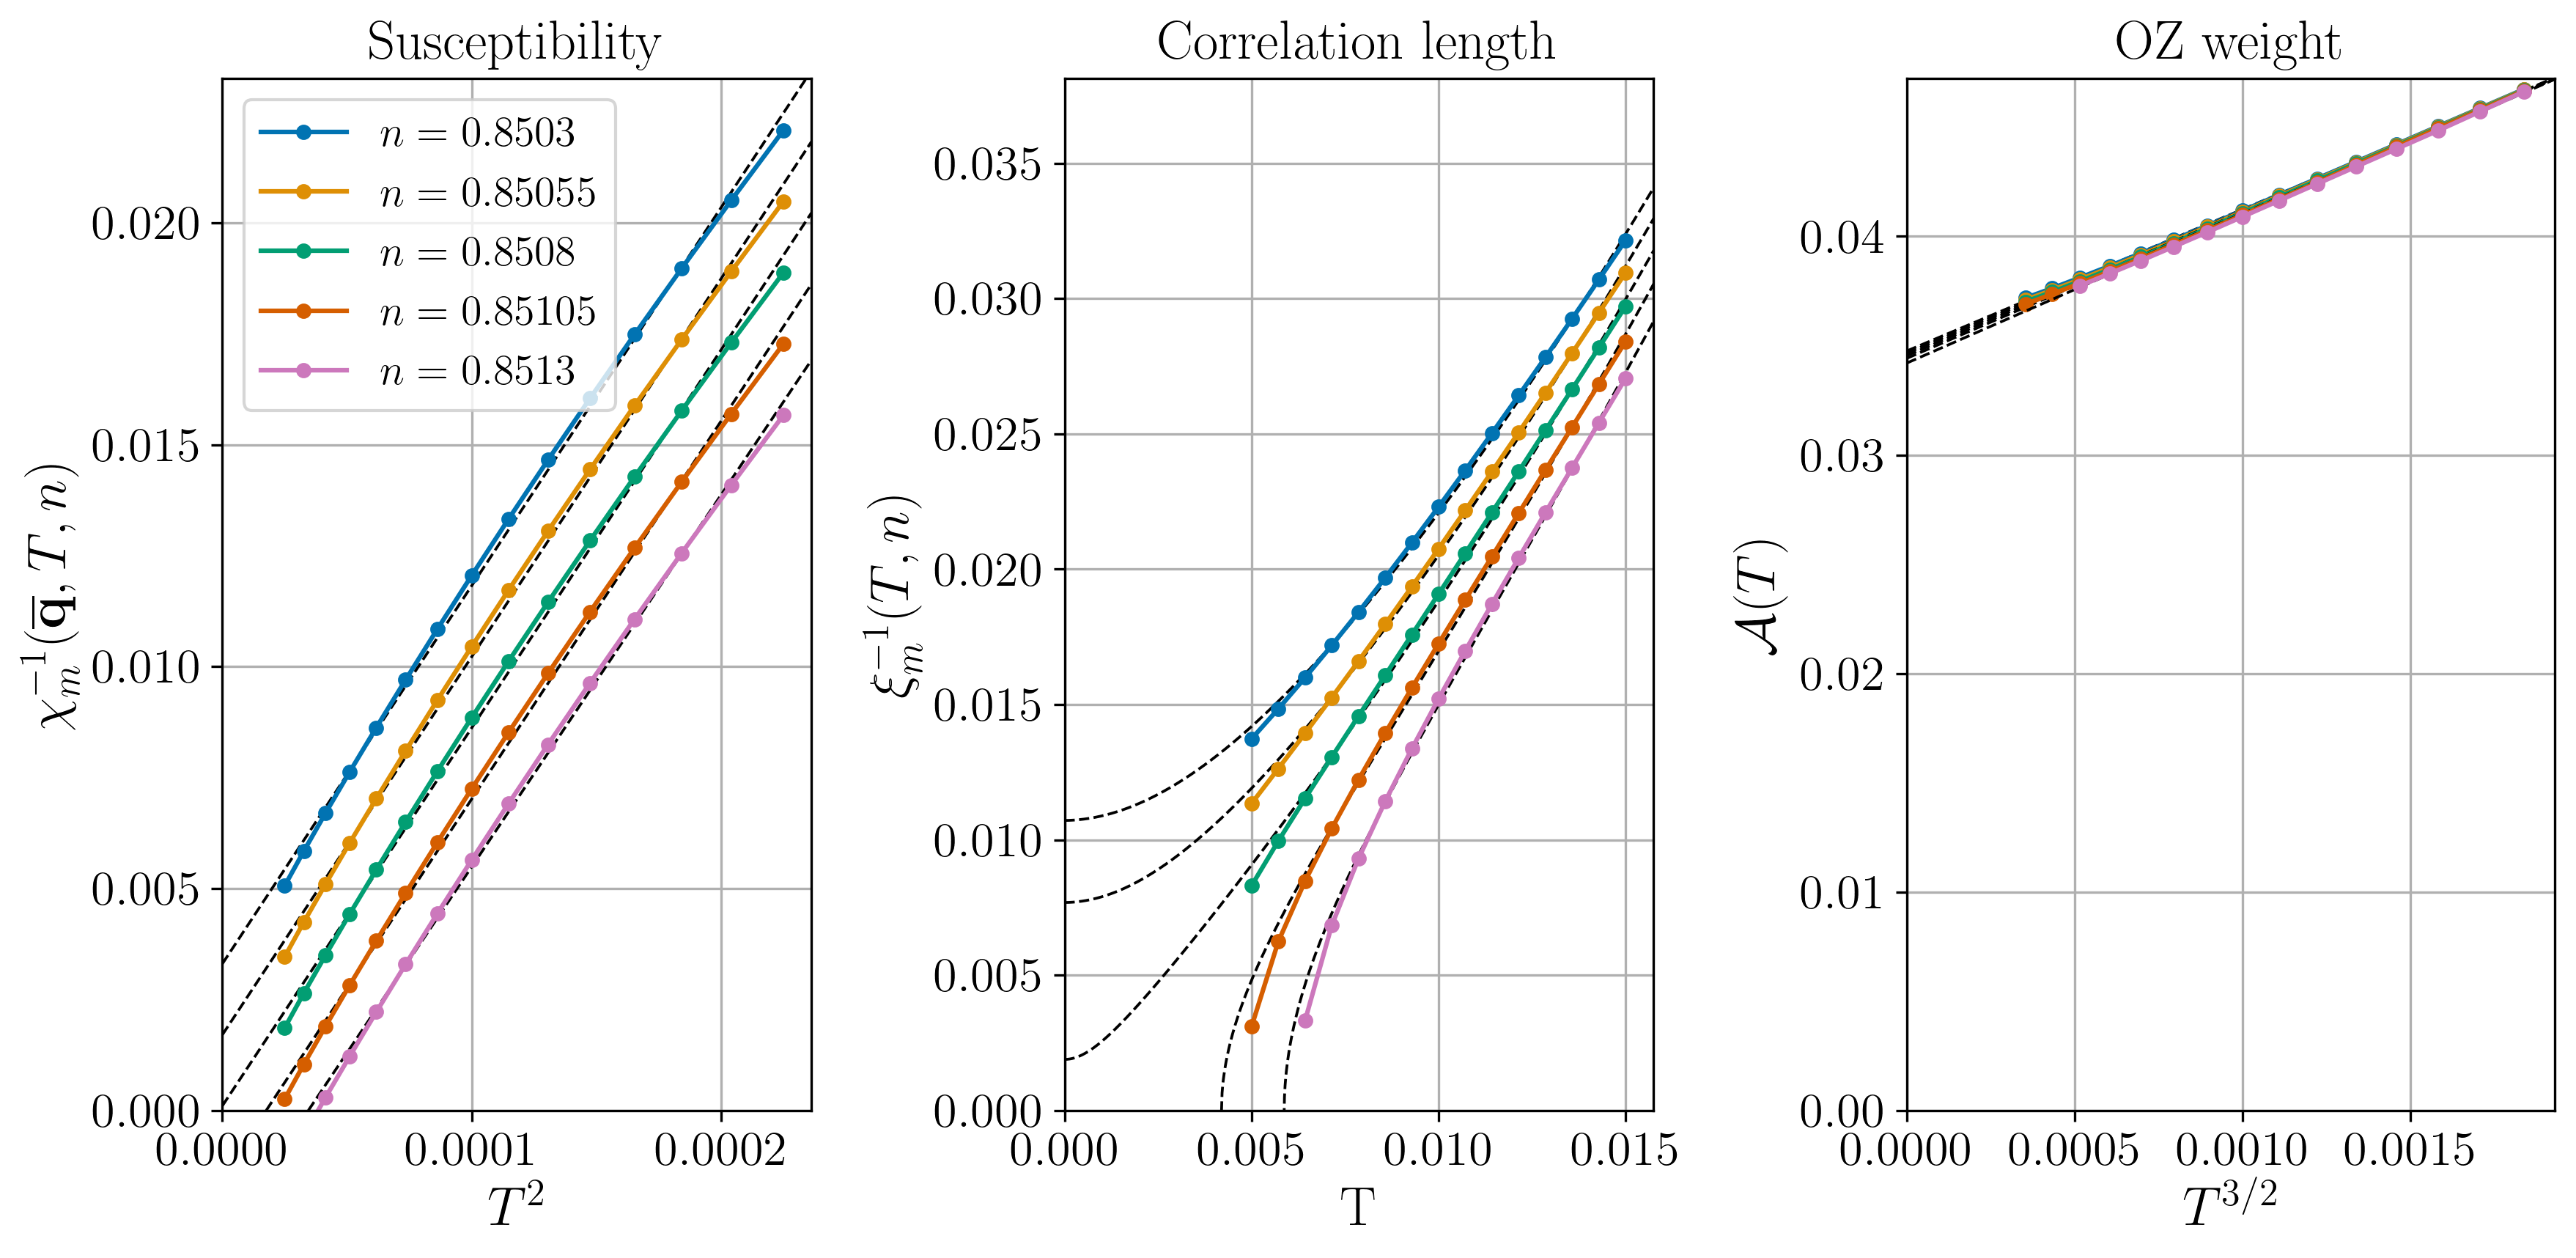

In [78]:
U = 3
Gamma = 0.05

data = {}
with HDFArchive(f"data/scaling/G{Gamma:.5g}tp0U{U:.5g}.h5", "r") as ar:
    data = {k: ar[k] for k in ar}

plot_scaling(data, x_exp=(2, 1, 1.5), fit=True, right='OZ')
plt.show()

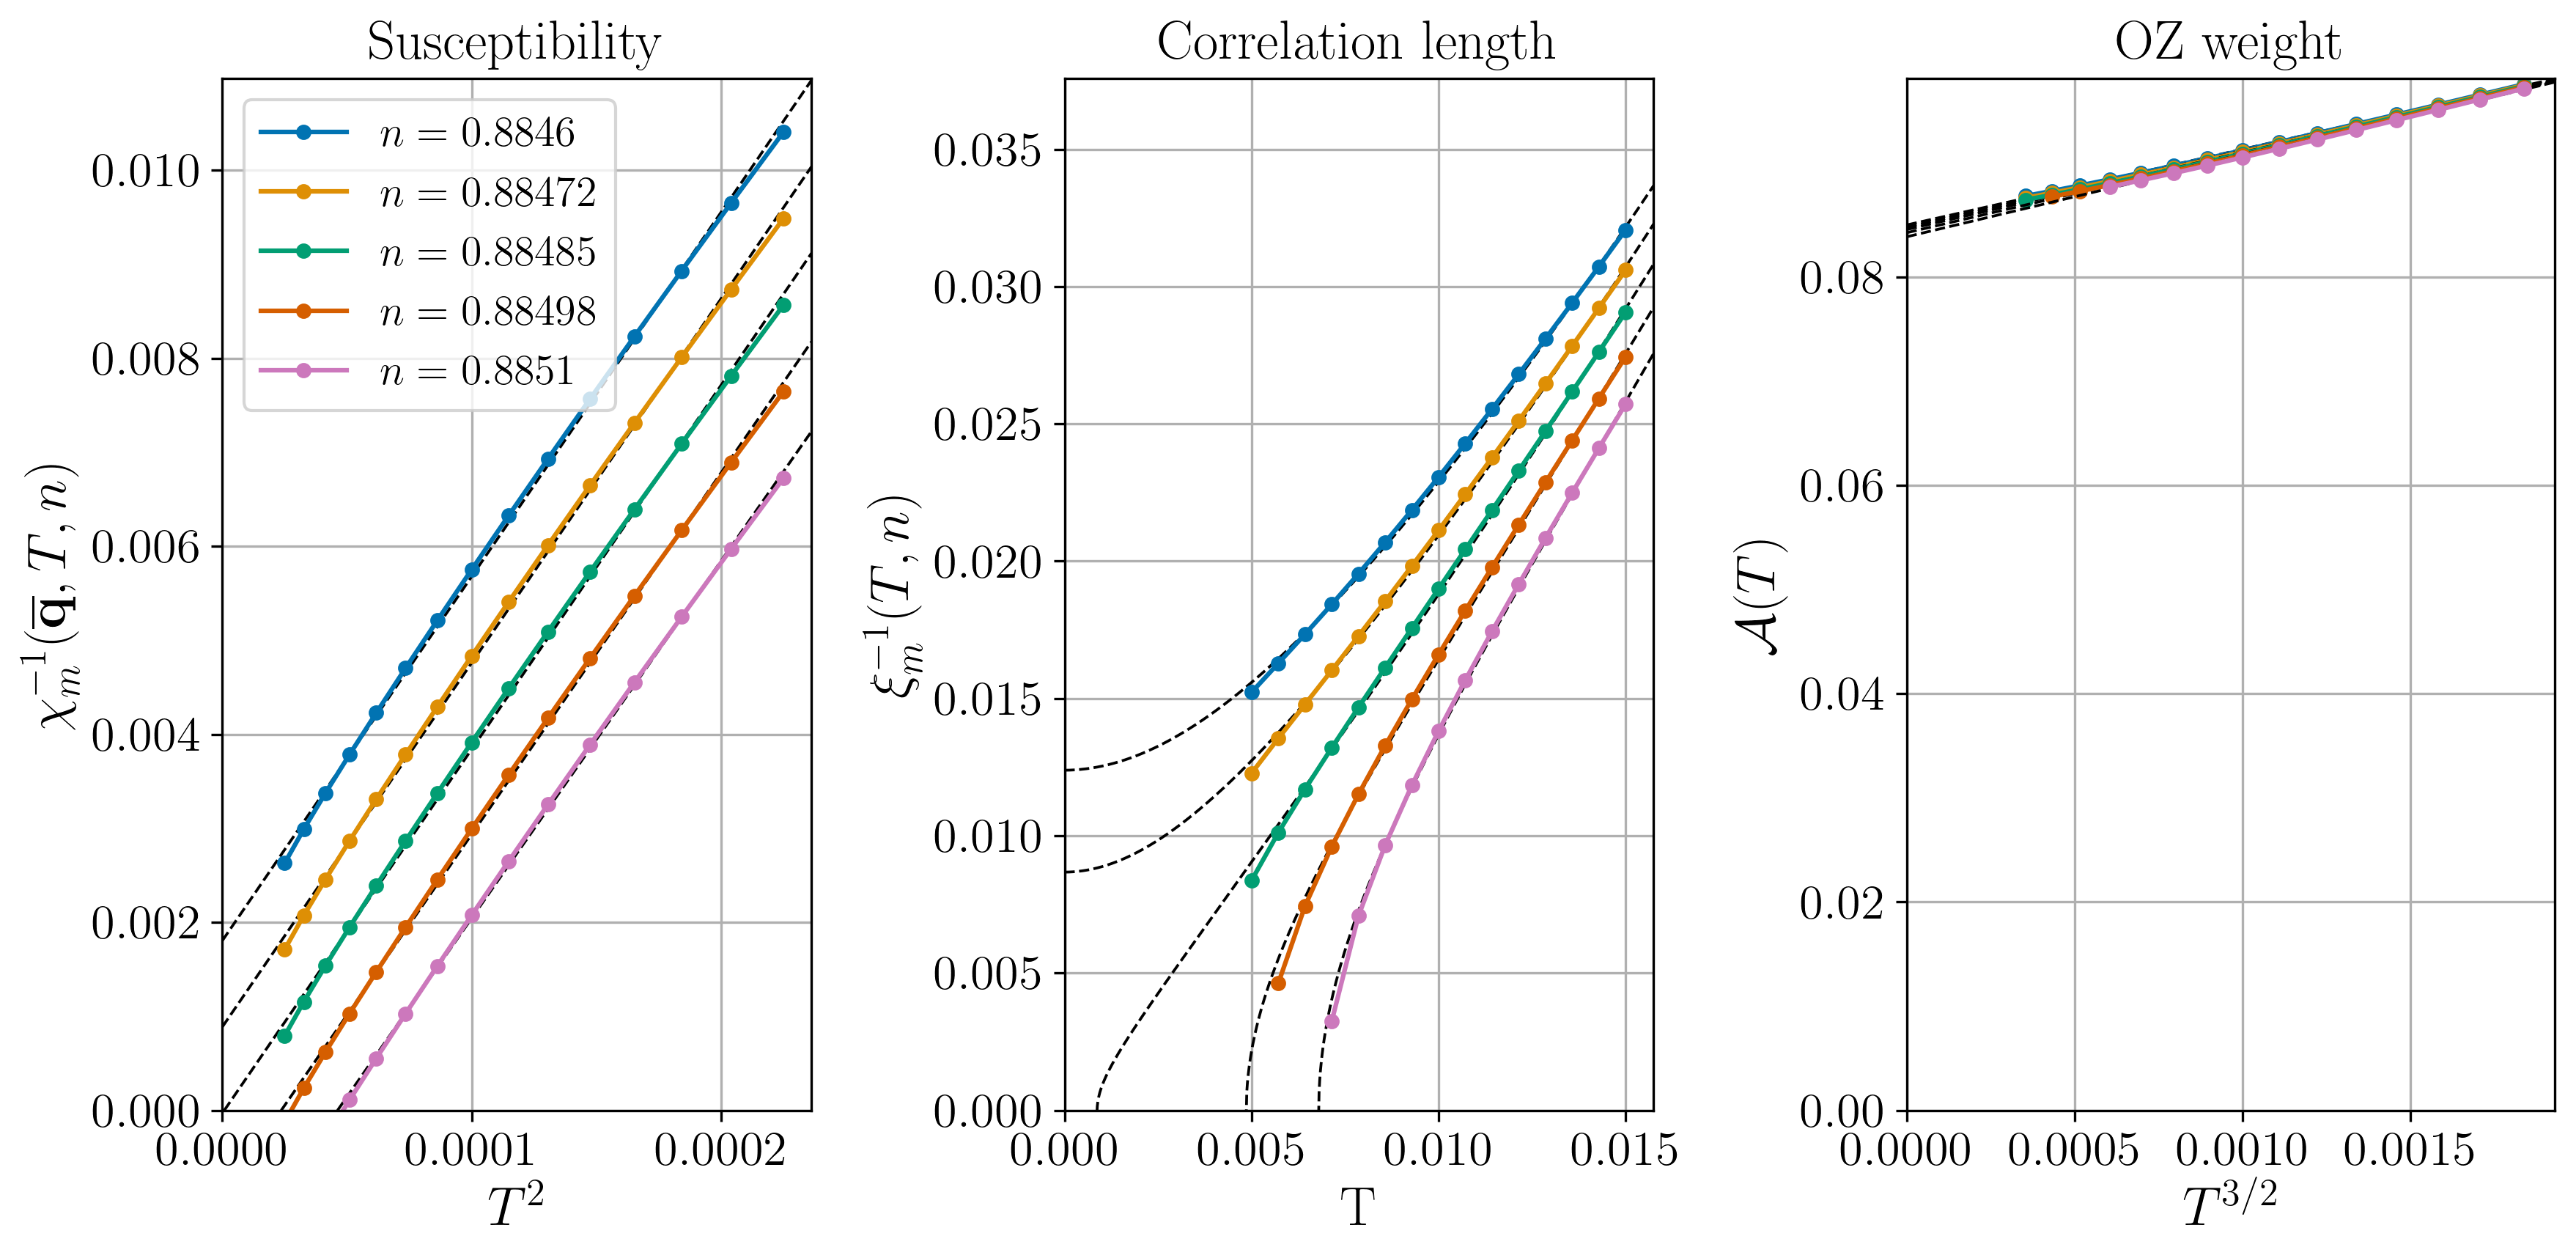

In [79]:
U = 3
Gamma = 0.1

data = {}
with HDFArchive(f"data/scaling/G{Gamma:.5g}tp0U{U:.5g}.h5", "r") as ar:
    data = {k: ar[k] for k in ar}

plot_scaling(data, x_exp=(2, 1, 1.5), fit=True, right='OZ')
plt.show()

/tmp/ipykernel_4281/371492169.py:51: OptimizeWarning: Covariance of the parameters could not be estimated
  par, _ = curve_fit(HMM, T[sl], invchi_nc[sl],
/tmp/ipykernel_4281/371492169.py:55: OptimizeWarning: Covariance of the parameters could not be estimated
  par, _ = curve_fit(HMM, T[sl], OZ_nc[sl],


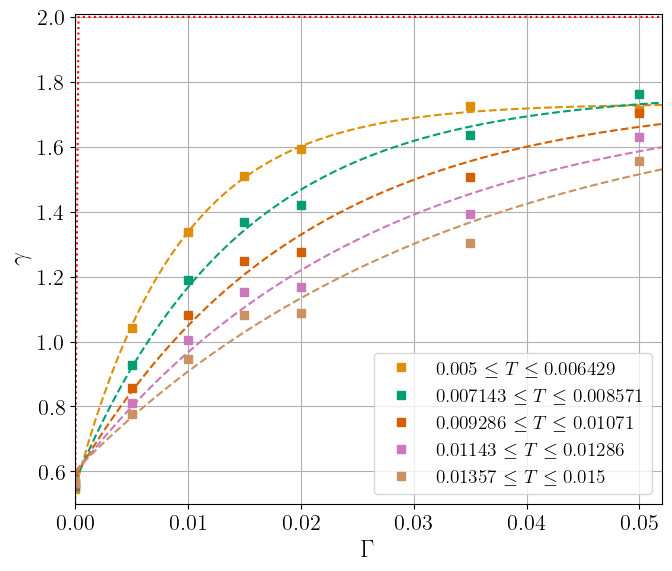

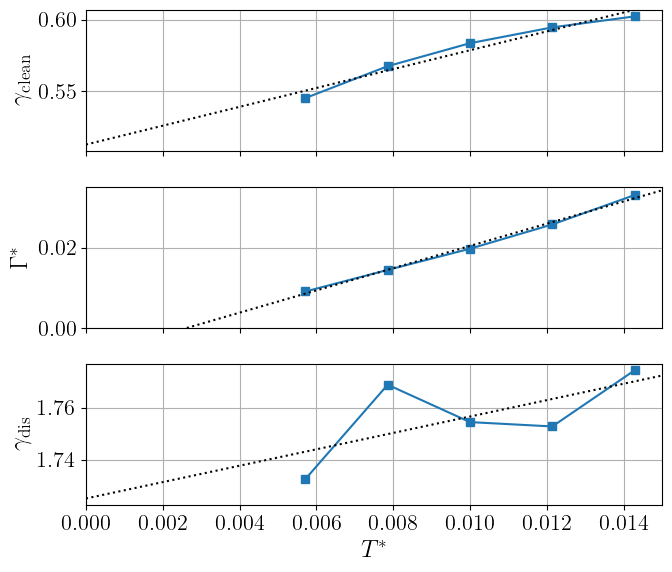

In [5]:
G_list = np.array([0., 0.005, 0.01, 0.015, 0.02, 0.035, 0.05])
U = 3
N_scales = 5
fit_c = True

def exp_func(x, g_clean, Gstar, g_dis):
    return (g_clean - g_dis) * np.exp(-x / Gstar) + g_dis

p_inv_scales = [[] for _ in range(N_scales)]
p_OZ_scales = [[] for _ in range(N_scales)]
n_c_list = []

for G in G_list:
    filename = (f"data/scaling/tp0U{U:.5g}.h5" if G == 0
                else f"data/scaling/G{G:.5g}tp0U{U:.5g}.h5")

    with HDFArchive(filename, "r") as ar:
        T = np.array(ar['T'])
        n = np.array(ar['n'])
        invchi = np.array(ar['invchi_min'])
        OZ_weight = np.array(ar['OZ_weight'])

    c_list = []
    gamma_list = []

    for i in range(len(n)):
        par, _ = curve_fit(HMM, T, invchi[i, :],
                           p0=[1, 0.5, 0.], maxfev=10000)
        gamma_list.append(par[1])
        c_list.append(par[2])

    slope, intercept = np.polyfit(n, c_list, 1)
    n_c_list.append(-intercept / slope)

    idx = np.argsort(n)
    n_sorted = n[idx]
    n_c = n_c_list[-1]

    invchi_nc = np.array([
        np.interp(n_c, n_sorted, invchi[idx, j])
        for j in range(len(T))
    ])
    OZ_nc = np.array([
        np.interp(n_c, n_sorted, OZ_weight[idx, j])
        for j in range(len(T))
    ])

    scale_slices = np.array_split(np.arange(len(T)), N_scales)

    for s, sl in enumerate(scale_slices):
        par, _ = curve_fit(HMM, T[sl], invchi_nc[sl],
                           p0=[1, 0.5, 0.], maxfev=10000)
        p_inv_scales[s].append(par)

        par, _ = curve_fit(HMM, T[sl], OZ_nc[sl],
                           p0=[1, 1.5, 0.01], maxfev=10000)
        p_OZ_scales[s].append(par)

p_inv_scales = np.array(p_inv_scales)
gamma_scales = p_inv_scales[:, :, 1]

G_fit = np.linspace(G_list.min(), G_list.max() + 1e-2, 200)

func = exp_func if fit_c else lambda x, a, b: exp_func(x, a, b, 2)
p0 = [0.5, 0.5, 2] if fit_c else [0.5, 0.5]
bounds = ([0, 0, 0], [np.inf, np.inf, np.inf]) if fit_c else ([0, 0], [np.inf, np.inf])

par_gamma_scales = np.array([
    curve_fit(func, G_list, gamma_scales[s],
              p0=p0, bounds=bounds, maxfev=10000)[0]
    for s in range(N_scales)
])

# Exponential fits
plt.figure(figsize=(7, 6))

for s, sl in enumerate(scale_slices):
    plt.plot(G_list, gamma_scales[s], 's',
             color=color_list[s + 1],
             label=rf'${T[sl][0]:.4g} \le T \le {T[sl][-1]:.4g}$')
    plt.plot(G_fit, func(G_fit, *par_gamma_scales[s]), '--',
             color=color_list[s + 1])

plt.plot(G_fit, func(G_fit, 0.5, 1e-8, 2), ':', color='red')
plt.xlabel(r'$\Gamma$')
plt.ylabel(r'$\gamma$')
plt.xlim(0, G_list.max() + 2e-3)
plt.ylim(0.5, 2.01)
plt.legend(loc='lower right')
plt.grid()
plt.tight_layout()
plt.show()

# Fitted parameters vs T*
T_star = np.array([T[sl][len(sl) // 2] for sl in scale_slices])
T_fit = np.linspace(0, T_star.max(), 100)

params = par_gamma_scales.T
labels = [r'$\gamma_{\mathrm{clean}}$', r'$\Gamma^*$', r'$\gamma_{\mathrm{dis}}$']

fig, ax = plt.subplots(3, 1, figsize=(7, 6), sharex=True)

for i in range(3):
    ax[i].plot(T_star, params[i], 's-')
    
    # Linear extrapolation
    m, q = np.polyfit(T_star, params[i], 1)
    ax[i].axline((0, q), slope=m, linestyle=':', color='black')
    
    ax[i].set_ylabel(labels[i])
    ax[i].grid()

ax[1].set_ylim(bottom=0)
ax[2].set_xlabel(r'$T^*$')

for a in ax:
    a.set_xlim(left=0)

plt.tight_layout()
plt.show()

In [14]:
ciao = np.arange(0.005, 0.02, 0.00075)
print(ciao, len(ciao))

[0.005   0.00575 0.0065  0.00725 0.008   0.00875 0.0095  0.01025 0.011
 0.01175 0.0125  0.01325 0.014   0.01475 0.0155  0.01625 0.017   0.01775
 0.0185  0.01925] 20


/home/carlo/Desktop/qc/scripts/plot.py:129: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


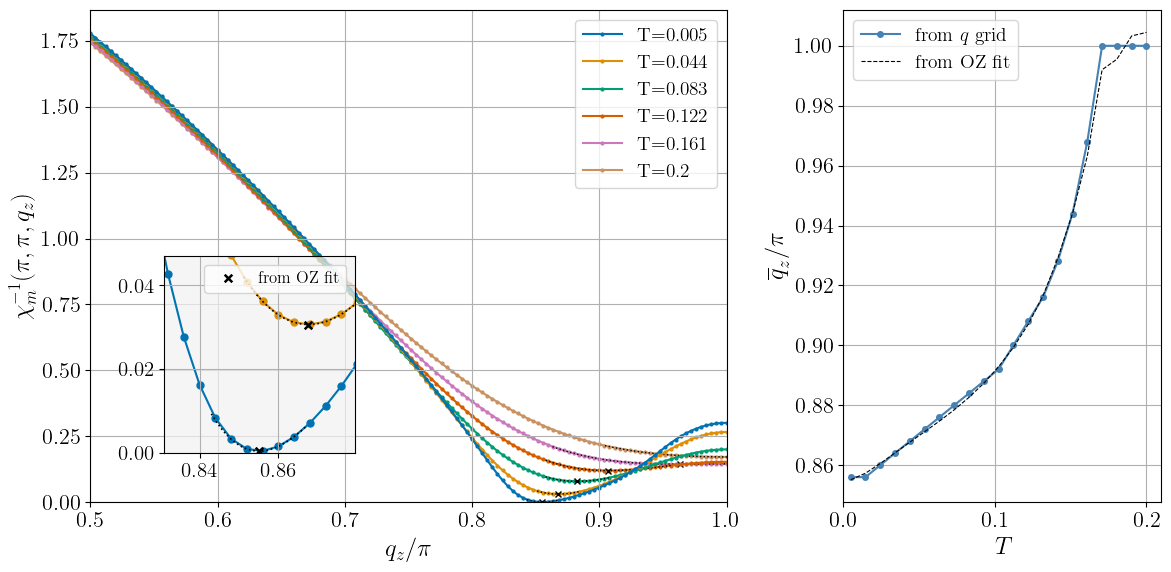

In [3]:
n = 0.88583
U = 3

with HDFArchive(f"data/chimin/G0.05tp0.1n{n:.5g}U{U:.5g}.h5", "r") as ar:
    data = {k: ar[k] for k in ar}

plot_chimin(data)
plt.show()

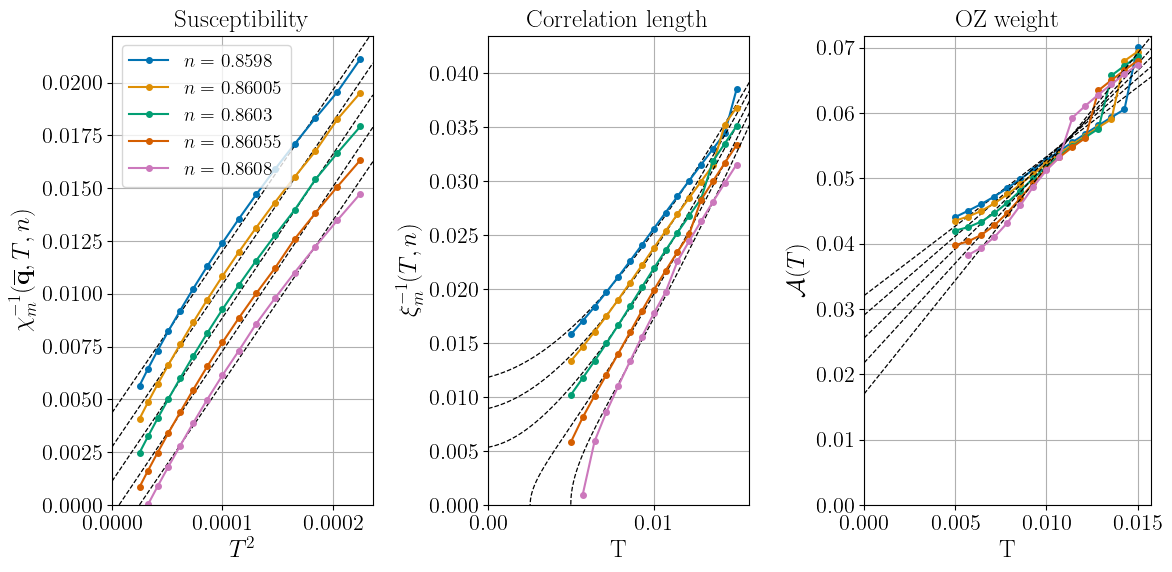

In [3]:
U = 3
Gamma = 0.01
tp = 0.1

data = {}
with HDFArchive(f"data/scaling/G{Gamma:.5g}tp{tp:.5g}U{U:.5g}.h5", "r") as ar:
    data = {k: ar[k] for k in ar}

plot_scaling(data, x_exp=(2, 1, 1), fit=True, right='OZ')
plt.show()

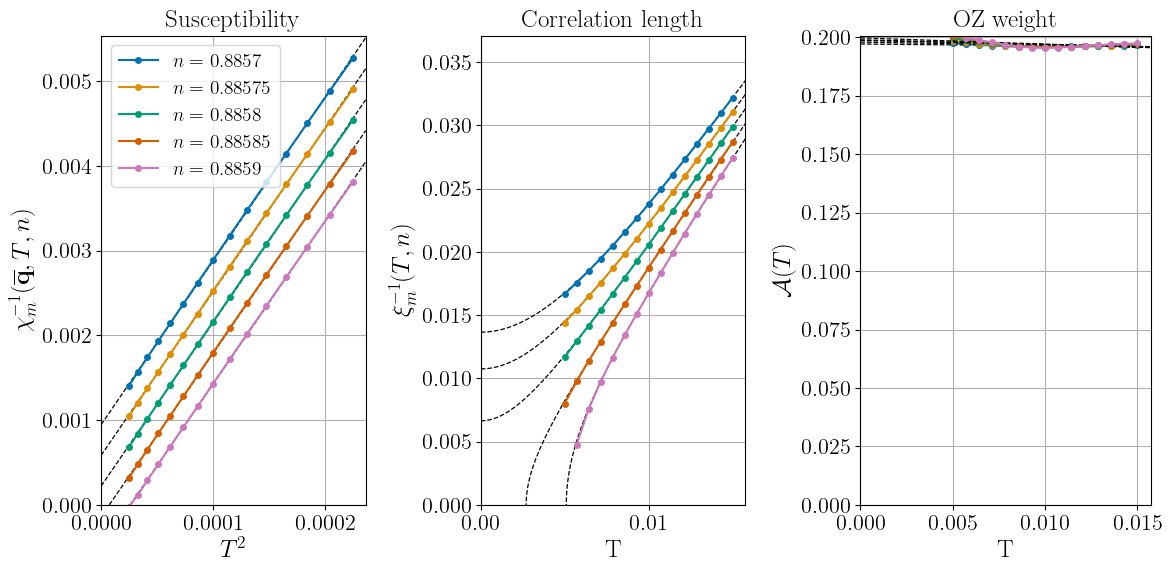

In [8]:
U = 3
Gamma = 0.05
tp = 0.1

data = {}
with HDFArchive(f"data/scaling/G{Gamma:.5g}tp{tp:.5g}U{U:.5g}.h5", "r") as ar:
    data = {k: ar[k] for k in ar}

plot_scaling(data, x_exp=(2, 1, 1), fit=True, right='OZ')
plt.show()

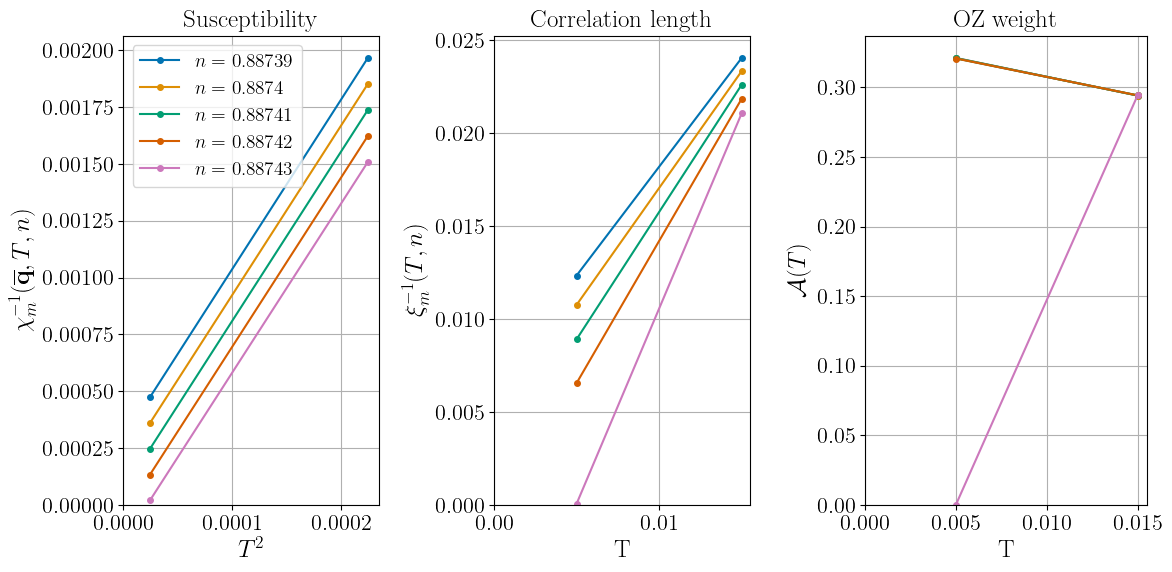

In [2]:
U = 3
Gamma = 0.01
tp = 0.2

data = {}
with HDFArchive(f"data/scaling/G{Gamma:.5g}tp{tp:.5g}U{U:.5g}.h5", "r") as ar:
    data = {k: ar[k] for k in ar}

plot_scaling(data, x_exp=(2, 1, 1), fit=True, right='OZ')
plt.show()

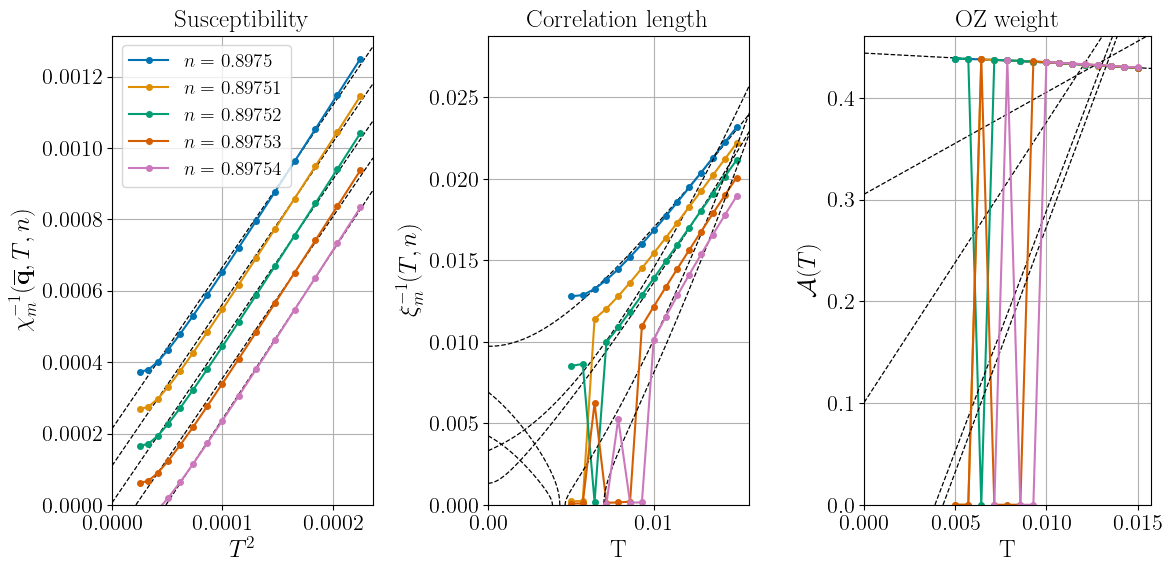

In [2]:
U = 3
Gamma = 0.05
tp = 0.2

data = {}
with HDFArchive(f"data/scaling/G{Gamma:.5g}tp{tp:.5g}U{U:.5g}.h5", "r") as ar:
    data = {k: ar[k] for k in ar}

plot_scaling(data, x_exp=(2, 1, 1), fit=True, right='OZ')
plt.show()

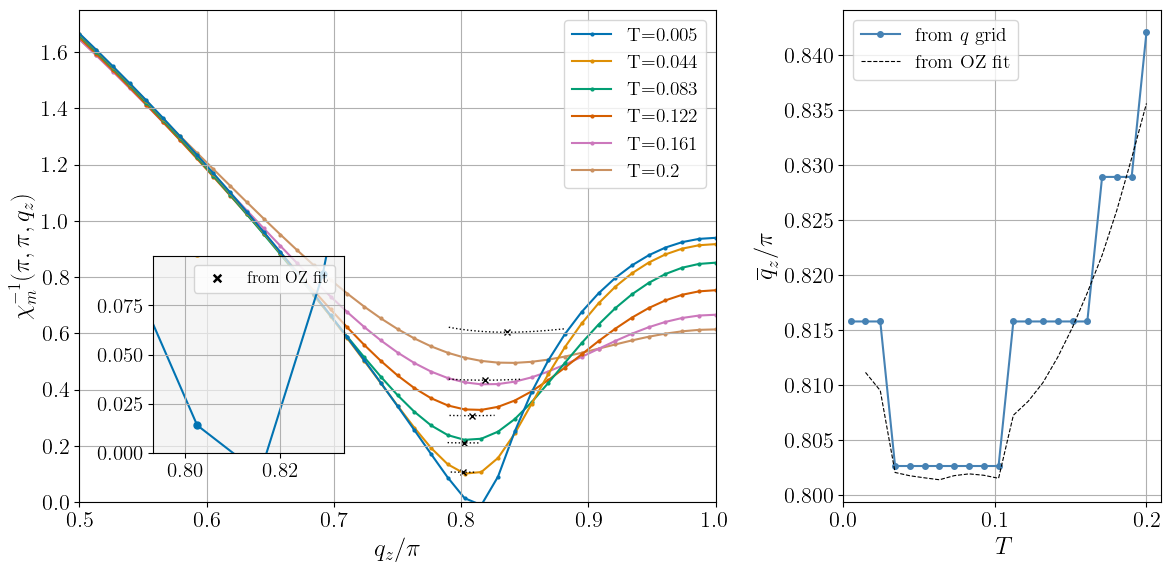

In [14]:
n = 0.84
U = 3
v = 0.3

with HDFArchive(f"data/chimin/v{v:.5g}tp0n{n:.5g}U{U:.5g}.h5", "r") as ar:
    data = {k: ar[k] for k in ar}

plot_chimin(data)
plt.show()

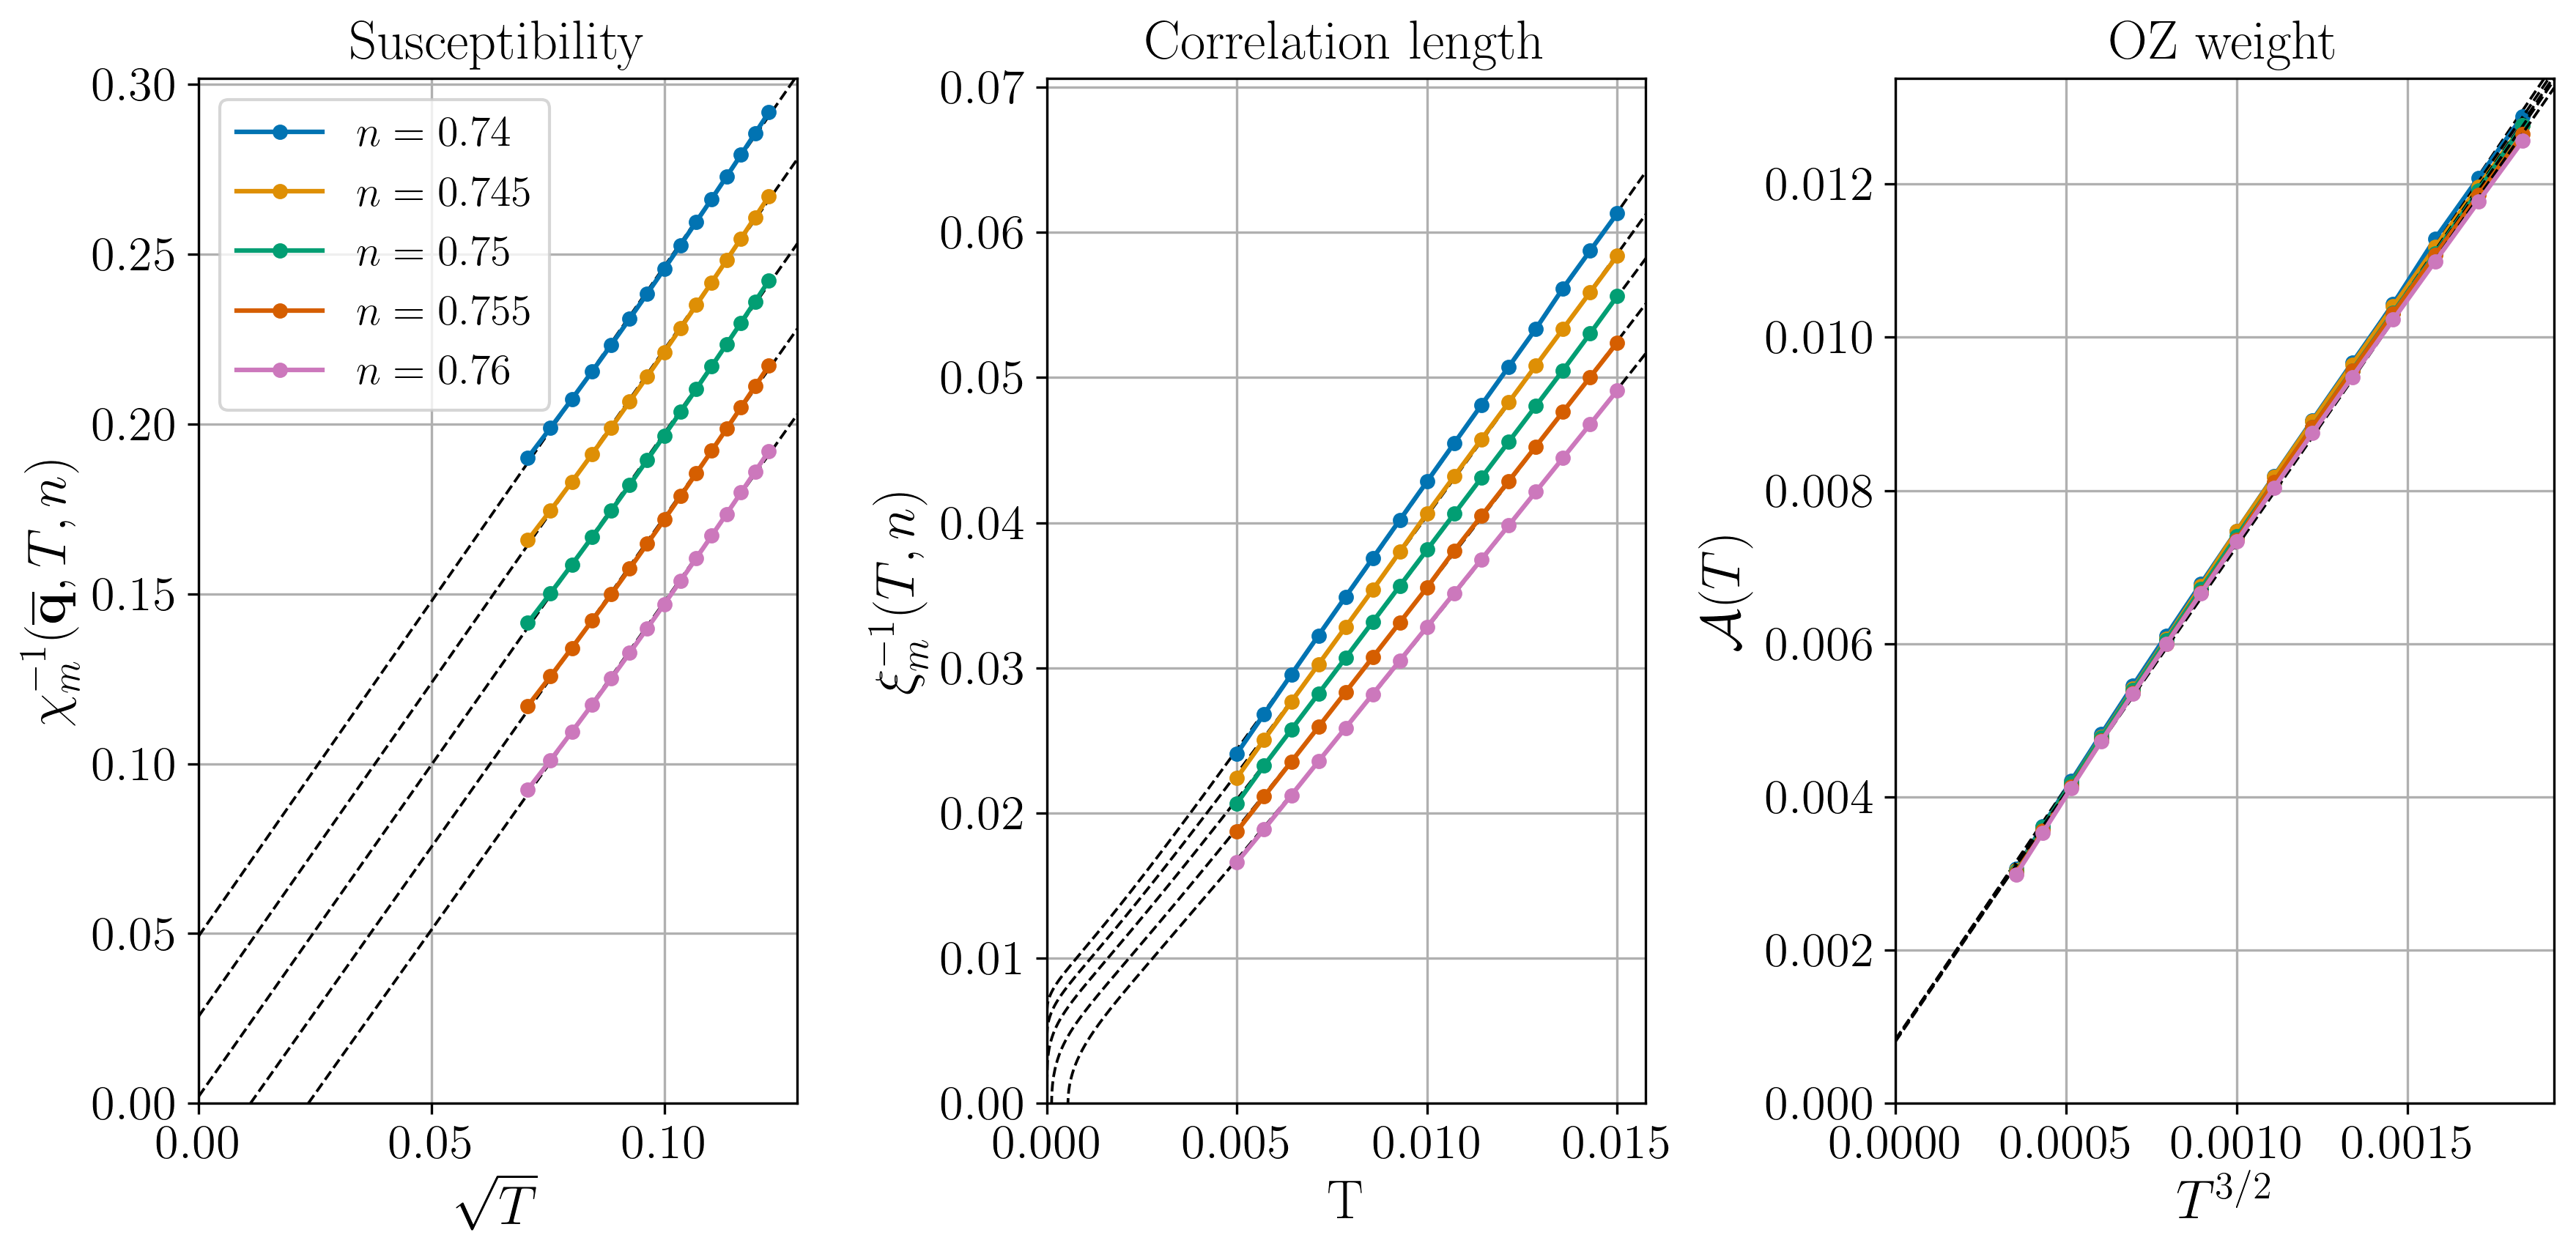

In [3]:
U = 3
v = 0.05
tp = 0.

data = {}
with HDFArchive(f"data/scaling/v{v:.5g}tp{tp:.5g}U{U:.5g}.h5", "r") as ar:
    data = {k: ar[k] for k in ar}

plot_scaling(data, x_exp=(0.5, 1, 1.5), fit=True, right='OZ')
plt.show()

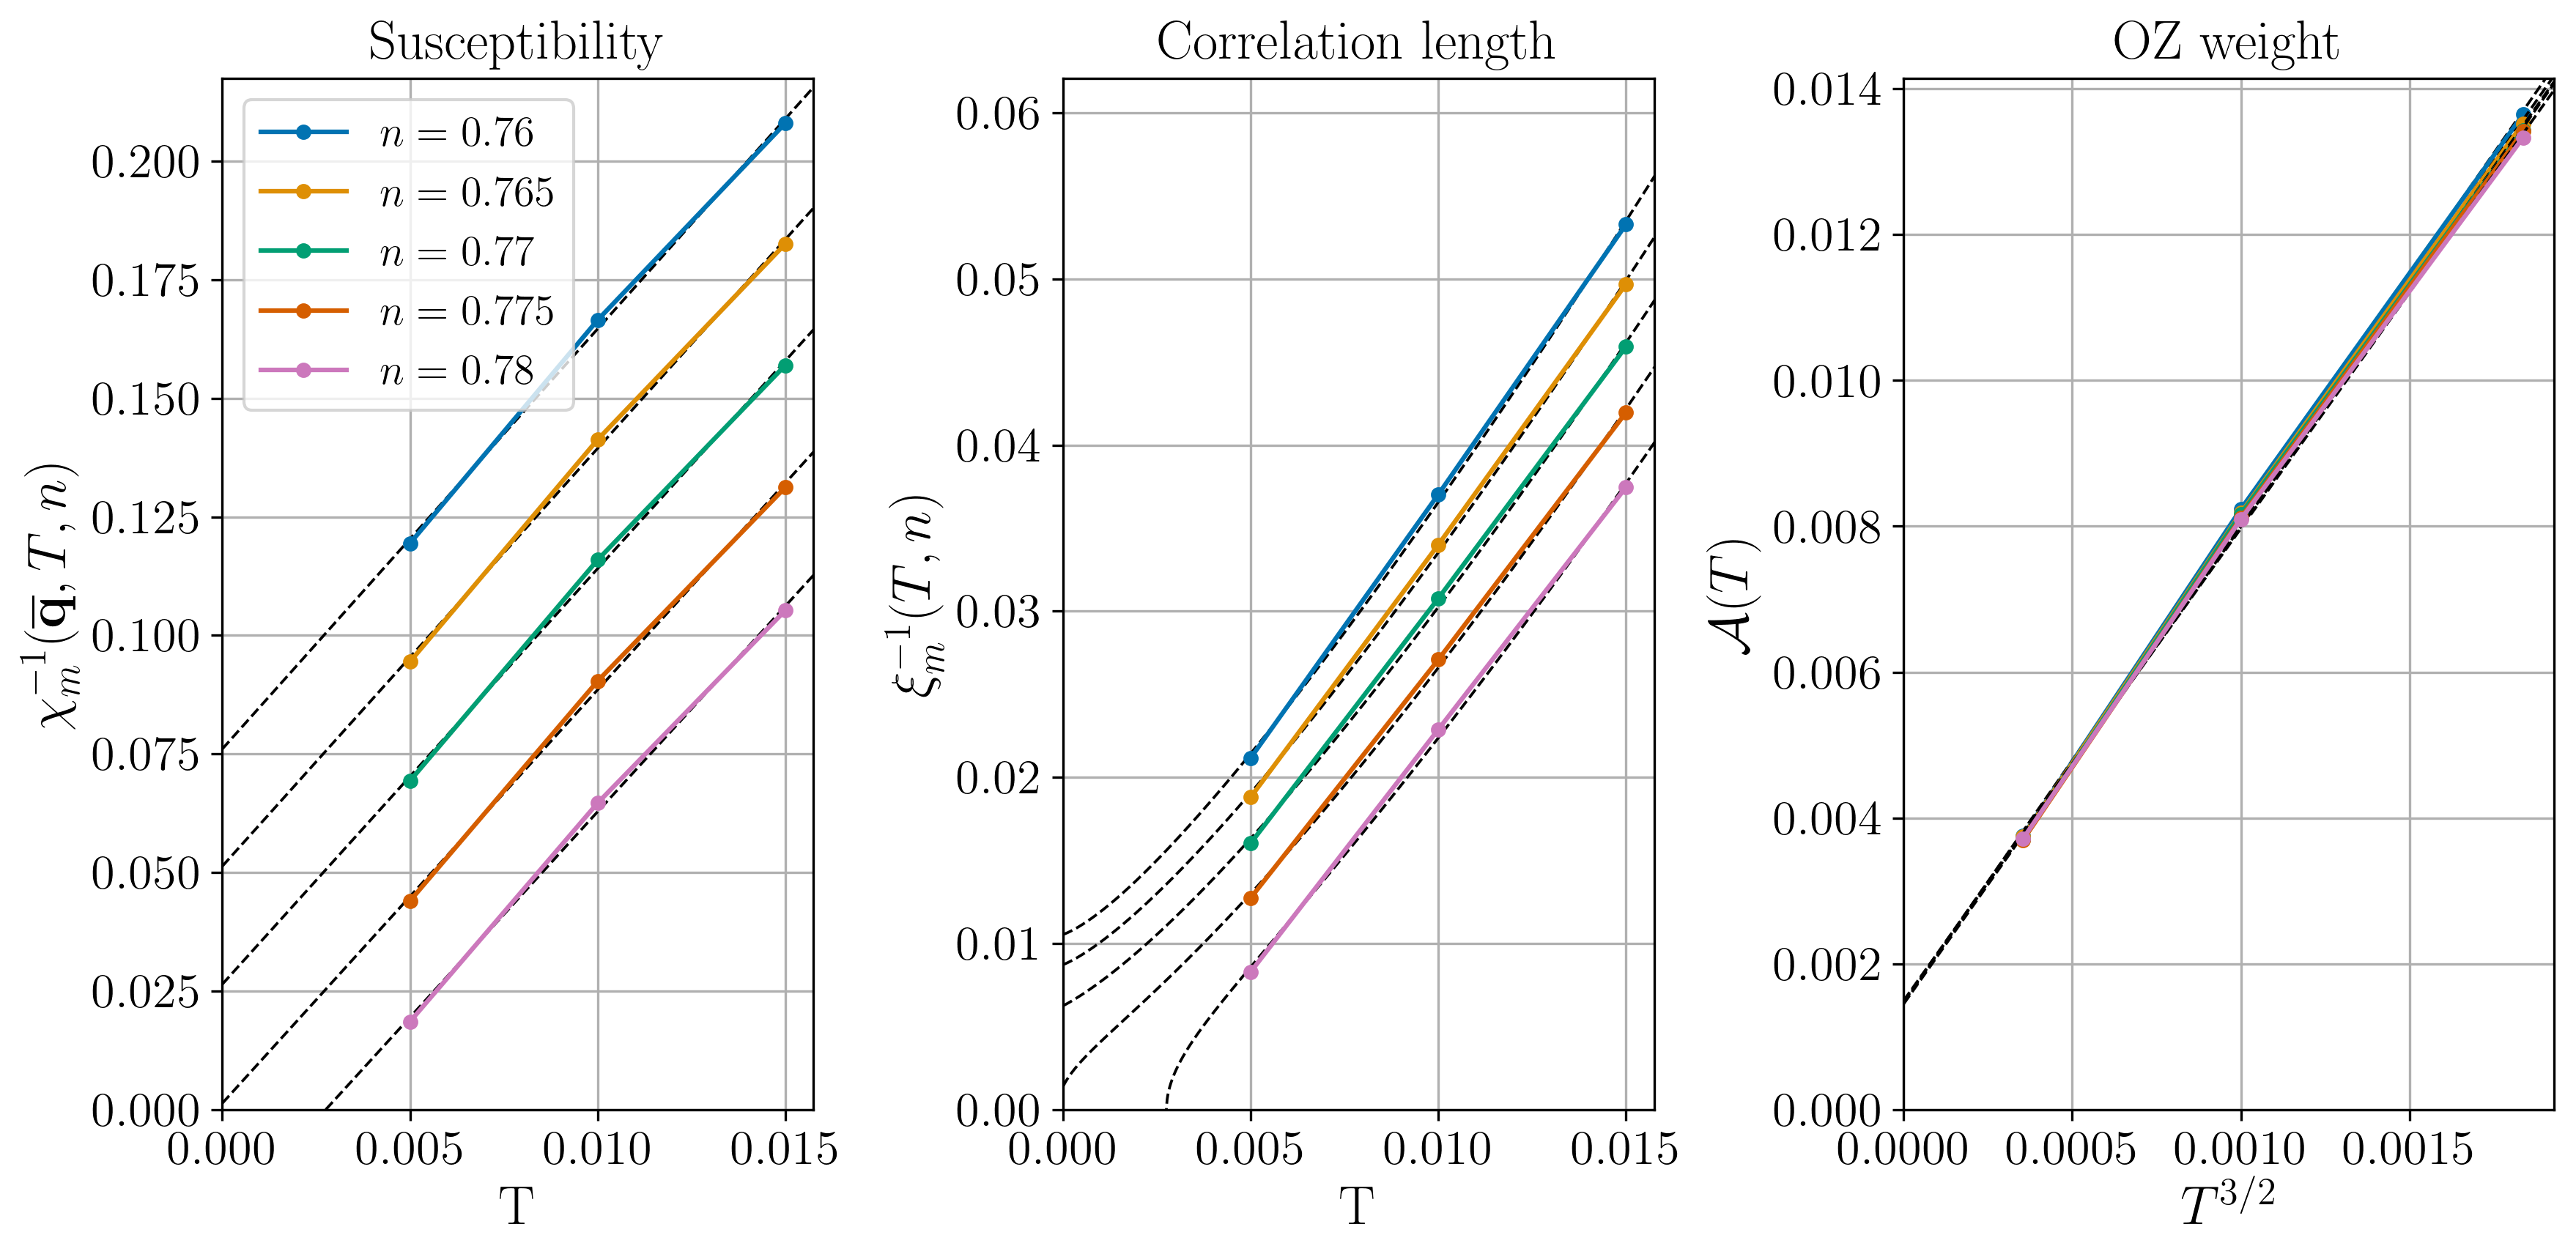

In [2]:
U = 3
v = 0.08
tp = 0.

data = {}
with HDFArchive(f"data/scaling/v{v:.5g}tp{tp:.5g}U{U:.5g}.h5", "r") as ar:
    data = {k: ar[k] for k in ar}

plot_scaling(data, x_exp=(1, 1, 1.5), fit=True, right='OZ')
plt.show()

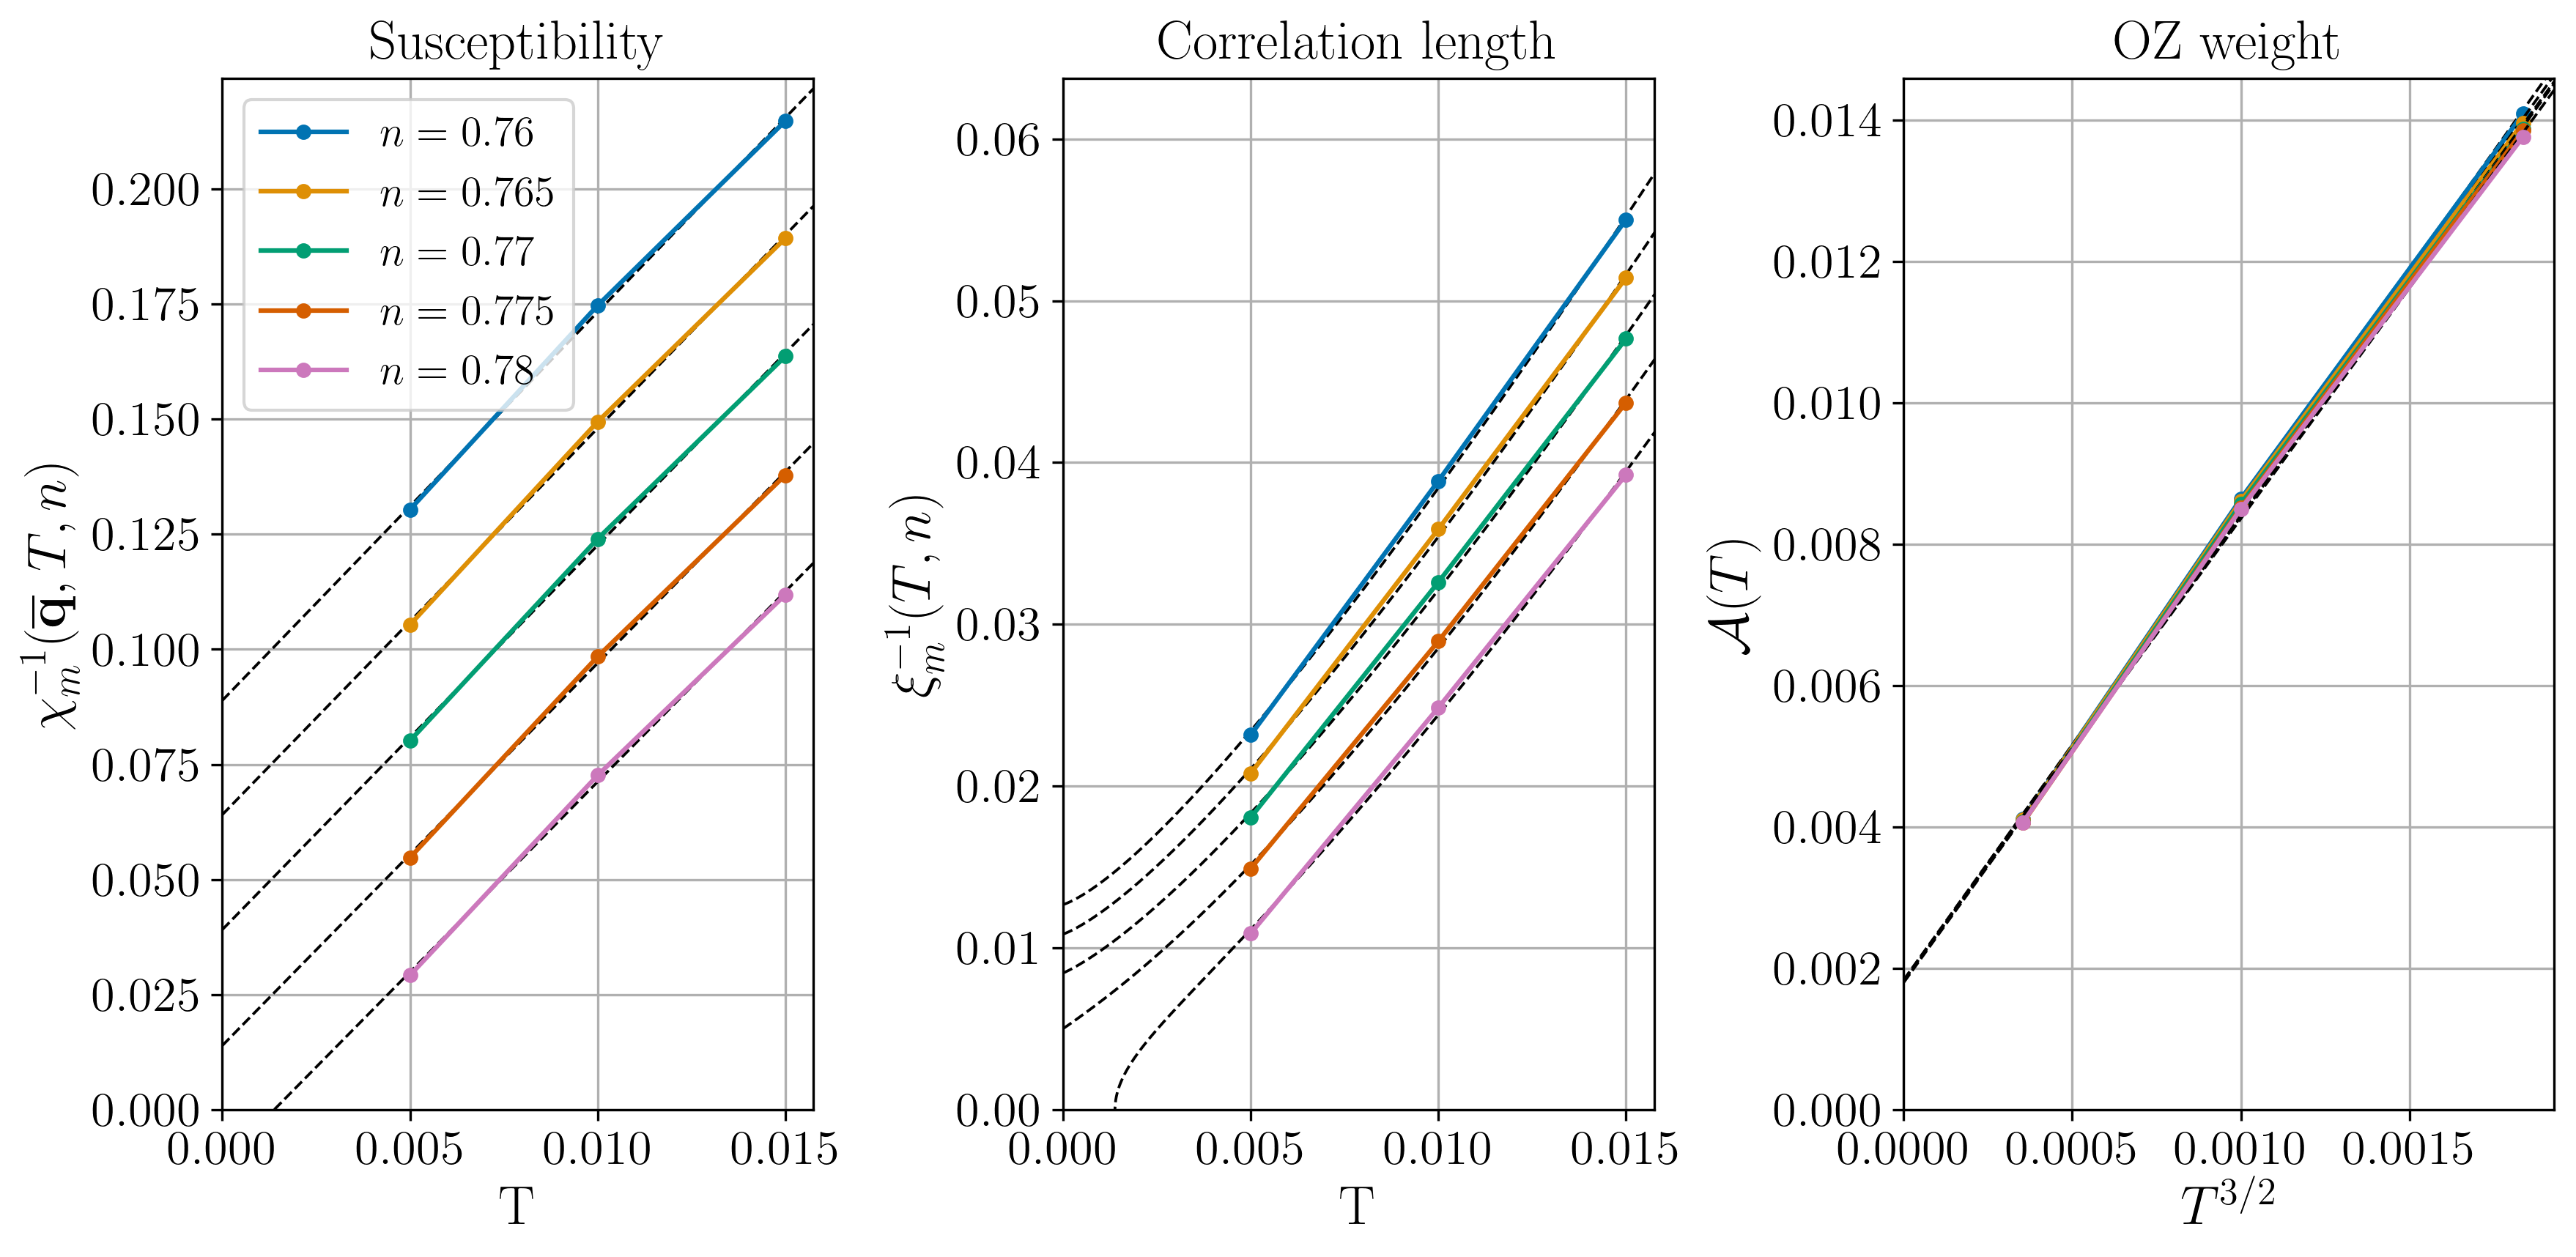

In [6]:
U = 3
v = 0.09
tp = 0.

data = {}
with HDFArchive(f"data/scaling/v{v:.5g}tp{tp:.5g}U{U:.5g}.h5", "r") as ar:
    data = {k: ar[k] for k in ar}

plot_scaling(data, x_exp=(1, 1, 1.5), fit=True, right='OZ')
plt.show()

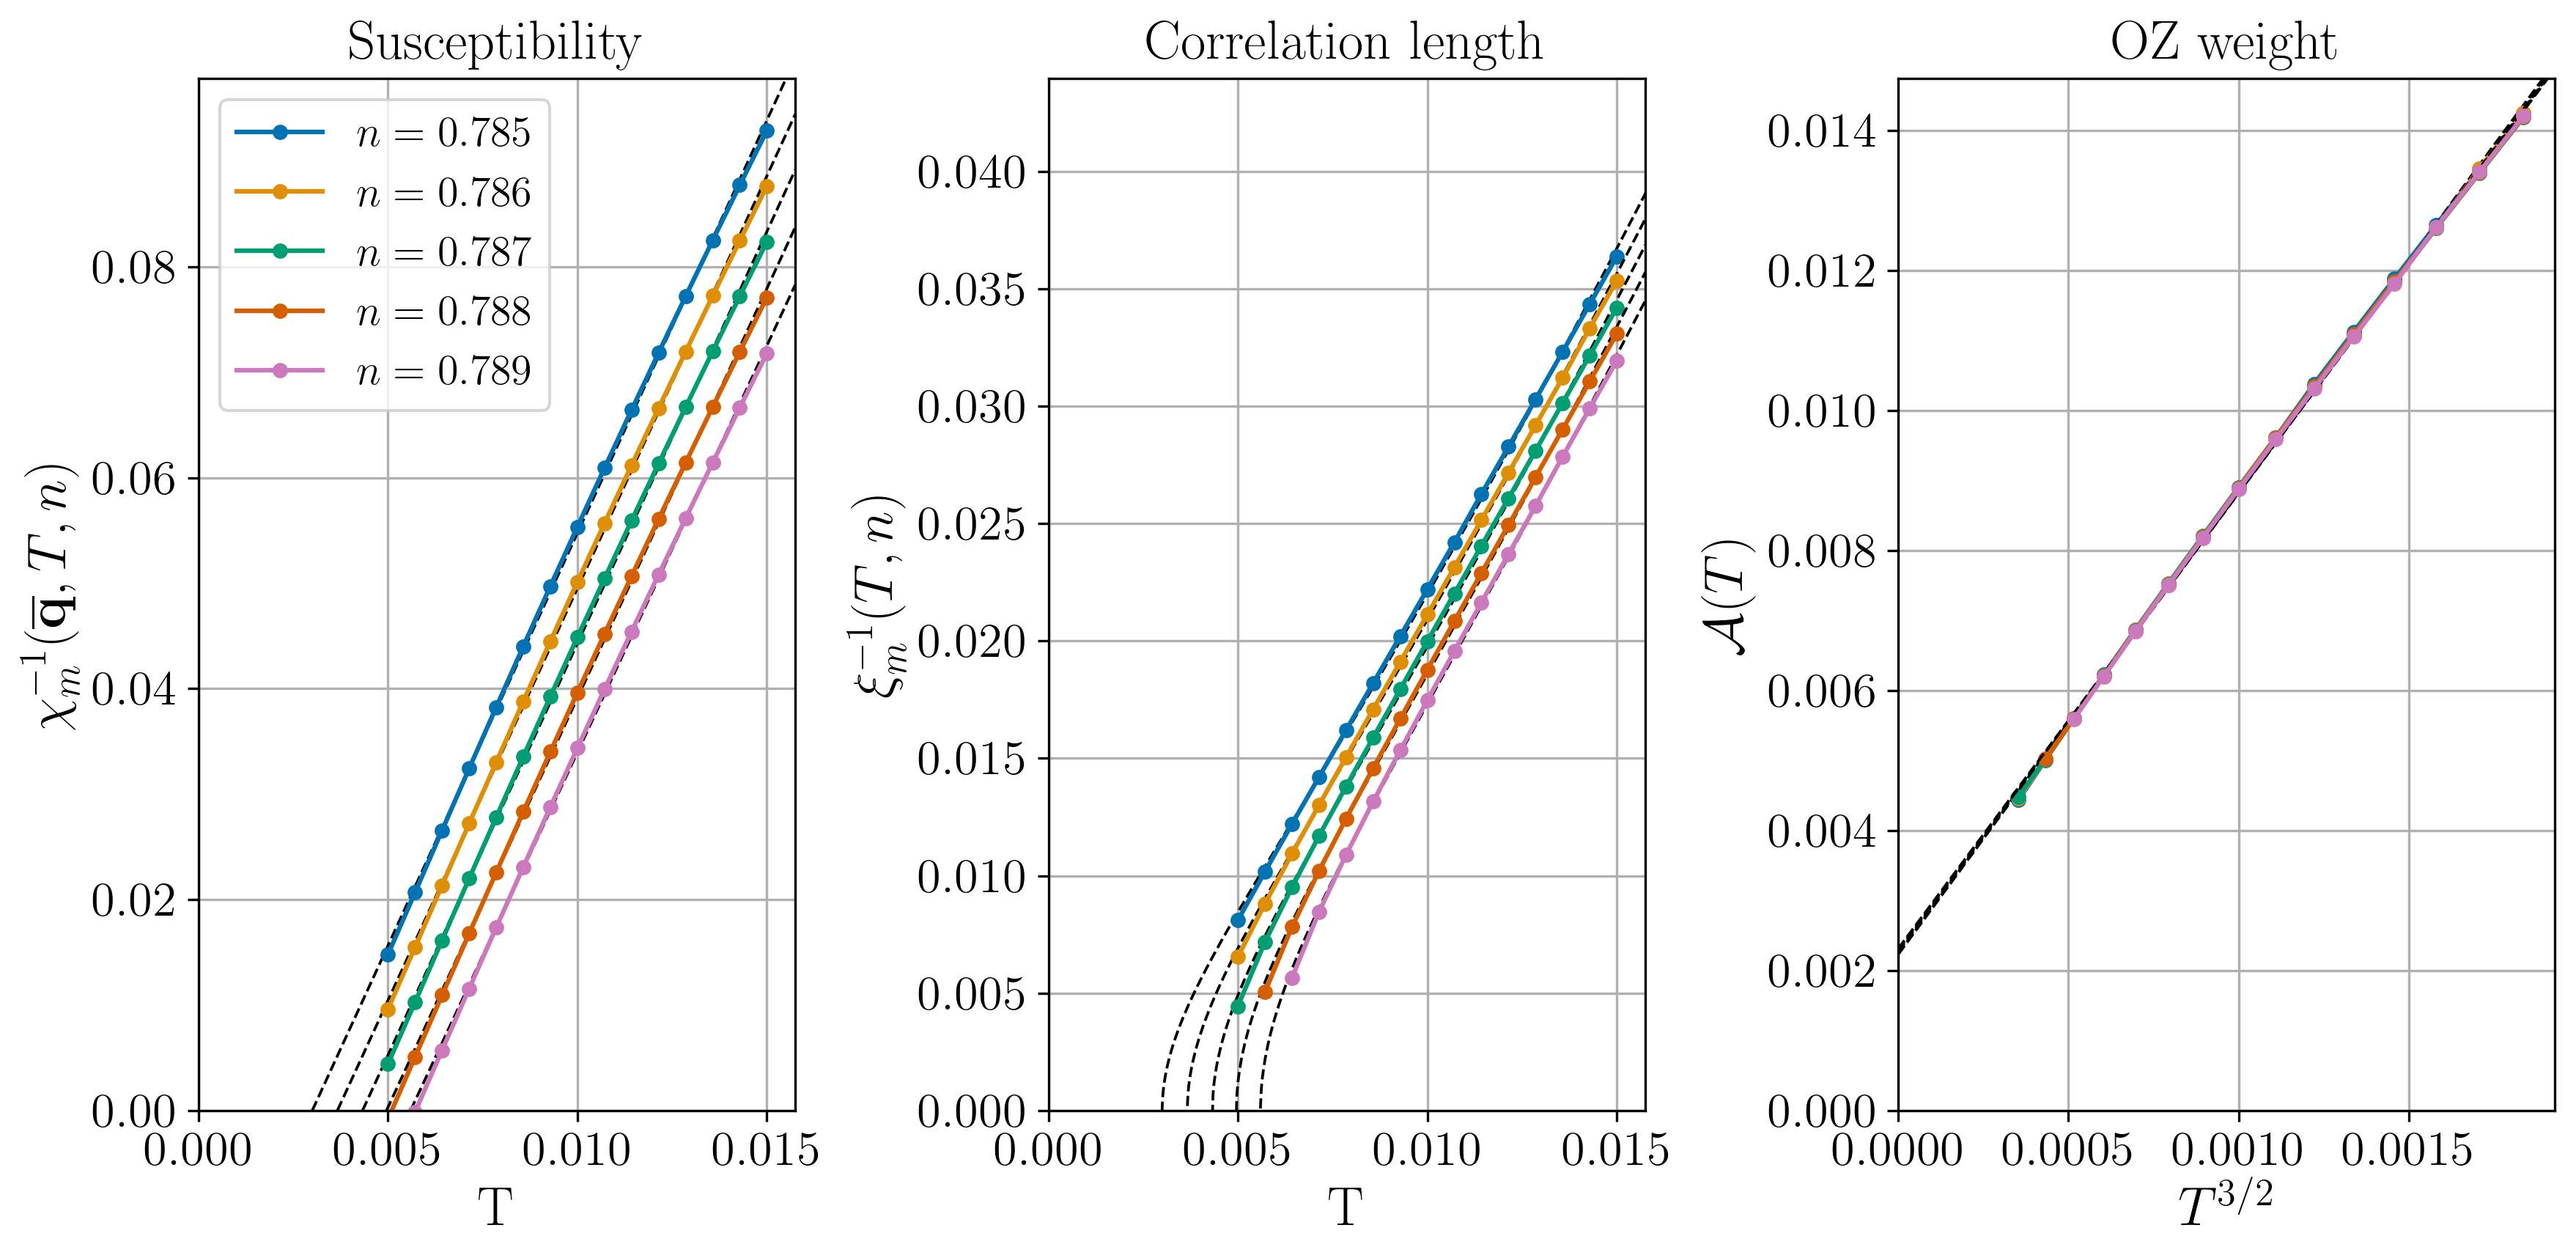

In [7]:
U = 3
v = 0.1
tp = 0.

data = {}
with HDFArchive(f"data/scaling/v{v:.5g}tp{tp:.5g}U{U:.5g}.h5", "r") as ar:
    data = {k: ar[k] for k in ar}

plot_scaling(data, x_exp=(1, 1, 1.5), fit=True, right='OZ')
plt.show()

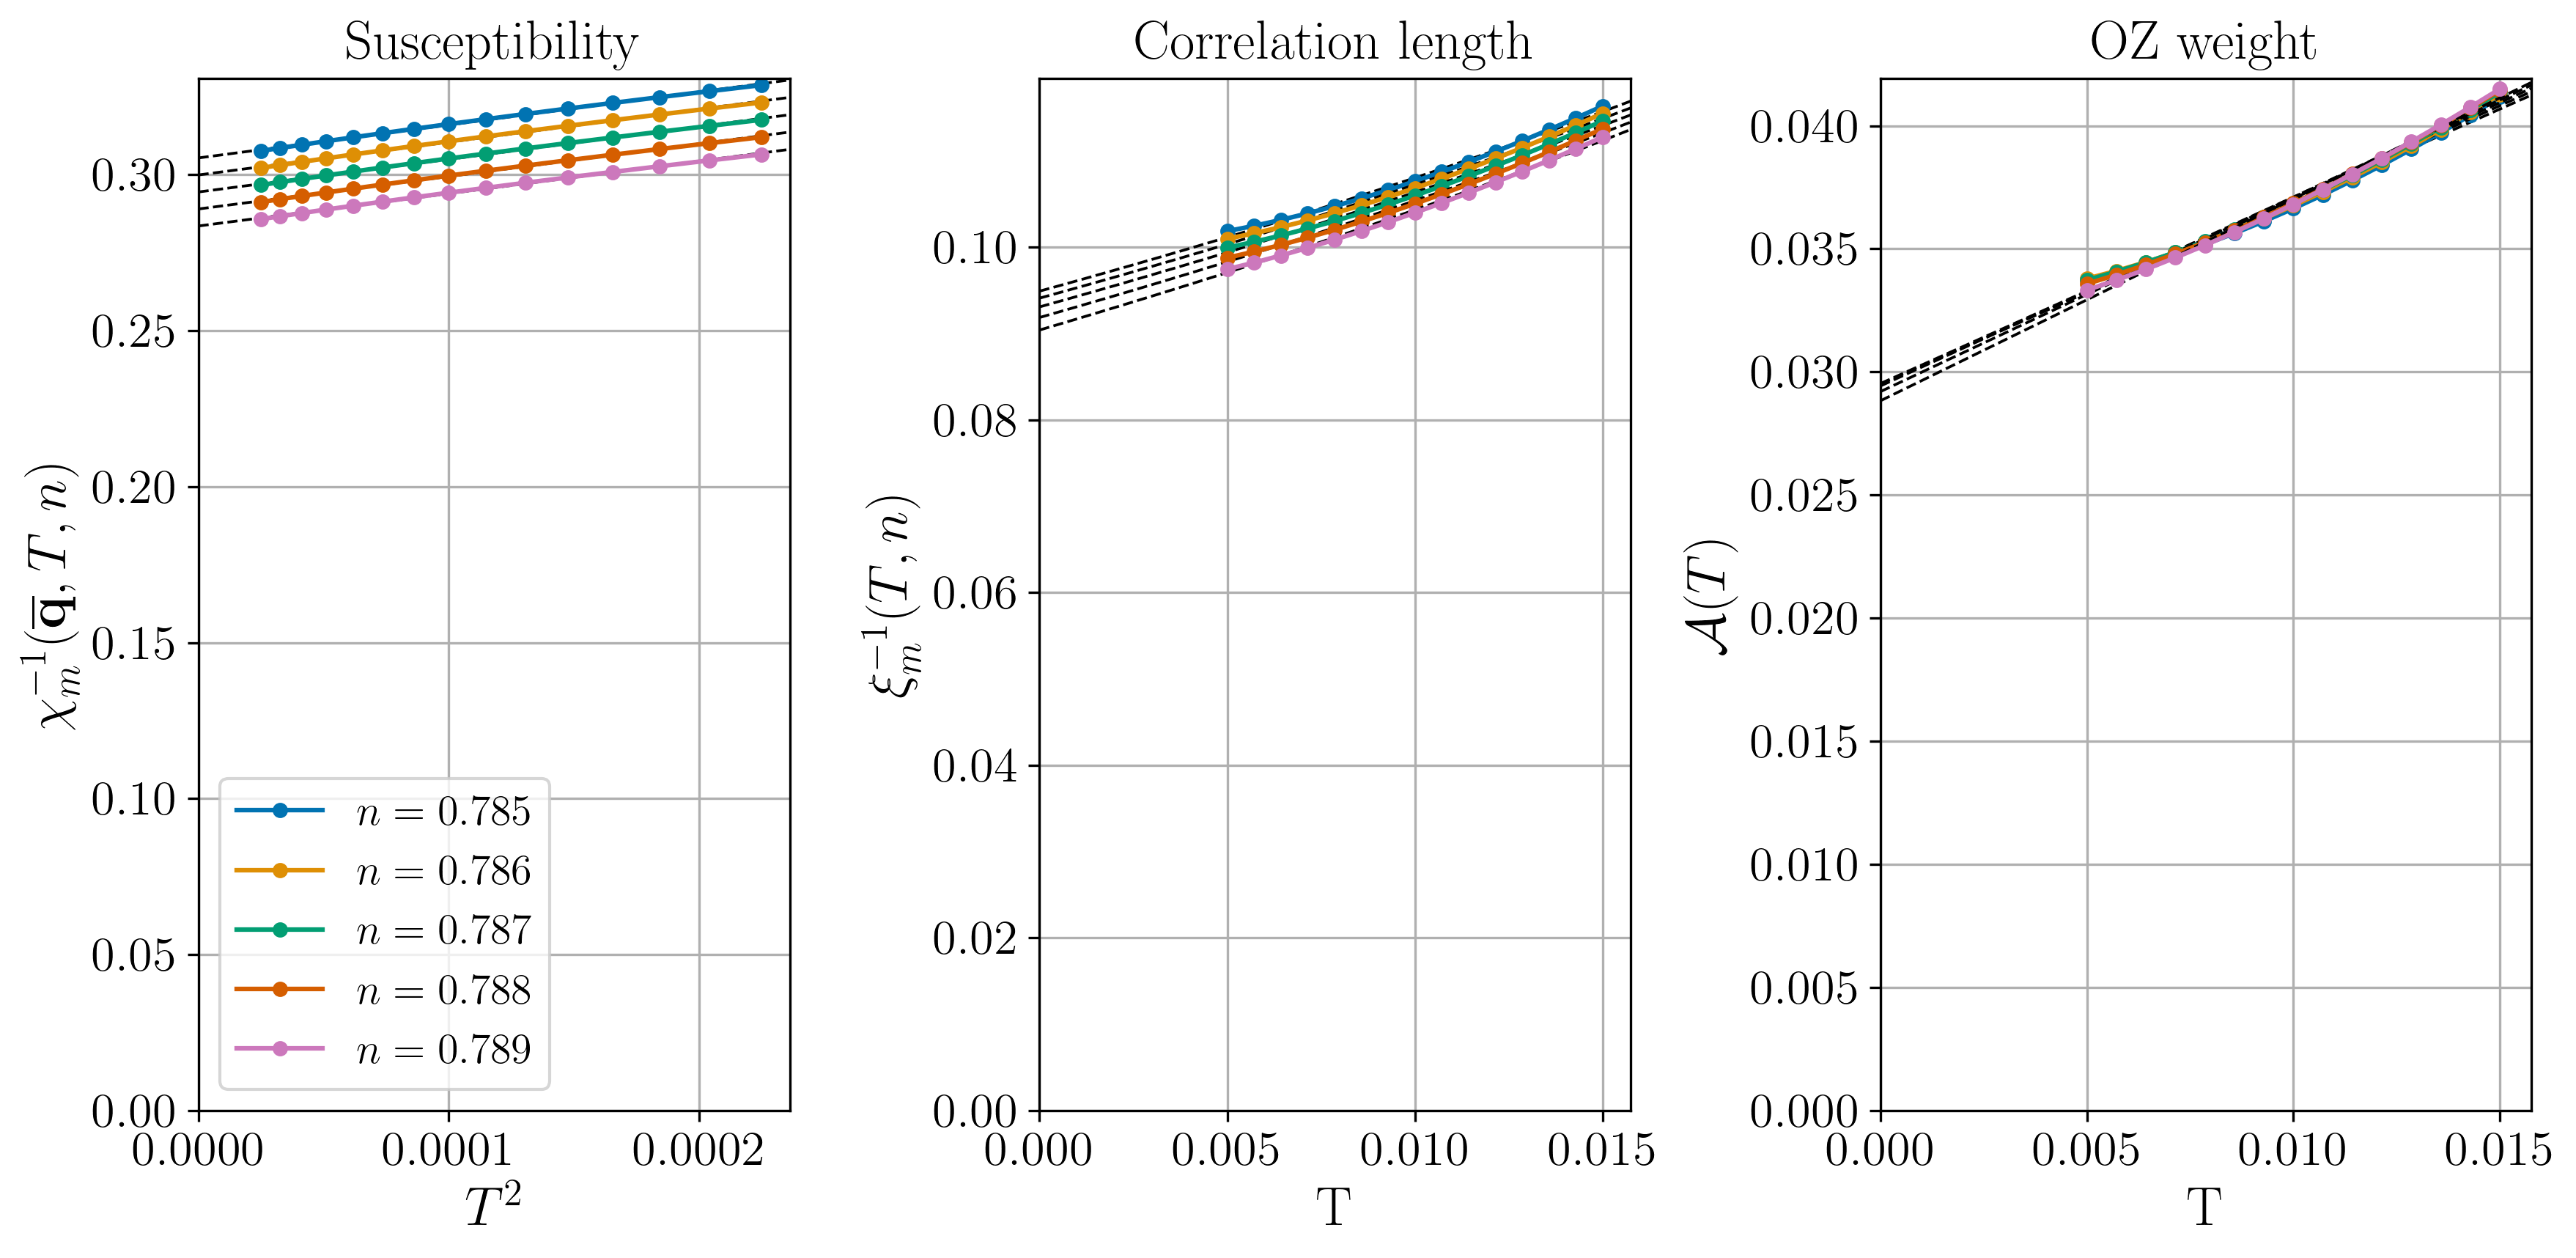

In [8]:
U = 3
v = 0.3
tp = 0.

data = {}
with HDFArchive(f"data/scaling/v{v:.5g}tp{tp:.5g}U{U:.5g}.h5", "r") as ar:
    data = {k: ar[k] for k in ar}

plot_scaling(data, x_exp=(2, 1, 1), fit=True, right='OZ')
plt.show()

/tmp/ipykernel_13218/397984304.py:39: OptimizeWarning: Covariance of the parameters could not be estimated
  par, cov = curve_fit(HMM, T, invchi[i, :], p0=[1, 0.5, 0.], maxfev=10000)
/tmp/ipykernel_13218/397984304.py:58: OptimizeWarning: Covariance of the parameters could not be estimated
  par_inv, _ = curve_fit(HMM, T[sl], invchi_nc[sl], p0=[1, 0.5, 0.], maxfev=10000)
/tmp/ipykernel_13218/397984304.py:61: OptimizeWarning: Covariance of the parameters could not be estimated
  par_OZ, _ = curve_fit(HMM, T[sl], OZ_nc[sl], p0=[1, 1.5, 0.01], maxfev=10000)


par_gamma_scales :  [-1.29669129  0.03811898  1.84593222]


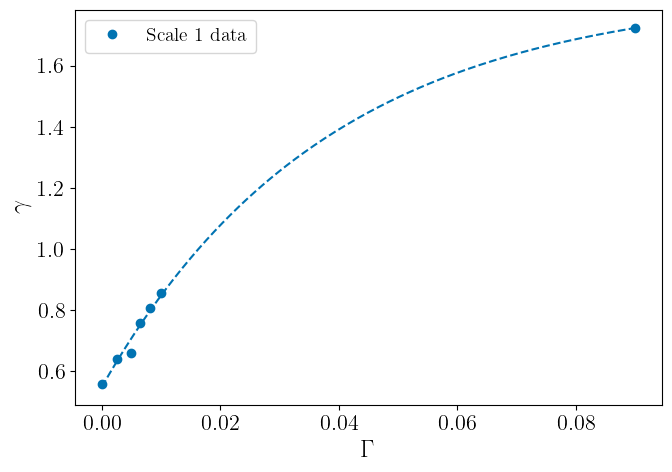

A0_scales :  [-6.87327518e-05  1.83778973e-04  7.27822993e-04  7.41094553e-04
  1.14762966e-03  1.49042365e-03  3.15574111e-02]


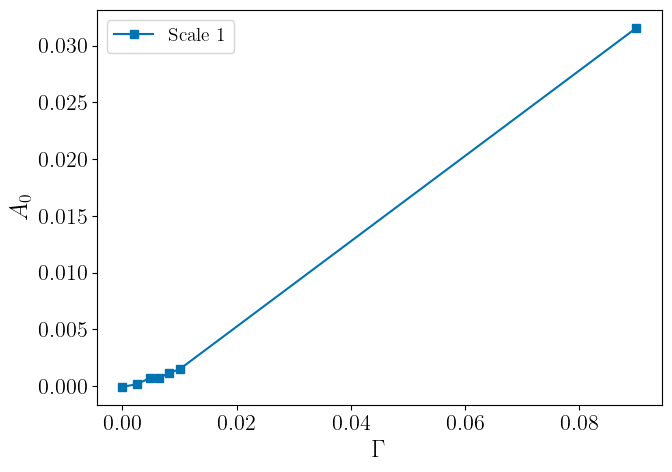

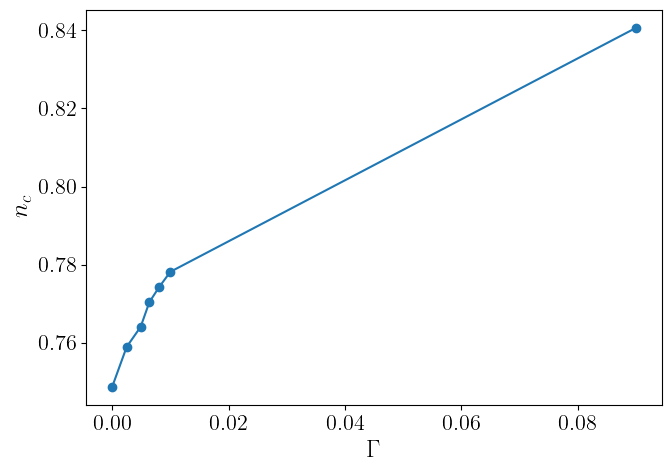

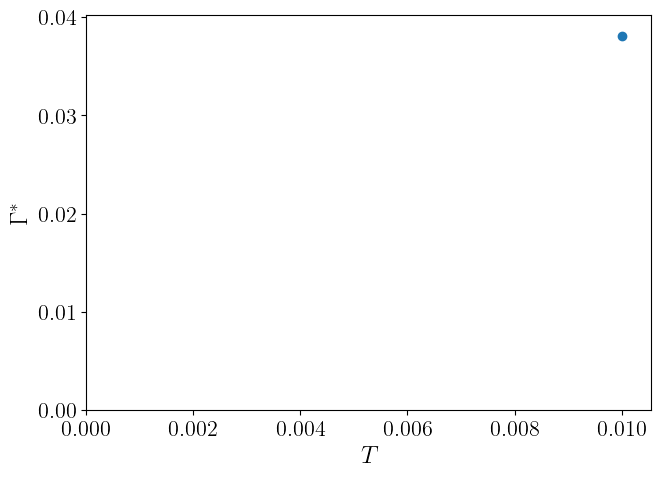

In [15]:
v_list = np.array([0., 0.05, 0.07, 0.08, 0.09, 0.1, 0.3])
U = 3
N_scales = 1
fit_c = True

def pwl_func(x, a, b, c): return a * np.maximum(x, 1e-10)**(-b) + c
def exp_func(x, a, b, c): return a * np.exp(-x / b) + c
def log_func(x, a, b, c): return a / np.log(b * np.maximum(x, 1e-10)) + c

base_func = exp_func

p_inv_scales = [[] for _ in range(N_scales)]
p_OZ_scales = [[] for _ in range(N_scales)]
n_c_list = []

for v in v_list:
    if v == 0:
        filename = f"data/scaling/tp0U{U:.5g}.h5"
    else:
        filename = f"data/scaling/v{v:.5g}tp0U{U:.5g}.h5"

    with HDFArchive(filename, "r") as ar:
        T = np.array(ar['T'])
        n = np.array(ar['n'])
        invchi = np.array(ar['invchi_min'])
        OZ_weight = np.array(ar['OZ_weight'])
        S_iw = np.array(ar['S_list'])

    #G_T0n = np.empty(len(n))
    #w_n = np.array([(2*np.arange(np.shape(S_iw)[-1]) + 1) * np.pi * Temp for Temp in T])
    #for i_n in range(len(n)):
    #    par = np.array([np.polyfit(w_n[iT,:4], -data['S_list'][i_n,iT,:5].imag, deg=3) for iT in range(len(T))])
    #    G_Tn = par[:,-1]
    #    G_T0n.append(np.polyfit(T, G_Tn, deg=3)[-1])

    c_list, gamma_list = np.empty(len(n)), np.empty(len(n))

    for i, ni in enumerate(n):
        par, cov = curve_fit(HMM, T, invchi[i, :], p0=[1, 0.5, 0.], maxfev=10000)
        gamma_list[i] = par[1]
        c_list[i] = par[2]

    slope, intercept = np.polyfit(n, c_list, 1)
    n_c = -intercept / slope
    n_c_list.append(n_c)

    sort_idx = np.argsort(n)
    n_sorted = n[sort_idx]
    invchi_sorted, OZ_sorted = invchi[sort_idx, :], OZ_weight[sort_idx, :]

    invchi_nc = np.array([np.interp(n_c, n_sorted, invchi_sorted[:, j]) for j in range(len(T))])
    OZ_nc = np.array([np.interp(n_c, n_sorted, OZ_sorted[:, j]) for j in range(len(T))])

    T_indices = np.arange(len(T))
    scale_slices = np.array_split(T_indices, N_scales)

    for s_idx, sl in enumerate(scale_slices):
        par_inv, _ = curve_fit(HMM, T[sl], invchi_nc[sl], p0=[1, 0.5, 0.], maxfev=10000)
        p_inv_scales[s_idx].append(par_inv)

        par_OZ, _ = curve_fit(HMM, T[sl], OZ_nc[sl], p0=[1, 1.5, 0.01], maxfev=10000)
        p_OZ_scales[s_idx].append(par_OZ)

v_list = v_list**2
n_c_list = np.array(n_c_list)
p_inv_scales = np.array(p_inv_scales)
p_OZ_scales = np.array(p_OZ_scales)

gamma_scales = p_inv_scales[:, :, 1]
A0_scales = p_OZ_scales[:, :, 2]

G_fit = np.linspace(v_list.min(), v_list.max(), 200)

func = base_func if fit_c else (lambda x, a, b: base_func(x, a, b, 2))
p0_val = [-1, 0.5, 2] if fit_c else [-1, 0.5]
bounds_val = ([-np.inf, 0, 0], [0, np.inf, np.inf]) if fit_c else ([-np.inf, 0], [0, np.inf])

par_gamma_scales = []

for s_idx in range(N_scales):
    par_gamma, _ = curve_fit(func, v_list, gamma_scales[s_idx], p0=p0_val, bounds=bounds_val, maxfev=10000)
    par_gamma_scales.append(par_gamma)

[print('par_gamma_scales : ', par_gamma_scales[s]) for s in range(N_scales)]
plt.figure(figsize=(7, 5)); [plt.plot(v_list, gamma_scales[s], 'o', color=color_list[s], label=f'Scale {s+1} data') for s in range(N_scales)]; [plt.plot(G_fit, func(G_fit, *par_gamma_scales[s]), '--', color=color_list[s]) for s in range(N_scales)]; plt.xlabel(r'$\Gamma$'); plt.ylabel(r'$\gamma$'); plt.legend(); plt.tight_layout(); plt.show()

[print('A0_scales : ', A0_scales[s]) for s in range(N_scales)]
plt.figure(figsize=(7, 5)); [plt.plot(v_list, A0_scales[s], 's-', color=color_list[s], label=f'Scale {s+1}') for s in range(N_scales)]; plt.xlabel(r'$\Gamma$'); plt.ylabel(r'$A_0$'); plt.legend(); plt.tight_layout(); plt.show()

plt.figure(figsize=(7, 5)); plt.plot(v_list, n_c_list, 'o-'); plt.xlabel(r'$\Gamma$'); plt.ylabel(r'$n_c$'); plt.tight_layout(); plt.show()

plt.figure(figsize=(7, 5)); plt.plot([T[sl][len(T[sl])//2] for sl in scale_slices], [par_gamma_scales[s][1] for s in range(N_scales)], 'o-'); plt.xlabel(r'$T$'); plt.ylabel(r'$\Gamma^*$'); plt.tight_layout()
plt.xlim(left=0); plt.ylim(bottom=0)
#plt.yscale('log'); plt.xscale('log')
plt.show()

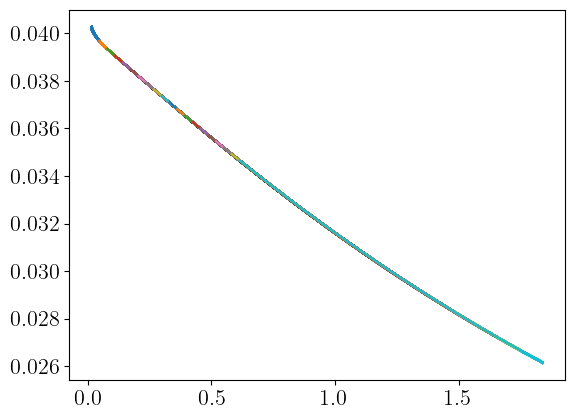

In [12]:
w_n = np.array([(2*np.arange(np.shape(data['S_list'])[-1]) + 1) * np.pi * T for T in data['T']])
for i_n in range(len(data['n'])):
    par = np.array([np.polyfit(w_n[iT,:4], data['S_list'][i_n,iT,:4].imag, deg=3) for iT in range(len(data['T']))])
    for iT in range(len(data['T'])):
        plt.plot(w_n[:,:20], -data['S_list'][i_n,:,:20].imag)

plt.show()

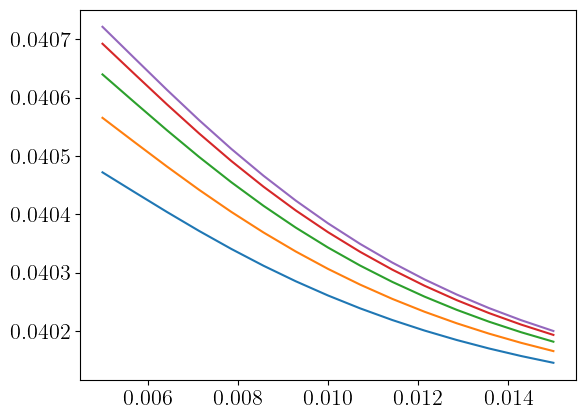

In [13]:
w_n = np.array([(2*np.arange(np.shape(data['S_list'])[-1]) + 1) * np.pi * T for T in data['T']])
for i_n in range(len(data['n'])):
    par = np.array([np.polyfit(w_n[iT,:4], -data['S_list'][i_n,iT,:4].imag, deg=3) for iT in range(len(data['T']))])
    plt.plot(data['T'], par[:,-1])

plt.show()

(15, 2048)


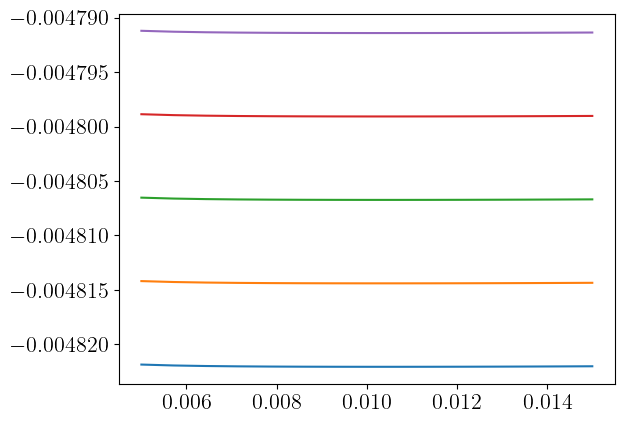

In [21]:
w_n = np.array([(2*np.arange(np.shape(data['S_list'])[-1]) + 1) * np.pi * T for T in data['T']])
print(np.shape(w_n))
for i_n in range(len(data['n'])):
    par = np.array([np.polyfit(w_n[iT,:4], data['S_list'][i_n,iT,:4].real, deg=3) for iT in range(len(data['T']))])
    plt.plot(data['T'], par[:,-1])

plt.show()

n: 0.845, U: 3.000: Completed 5 jobs in 10.8 seconds
n: 0.845, U: 3.000: Completed 5 jobs in 5.7 seconds
n: 0.845, U: 3.000: Completed 5 jobs in 4.0 seconds
n: 0.845, U: 3.000: Completed 5 jobs in 3.0 seconds


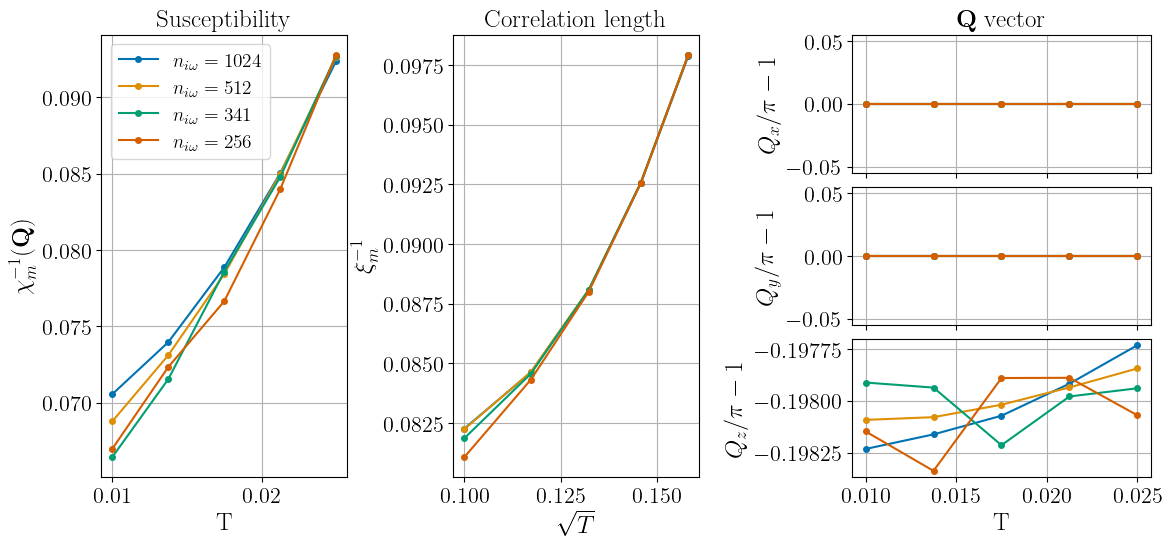

In [4]:
U = 3
n = 0.845
T_list = np.linspace(0.01, 0.025, 5)

lat = LATTICE()
initialize_bz(lat, nk=50, refine=False)
par_list = [{'U': U, 'n': n, 'T': T} for T in T_list]

Gamma = 0.05
niw_list = [1024//i for i in range(1,5)]
results_list = []
for niw in niw_list:
    results_list.append(sweep_rpa(par_list, lat, niw=niw, S_list=-1j*Gamma, get_xi=True, workers=5, xi_range=[0,0,5e-2], niw_fit=True))

fig = None
for results in results_list:
    niw = results['niw']
    fig, _ = pcut_chi(results, 'T', plot_Q=(1,1,1), x_exp=(1,0.5), fit=False, label=rf'$n_{{i\omega}} = {niw}$', figure=fig)
    
plt.show()

n: 0.843, U: 3.000: Completed 10 jobs in 550.2 seconds
n: 0.846, U: 3.000: Completed 10 jobs in 547.2 seconds
n: 0.849, U: 3.000: Completed 10 jobs in 545.9 seconds
n: 0.852, U: 3.000: Completed 10 jobs in 546.2 seconds
n: 0.855, U: 3.000: Completed 10 jobs in 547.1 seconds
n = 0.843 :
 chi: gamma = 1.005, Tc = -0.008, xi: nu = 1.183, Tc = -0.021
n = 0.846 :
 chi: gamma = 0.995, Tc = -0.001, xi: nu = 1.148, Tc = -0.014
n = 0.849 :
 chi: gamma = 0.991, Tc = 0.006, xi: nu = 1.130, Tc = -0.007
n = 0.852 :
 chi: gamma = 0.974, Tc = 0.013, xi: nu = 1.006, Tc = 0.006
n = 0.855 :
 chi: gamma = 0.980, Tc = 0.019, xi: nu = 0.824, Tc = 0.015


/home/ctort/Desktop/dmft/code/scripts/plot.py:447: OptimizeWarning: Covariance of the parameters could not be estimated
  fit_par_xi, _ = curve_fit(fit_xi, var_arr[pos_idx][:15]**x_exp[1], invxi[pos_idx][:15], p0=[1., 0.9*x_fit[0], 6., 0.05])


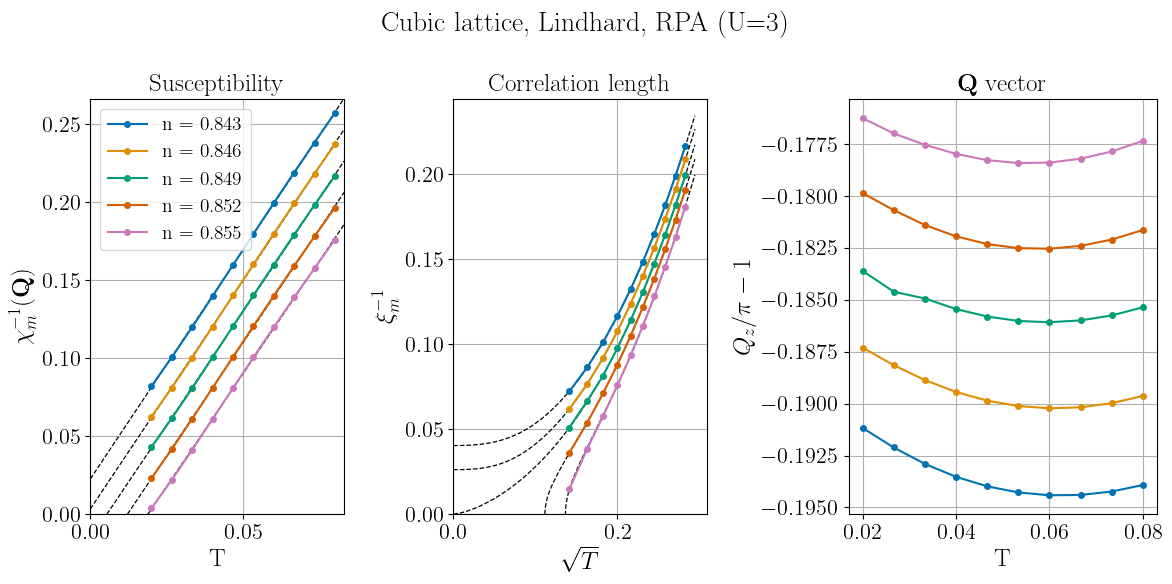

In [7]:
U = 3
#n_list = np.linspace(0.924, 0.926, 2)
#n_list = np.linspace(0.88, 0.885, 2)
n_list = np.linspace(0.843, 0.855, 5)
#n_list = np.linspace(0.76, 0.8, 2)
T_list = np.linspace(0.02, 0.08, 10)
title = f'Cubic lattice, Lindhard, RPA (U={U})'

lat = LATTICE()
initialize_bz(lat, nk=200, refine=False, ibz=True)

Gamma = 0.05
niw = 512
results_list = []
for n in n_list:
    par_list = [{'U': U, 'n': n, 'T': T} for T in T_list]
    results_list.append(sweep_rpa(par_list, lat, niw=niw, S_list=-1j*Gamma, get_xi=True, xi_range=[0,0,4e-2], fit=True, workers=5, niw_fit=True))
    #results_list.append(sweep_rpa(par_list, lat, q_path=([1,1,0.5],[1,1,1]), method='local', S_list=-1j*Gamma, get_xi=True, xi_range=[0,0,3e-2], fit=True, workers=5, niw_fit=True))

fig = None
for results in results_list:
    n = results['par_list'][0]['n']
    Tc_chi = results['fitchi']['Xc']
    gamma = results['fitchi']['b']
    Tc_xi = results['fitxi']['Xc']
    nu = results['fitxi']['b']
    print(f"n = {n} :\n chi: gamma = {gamma:.3f}, Tc = {Tc_chi:.3f}, xi: nu = {nu:.3f}, Tc = {Tc_xi:.3f}")
    fig, fit = pcut_chi(results, 'T', plot_Q=(0,0,1), x_exp=(1.,0.5), fit=True,
                        title=title, label=f'n = {n:.4g}', figure=fig)
    
    _, axs = fig
    for ax in axs[:2]:
        ax.set_xlim(left=0)
        ax.set_ylim(bottom=0)

plt.show()

n = 0.843 :
 chi: gamma = 1.005, Tc = -0.008, xi: nu = 1.183, Tc = -0.021
n = 0.846 :
 chi: gamma = 0.995, Tc = -0.001, xi: nu = 1.148, Tc = -0.014
n = 0.849 :
 chi: gamma = 0.991, Tc = 0.006, xi: nu = 1.130, Tc = -0.007
n = 0.852 :
 chi: gamma = 0.974, Tc = 0.013, xi: nu = 1.006, Tc = 0.006
n = 0.855 :
 chi: gamma = 0.980, Tc = 0.019, xi: nu = 0.824, Tc = 0.015


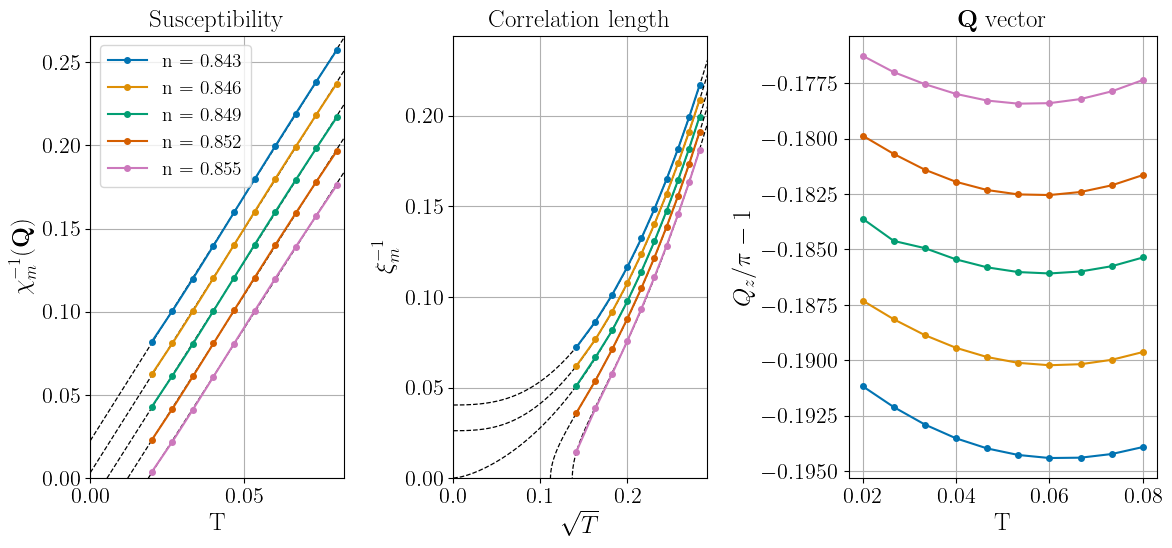

In [9]:
x_exp = (1.,0.5)
fig = None
for results in results_list:
    n = results['par_list'][0]['n']
    Tc_chi = results['fitchi']['Xc']
    gamma = results['fitchi']['b']
    Tc_xi = results['fitxi']['Xc']
    nu = results['fitxi']['b']
    print(f"n = {n} :\n chi: gamma = {gamma:.3f}, Tc = {Tc_chi:.3f}, xi: nu = {nu:.3f}, Tc = {Tc_xi:.3f}")
    fig, fit = pcut_chi(results, 'T', plot_Q=(0,0,1), x_exp=x_exp, fit=True, label=f'n = {n:.4g}', figure=fig)
    
    _, axs = fig
    for i, ax in enumerate(axs[:2]):
        ax.set_xlim(0, (T_list[-1])**x_exp[i]*1.03)
        ax.set_ylim(bottom=0)

plt.show()

SCBA: nk=100^3, niw=512, T=0.0200, mu=0.0000, v=0.050  [pyfftw]
Converged at step    3  diff=5.091e-14  mu=-0.701160
SCBA: nk=100^3, niw=512, T=0.0175, mu=-0.7012, v=0.050  [pyfftw]
Converged at step    2  diff=3.183e-12  mu=-0.701258
SCBA: nk=100^3, niw=512, T=0.0150, mu=-0.7013, v=0.050  [pyfftw]
Converged at step    2  diff=7.798e-12  mu=-0.701318
SCBA: nk=100^3, niw=512, T=0.0125, mu=-0.7013, v=0.050  [pyfftw]
Converged at step    2  diff=2.019e-11  mu=-0.701261
SCBA: nk=100^3, niw=512, T=0.0100, mu=-0.7013, v=0.050  [pyfftw]
Converged at step    2  diff=5.124e-11  mu=-0.700940


Starting serial run at: 2026-06-17 21:24:24.265313
Starting serial run at: 2026-06-17 21:24:24.291950
Starting serial run at: 2026-06-17 21:24:24.306177
Starting serial run at: 2026-06-17 21:24:24.353129
Starting serial run at: 2026-06-17 21:24:24.358747
/home/ctort/Desktop/dmft/code/scripts/obs.py:868: OptimizeWarning: Covariance of the parameters could not be estimated
  par, cov = curve_fit(fit, x_fit, y_fit, p0=p0, bounds=bounds, maxfev=10000)


n: 0.800, U: 3.000: Completed 5 jobs in 55.3 seconds
SCBA: nk=100^3, niw=256, T=0.0200, mu=0.0000, v=0.050  [pyfftw]
Converged at step    3  diff=4.626e-14  mu=-0.700223
SCBA: nk=100^3, niw=256, T=0.0175, mu=-0.7002, v=0.050  [pyfftw]
Converged at step    2  diff=2.918e-12  mu=-0.700074
SCBA: nk=100^3, niw=256, T=0.0150, mu=-0.7001, v=0.050  [pyfftw]
Converged at step    2  diff=7.169e-12  mu=-0.699922
SCBA: nk=100^3, niw=256, T=0.0125, mu=-0.6999, v=0.050  [pyfftw]
Converged at step    2  diff=1.905e-11  mu=-0.699951
SCBA: nk=100^3, niw=256, T=0.0100, mu=-0.7000, v=0.050  [pyfftw]
Converged at step    2  diff=5.301e-11  mu=-0.700930
n: 0.800, U: 3.000: Completed 5 jobs in 26.8 seconds
SCBA: nk=100^3, niw=170, T=0.0200, mu=0.0000, v=0.050  [pyfftw]
Converged at step    3  diff=4.388e-14  mu=-0.699741
SCBA: nk=100^3, niw=170, T=0.0175, mu=-0.6997, v=0.050  [pyfftw]
Converged at step    2  diff=2.958e-12  mu=-0.700081
SCBA: nk=100^3, niw=170, T=0.0150, mu=-0.7001, v=0.050  [pyfftw]
Conve

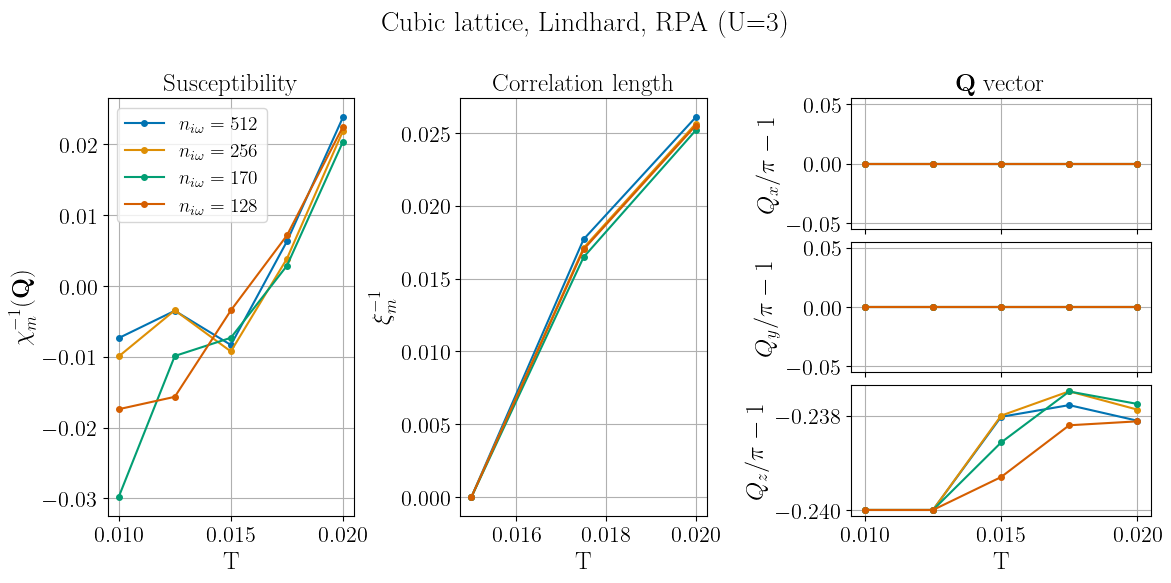

In [ ]:
U = 3
n = 0.8
T_list = np.linspace(0.02, 0.08, 5)
title = f'Cubic lattice, Lindhard, RPA (U={U})'

nk = 50
lat = LATTICE()
initialize_bz(lat, nk=nk, refine=False, ibz=True)

v = 0.05
niw_list = [512//i for i in range(1,5)]
results_list = []
for niw in niw_list:
    scba = SCBA(lat, niw, nk, disorder='nnn')
    #inputs = [{'v': v, 'beta': 1/T, 'n_goal': n, 'verbose': True} for T in T_list]
    #S_list = run_parallel(scba.run, inputs, workers=3)
    S_list = [None]
    mu = 0.
    for T in T_list:
        scba.run(v=v, beta=1/T, n_goal=n, init_S=S_list[-1], init_mu=mu, verbose=True)
        S_list.append(scba.S_iwk)
        mu = scba.run_stats['mu'][-1]
    S_list.pop(0)

    par_list = [{'U': U, 'n': n, 'T': T} for T in T_list]
    results_list.append(sweep_rpa(par_list, lat, nk=nk, niw=niw, S_list=S_list, get_xi=True, xi_range=[0,0,4e-2], fit=True, workers=5, niw_fit=True))
    del scba, S_list

fig = None
for results in results_list:
    niw = results['niw']
    Tc_chi = results['fitchi']['Xc']
    gamma = results['fitchi']['b']
    Tc_xi = results['fitxi']['Xc']
    nu = results['fitxi']['b']
    print(f"n = {n} :\n chi: gamma = {gamma:.3f}, Tc = {Tc_chi:.3f}, xi: nu = {nu:.3f}, Tc = {Tc_xi:.3f}")
    fig, fit = pcut_chi(results, 'T', plot_Q=(1,1,1), x_exp=(1,1), fit=False,
                        title=title, label=rf'$n_{{i\omega}} = {niw:.4g}$', figure=fig)
    
    #_, axs = fig
    #for ax in axs[:2]:
    #    ax.set_xlim(left=0)
    #    ax.set_ylim(bottom=0)

plt.show()

SCBA: nk=100^3, niw=512, T=0.0200, mu=0.0000, v=0.100  [pyfftw]
Converged at step    7  diff=4.287e-12  mu=-0.609841
SCBA: nk=100^3, niw=512, T=0.0267, mu=-0.6098, v=0.100  [pyfftw]
Converged at step    6  diff=3.688e-12  mu=-0.609948
SCBA: nk=100^3, niw=512, T=0.0333, mu=-0.6099, v=0.100  [pyfftw]
Converged at step    5  diff=7.459e-11  mu=-0.609972
SCBA: nk=100^3, niw=512, T=0.0400, mu=-0.6100, v=0.100  [pyfftw]
Converged at step    5  diff=5.415e-11  mu=-0.609969
SCBA: nk=100^3, niw=512, T=0.0467, mu=-0.6100, v=0.100  [pyfftw]
Converged at step    5  diff=4.090e-11  mu=-0.609953
SCBA: nk=100^3, niw=512, T=0.0533, mu=-0.6100, v=0.100  [pyfftw]
Converged at step    5  diff=3.182e-11  mu=-0.609930
SCBA: nk=100^3, niw=512, T=0.0600, mu=-0.6099, v=0.100  [pyfftw]
Converged at step    5  diff=2.536e-11  mu=-0.609902
SCBA: nk=100^3, niw=512, T=0.0667, mu=-0.6099, v=0.100  [pyfftw]
Converged at step    5  diff=2.061e-11  mu=-0.609869
SCBA: nk=100^3, niw=512, T=0.0733, mu=-0.6099, v=0.100  [

Starting serial run at: 2026-06-18 08:50:10.951300
Starting serial run at: 2026-06-18 08:50:10.991771
Starting serial run at: 2026-06-18 08:50:11.006274
Starting serial run at: 2026-06-18 08:50:11.033790
Starting serial run at: 2026-06-18 08:50:11.080564
/home/ctort/Desktop/dmft/code/scripts/obs.py:595: OptimizeWarning: Covariance of the parameters could not be estimated
  par, _ = curve_fit(OZ_fit, s_grid, chi_grid, p0=p0, bounds=bounds, maxfev=10000)
/home/ctort/Desktop/dmft/code/scripts/obs.py:595: OptimizeWarning: Covariance of the parameters could not be estimated
  par, _ = curve_fit(OZ_fit, s_grid, chi_grid, p0=p0, bounds=bounds, maxfev=10000)
/home/ctort/Desktop/dmft/code/scripts/obs.py:595: OptimizeWarning: Covariance of the parameters could not be estimated
  par, _ = curve_fit(OZ_fit, s_grid, chi_grid, p0=p0, bounds=bounds, maxfev=10000)
/home/ctort/Desktop/dmft/code/scripts/obs.py:595: OptimizeWarning: Covariance of the parameters could not be estimated
  par, _ = curve_fit

n: 0.830, U: 3.000: Completed 10 jobs in 64.4 seconds
SCBA: nk=100^3, niw=512, T=0.0200, mu=0.0000, v=0.100  [pyfftw]
Converged at step    7  diff=3.636e-12  mu=-0.591995
SCBA: nk=100^3, niw=512, T=0.0267, mu=-0.5920, v=0.100  [pyfftw]
Converged at step    6  diff=3.629e-12  mu=-0.592097
SCBA: nk=100^3, niw=512, T=0.0333, mu=-0.5921, v=0.100  [pyfftw]
Converged at step    5  diff=7.415e-11  mu=-0.592119
SCBA: nk=100^3, niw=512, T=0.0400, mu=-0.5921, v=0.100  [pyfftw]
Converged at step    5  diff=5.418e-11  mu=-0.592115
SCBA: nk=100^3, niw=512, T=0.0467, mu=-0.5921, v=0.100  [pyfftw]
Converged at step    5  diff=4.110e-11  mu=-0.592099
SCBA: nk=100^3, niw=512, T=0.0533, mu=-0.5921, v=0.100  [pyfftw]
Converged at step    5  diff=3.210e-11  mu=-0.592076
SCBA: nk=100^3, niw=512, T=0.0600, mu=-0.5921, v=0.100  [pyfftw]
Converged at step    5  diff=2.568e-11  mu=-0.592049
SCBA: nk=100^3, niw=512, T=0.0667, mu=-0.5920, v=0.100  [pyfftw]
Converged at step    5  diff=2.094e-11  mu=-0.592017
SCB

Starting serial run at: 2026-06-18 08:58:43.688820
Starting serial run at: 2026-06-18 08:58:43.689727
Starting serial run at: 2026-06-18 08:58:43.703634
Starting serial run at: 2026-06-18 08:58:43.758131
Starting serial run at: 2026-06-18 08:58:43.771959
/home/ctort/Desktop/dmft/code/scripts/obs.py:595: OptimizeWarning: Covariance of the parameters could not be estimated
  par, _ = curve_fit(OZ_fit, s_grid, chi_grid, p0=p0, bounds=bounds, maxfev=10000)
/home/ctort/Desktop/dmft/code/scripts/obs.py:595: OptimizeWarning: Covariance of the parameters could not be estimated
  par, _ = curve_fit(OZ_fit, s_grid, chi_grid, p0=p0, bounds=bounds, maxfev=10000)
/home/ctort/Desktop/dmft/code/scripts/obs.py:595: OptimizeWarning: Covariance of the parameters could not be estimated
  par, _ = curve_fit(OZ_fit, s_grid, chi_grid, p0=p0, bounds=bounds, maxfev=10000)
/home/ctort/Desktop/dmft/code/scripts/obs.py:595: OptimizeWarning: Covariance of the parameters could not be estimated
  par, _ = curve_fit

n: 0.835, U: 3.000: Completed 10 jobs in 65.5 seconds
SCBA: nk=100^3, niw=512, T=0.0200, mu=0.0000, v=0.100  [pyfftw]
Converged at step    7  diff=3.716e-12  mu=-0.574124
SCBA: nk=100^3, niw=512, T=0.0267, mu=-0.5741, v=0.100  [pyfftw]
Converged at step    6  diff=3.607e-12  mu=-0.574230
SCBA: nk=100^3, niw=512, T=0.0333, mu=-0.5742, v=0.100  [pyfftw]
Converged at step    5  diff=7.383e-11  mu=-0.574255
SCBA: nk=100^3, niw=512, T=0.0400, mu=-0.5743, v=0.100  [pyfftw]
Converged at step    5  diff=5.421e-11  mu=-0.574252
SCBA: nk=100^3, niw=512, T=0.0467, mu=-0.5743, v=0.100  [pyfftw]
Converged at step    5  diff=4.128e-11  mu=-0.574237
SCBA: nk=100^3, niw=512, T=0.0533, mu=-0.5742, v=0.100  [pyfftw]
Converged at step    5  diff=3.237e-11  mu=-0.574215
SCBA: nk=100^3, niw=512, T=0.0600, mu=-0.5742, v=0.100  [pyfftw]
Converged at step    5  diff=2.598e-11  mu=-0.574188
SCBA: nk=100^3, niw=512, T=0.0667, mu=-0.5742, v=0.100  [pyfftw]
Converged at step    5  diff=2.126e-11  mu=-0.574157
SCB

...

n: 0.840, U: 3.000: Completed 10 jobs in 64.5 seconds
SCBA: nk=100^3, niw=512, T=0.0200, mu=0.0000, v=0.100  [pyfftw]
Converged at step    7  diff=4.414e-12  mu=-0.556238
SCBA: nk=100^3, niw=512, T=0.0267, mu=-0.5562, v=0.100  [pyfftw]
Converged at step    6  diff=3.639e-12  mu=-0.556352
SCBA: nk=100^3, niw=512, T=0.0333, mu=-0.5564, v=0.100  [pyfftw]
Converged at step    5  diff=7.379e-11  mu=-0.556381
SCBA: nk=100^3, niw=512, T=0.0400, mu=-0.5564, v=0.100  [pyfftw]
Converged at step    5  diff=5.427e-11  mu=-0.556381
SCBA: nk=100^3, niw=512, T=0.0467, mu=-0.5564, v=0.100  [pyfftw]
Converged at step    5  diff=4.146e-11  mu=-0.556368
SCBA: nk=100^3, niw=512, T=0.0533, mu=-0.5564, v=0.100  [pyfftw]
Converged at step    5  diff=3.262e-11  mu=-0.556347
SCBA: nk=100^3, niw=512, T=0.0600, mu=-0.5563, v=0.100  [pyfftw]
Converged at step    5  diff=2.628e-11  mu=-0.556321
SCBA: nk=100^3, niw=512, T=0.0667, mu=-0.5563, v=0.100  [pyfftw]
Converged at step    5  diff=2.158e-11  mu=-0.556290
SCB

Starting serial run at: 2026-06-18 09:15:47.366841
Starting serial run at: 2026-06-18 09:15:47.367505
Starting serial run at: 2026-06-18 09:15:47.370503
Starting serial run at: 2026-06-18 09:15:47.433652
Starting serial run at: 2026-06-18 09:15:47.437204
/home/ctort/Desktop/dmft/code/scripts/obs.py:595: OptimizeWarning: Covariance of the parameters could not be estimated
  par, _ = curve_fit(OZ_fit, s_grid, chi_grid, p0=p0, bounds=bounds, maxfev=10000)
/home/ctort/Desktop/dmft/code/scripts/obs.py:595: OptimizeWarning: Covariance of the parameters could not be estimated
  par, _ = curve_fit(OZ_fit, s_grid, chi_grid, p0=p0, bounds=bounds, maxfev=10000)
/home/ctort/Desktop/dmft/code/scripts/obs.py:595: OptimizeWarning: Covariance of the parameters could not be estimated
  par, _ = curve_fit(OZ_fit, s_grid, chi_grid, p0=p0, bounds=bounds, maxfev=10000)
/home/ctort/Desktop/dmft/code/scripts/obs.py:595: OptimizeWarning: Covariance of the parameters could not be estimated
  par, _ = curve_fit

n: 0.845, U: 3.000: Completed 10 jobs in 65.0 seconds
SCBA: nk=100^3, niw=512, T=0.0200, mu=0.0000, v=0.100  [pyfftw]
Converged at step    7  diff=5.394e-12  mu=-0.538354
SCBA: nk=100^3, niw=512, T=0.0267, mu=-0.5384, v=0.100  [pyfftw]
Converged at step    6  diff=3.705e-12  mu=-0.538470
SCBA: nk=100^3, niw=512, T=0.0333, mu=-0.5385, v=0.100  [pyfftw]
Converged at step    5  diff=7.391e-11  mu=-0.538502
SCBA: nk=100^3, niw=512, T=0.0400, mu=-0.5385, v=0.100  [pyfftw]
Converged at step    5  diff=5.436e-11  mu=-0.538504
SCBA: nk=100^3, niw=512, T=0.0467, mu=-0.5385, v=0.100  [pyfftw]
Converged at step    5  diff=4.162e-11  mu=-0.538491
SCBA: nk=100^3, niw=512, T=0.0533, mu=-0.5385, v=0.100  [pyfftw]
Converged at step    5  diff=3.285e-11  mu=-0.538471
SCBA: nk=100^3, niw=512, T=0.0600, mu=-0.5385, v=0.100  [pyfftw]
Converged at step    5  diff=2.656e-11  mu=-0.538446
SCBA: nk=100^3, niw=512, T=0.0667, mu=-0.5384, v=0.100  [pyfftw]
Converged at step    5  diff=2.190e-11  mu=-0.538417
SCB

Starting serial run at: 2026-06-18 09:24:30.952321
Starting serial run at: 2026-06-18 09:24:30.966964
Starting serial run at: 2026-06-18 09:24:30.978511
Starting serial run at: 2026-06-18 09:24:31.020854
Starting serial run at: 2026-06-18 09:24:31.050349
/home/ctort/Desktop/dmft/code/scripts/obs.py:595: OptimizeWarning: Covariance of the parameters could not be estimated
  par, _ = curve_fit(OZ_fit, s_grid, chi_grid, p0=p0, bounds=bounds, maxfev=10000)
/home/ctort/Desktop/dmft/code/scripts/obs.py:595: OptimizeWarning: Covariance of the parameters could not be estimated
  par, _ = curve_fit(OZ_fit, s_grid, chi_grid, p0=p0, bounds=bounds, maxfev=10000)
/home/ctort/Desktop/dmft/code/scripts/obs.py:595: OptimizeWarning: Covariance of the parameters could not be estimated
  par, _ = curve_fit(OZ_fit, s_grid, chi_grid, p0=p0, bounds=bounds, maxfev=10000)
/home/ctort/Desktop/dmft/code/scripts/obs.py:595: OptimizeWarning: Covariance of the parameters could not be estimated
  par, _ = curve_fit

n: 0.850, U: 3.000: Completed 10 jobs in 64.3 seconds
n = 0.83 :
 chi: gamma = 0.796, Tc = -0.006, xi: nu = 1.110, Tc = -0.031
n = 0.835 :
 chi: gamma = 0.784, Tc = -0.001, xi: nu = 1.058, Tc = -0.020
n = 0.84 :
 chi: gamma = 0.796, Tc = 0.003, xi: nu = 1.070, Tc = -0.015
n = 0.845 :
 chi: gamma = 0.769, Tc = 0.009, xi: nu = 0.939, Tc = -0.001
n = 0.85 :
 chi: gamma = 0.747, Tc = 0.016, xi: nu = 0.753, Tc = 0.011


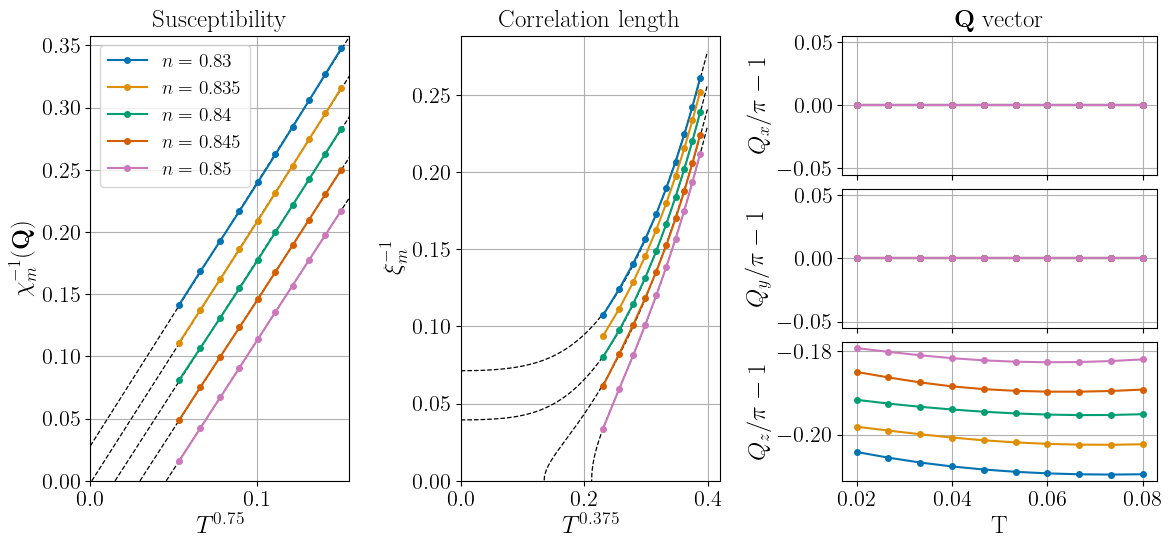

In [ ]:
U = 3
n_list = np.linspace(0.83, 0.85, 5)
T_list = np.linspace(0.02, 0.08, 10)
title = f'Cubic lattice, Lindhard, RPA (U={U})'

nk = 100
lat = LATTICE()
initialize_bz(lat, nk=nk, refine=False, ibz=True)

v = 0.1
niw = 512
results_list = []
for n in n_list:
    scba = SCBA(lat, niw, nk, disorder='nnn')
    #inputs = [{'v': v, 'beta': 1/T, 'n_goal': n, 'verbose': True} for T in T_list]
    #S_list = run_parallel(scba.run, inputs, workers=3)
    S_list = [None]
    mu = 0.
    for T in T_list:
        scba.run(v=v, beta=1/T, n_goal=n, init_S=S_list[-1], init_mu=mu, verbose=True)
        S_list.append(scba.S_iwk)
        mu = scba.run_stats['mu'][-1]
    S_list.pop(0)

    par_list = [{'U': U, 'n': n, 'T': T} for T in T_list]
    results_list.append(sweep_rpa(par_list, lat, nk=nk, niw=niw, S_list=S_list, get_xi=True, xi_range=[0,0,4e-2], fit=True, workers=5, niw_fit=True))
    del scba, S_list

fig = None
for results in results_list:
    n = results['par_list'][0]['n']
    Tc_chi = results['fitchi']['Xc']
    gamma = results['fitchi']['b']
    Tc_xi = results['fitxi']['Xc']
    nu = results['fitxi']['b']
    print(f"n = {n} :\n chi: gamma = {gamma:.3f}, Tc = {Tc_chi:.3f}, xi: nu = {nu:.3f}, Tc = {Tc_xi:.3f}")
    fig, fit = pcut_chi(results, 'T', plot_Q=(1,1,1), x_exp=(3/4,3/8), fit=True, label=rf'$n = {n:.4g}$', figure=fig)
    
    _, axs = fig
    for i, ax in enumerate(axs[:2]):
        ax.set_xlim(0, (T_list[-1])**x_exp[i]*1.03)
        ax.set_ylim(bottom=0)

plt.show()

n = 0.83 :
 chi: gamma = 0.796, Tc = -0.006, xi: nu = 1.110, Tc = -0.031
n = 0.835 :
 chi: gamma = 0.784, Tc = -0.001, xi: nu = 1.058, Tc = -0.020
n = 0.84 :
 chi: gamma = 0.796, Tc = 0.003, xi: nu = 1.070, Tc = -0.015
n = 0.845 :
 chi: gamma = 0.769, Tc = 0.009, xi: nu = 0.939, Tc = -0.001
n = 0.85 :
 chi: gamma = 0.747, Tc = 0.016, xi: nu = 0.753, Tc = 0.011


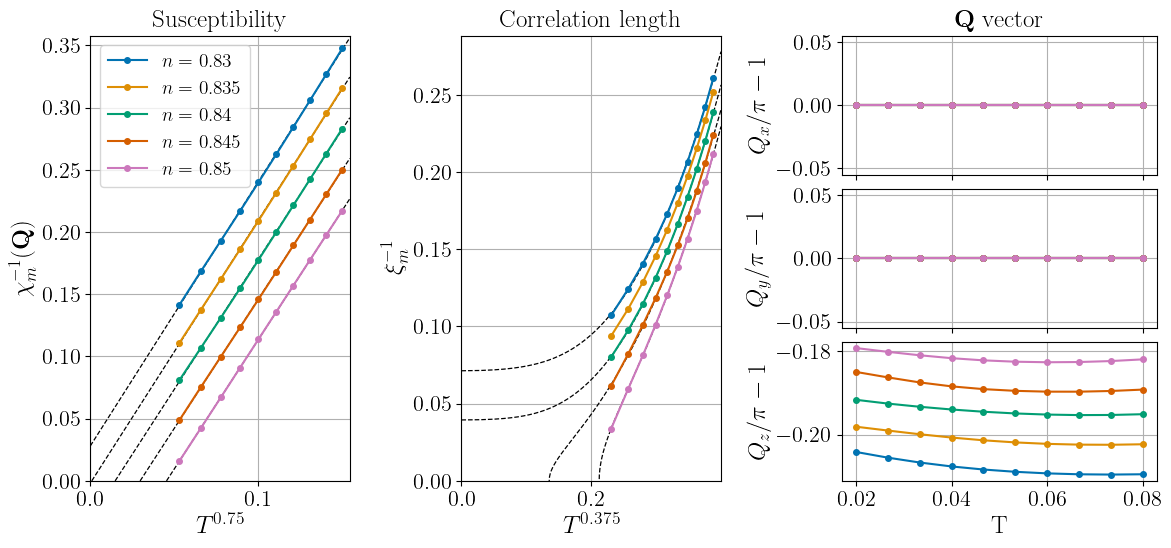

In [32]:
x_exp = (3/4,3/8)
fig = None
for results in results_list:
    n = results['par_list'][0]['n']
    Tc_chi = results['fitchi']['Xc']
    gamma = results['fitchi']['b']
    Tc_xi = results['fitxi']['Xc']
    nu = results['fitxi']['b']
    print(f"n = {n} :\n chi: gamma = {gamma:.3f}, Tc = {Tc_chi:.3f}, xi: nu = {nu:.3f}, Tc = {Tc_xi:.3f}")
    fig, fit = pcut_chi(results, 'T', plot_Q=(1,1,1), x_exp=x_exp, fit=True, label=rf'$n = {n:.4g}$', figure=fig)
    
    _, axs = fig
    for i, ax in enumerate(axs[:2]):
        ax.set_xlim(0, (T_list[-1])**x_exp[i]*1.03)
        ax.set_ylim(bottom=0)

plt.show()

SCBA: nk=100^3, niw=512, T=0.0200, mu=0.0000, v=0.050  [pyfftw]
Converged at step    5  diff=2.367e-12  mu=-0.739689
SCBA: nk=100^3, niw=512, T=0.0267, mu=-0.7397, v=0.050  [pyfftw]
Converged at step    4  diff=4.406e-12  mu=-0.739836
SCBA: nk=100^3, niw=512, T=0.0333, mu=-0.7398, v=0.050  [pyfftw]
Converged at step    4  diff=2.721e-12  mu=-0.739883
SCBA: nk=100^3, niw=512, T=0.0400, mu=-0.7399, v=0.050  [pyfftw]
Converged at step    4  diff=1.912e-12  mu=-0.739895
SCBA: nk=100^3, niw=512, T=0.0467, mu=-0.7399, v=0.050  [pyfftw]
Converged at step    4  diff=1.429e-12  mu=-0.739893
SCBA: nk=100^3, niw=512, T=0.0533, mu=-0.7399, v=0.050  [pyfftw]
Converged at step    4  diff=1.108e-12  mu=-0.739885
SCBA: nk=100^3, niw=512, T=0.0600, mu=-0.7399, v=0.050  [pyfftw]
Converged at step    4  diff=8.822e-13  mu=-0.739872
SCBA: nk=100^3, niw=512, T=0.0667, mu=-0.7399, v=0.050  [pyfftw]
Converged at step    3  diff=9.321e-11  mu=-0.739856
SCBA: nk=100^3, niw=512, T=0.0733, mu=-0.7399, v=0.050  [

Starting serial run at: 2026-06-18 09:36:46.485389
Starting serial run at: 2026-06-18 09:36:46.487169
Starting serial run at: 2026-06-18 09:36:46.516478
Starting serial run at: 2026-06-18 09:36:46.537684
Starting serial run at: 2026-06-18 09:36:46.546463
/home/ctort/Desktop/dmft/code/scripts/obs.py:595: OptimizeWarning: Covariance of the parameters could not be estimated
  par, _ = curve_fit(OZ_fit, s_grid, chi_grid, p0=p0, bounds=bounds, maxfev=10000)
/home/ctort/Desktop/dmft/code/scripts/obs.py:595: OptimizeWarning: Covariance of the parameters could not be estimated
  par, _ = curve_fit(OZ_fit, s_grid, chi_grid, p0=p0, bounds=bounds, maxfev=10000)
/home/ctort/Desktop/dmft/code/scripts/obs.py:595: OptimizeWarning: Covariance of the parameters could not be estimated
  par, _ = curve_fit(OZ_fit, s_grid, chi_grid, p0=p0, bounds=bounds, maxfev=10000)
/home/ctort/Desktop/dmft/code/scripts/obs.py:595: OptimizeWarning: Covariance of the parameters could not be estimated
  par, _ = curve_fit

n: 0.790, U: 3.000: Completed 10 jobs in 64.8 seconds
SCBA: nk=100^3, niw=512, T=0.0200, mu=0.0000, v=0.050  [pyfftw]
Converged at step    4  diff=7.171e-11  mu=-0.722387
SCBA: nk=100^3, niw=512, T=0.0267, mu=-0.7224, v=0.050  [pyfftw]
Converged at step    4  diff=3.744e-12  mu=-0.722386
SCBA: nk=100^3, niw=512, T=0.0333, mu=-0.7224, v=0.050  [pyfftw]
Converged at step    4  diff=2.606e-12  mu=-0.722365
SCBA: nk=100^3, niw=512, T=0.0400, mu=-0.7224, v=0.050  [pyfftw]
Converged at step    4  diff=1.899e-12  mu=-0.722348
SCBA: nk=100^3, niw=512, T=0.0467, mu=-0.7223, v=0.050  [pyfftw]
Converged at step    4  diff=1.438e-12  mu=-0.722334
SCBA: nk=100^3, niw=512, T=0.0533, mu=-0.7223, v=0.050  [pyfftw]
Converged at step    4  diff=1.121e-12  mu=-0.722321
SCBA: nk=100^3, niw=512, T=0.0600, mu=-0.7223, v=0.050  [pyfftw]
Converged at step    4  diff=8.965e-13  mu=-0.722307
SCBA: nk=100^3, niw=512, T=0.0667, mu=-0.7223, v=0.050  [pyfftw]
Converged at step    3  diff=9.391e-11  mu=-0.722291
SCB

Starting serial run at: 2026-06-18 09:43:31.671394
Starting serial run at: 2026-06-18 09:43:31.688816
Starting serial run at: 2026-06-18 09:43:31.708289
Starting serial run at: 2026-06-18 09:43:31.710112
Starting serial run at: 2026-06-18 09:43:31.725450
/home/ctort/Desktop/dmft/code/scripts/obs.py:595: OptimizeWarning: Covariance of the parameters could not be estimated
  par, _ = curve_fit(OZ_fit, s_grid, chi_grid, p0=p0, bounds=bounds, maxfev=10000)
/home/ctort/Desktop/dmft/code/scripts/obs.py:595: OptimizeWarning: Covariance of the parameters could not be estimated
  par, _ = curve_fit(OZ_fit, s_grid, chi_grid, p0=p0, bounds=bounds, maxfev=10000)
/home/ctort/Desktop/dmft/code/scripts/obs.py:595: OptimizeWarning: Covariance of the parameters could not be estimated
  par, _ = curve_fit(OZ_fit, s_grid, chi_grid, p0=p0, bounds=bounds, maxfev=10000)
/home/ctort/Desktop/dmft/code/scripts/obs.py:595: OptimizeWarning: Covariance of the parameters could not be estimated
  par, _ = curve_fit

n: 0.795, U: 3.000: Completed 10 jobs in 64.7 seconds
SCBA: nk=100^3, niw=512, T=0.0200, mu=0.0000, v=0.050  [pyfftw]
Converged at step    4  diff=5.863e-11  mu=-0.704875
SCBA: nk=100^3, niw=512, T=0.0267, mu=-0.7049, v=0.050  [pyfftw]
Converged at step    4  diff=3.217e-12  mu=-0.704843
SCBA: nk=100^3, niw=512, T=0.0333, mu=-0.7048, v=0.050  [pyfftw]
Converged at step    4  diff=2.486e-12  mu=-0.704806
SCBA: nk=100^3, niw=512, T=0.0400, mu=-0.7048, v=0.050  [pyfftw]
Converged at step    4  diff=1.879e-12  mu=-0.704782
SCBA: nk=100^3, niw=512, T=0.0467, mu=-0.7048, v=0.050  [pyfftw]
Converged at step    4  diff=1.443e-12  mu=-0.704766
SCBA: nk=100^3, niw=512, T=0.0533, mu=-0.7048, v=0.050  [pyfftw]
Converged at step    4  diff=1.133e-12  mu=-0.704752
SCBA: nk=100^3, niw=512, T=0.0600, mu=-0.7048, v=0.050  [pyfftw]
Converged at step    4  diff=9.096e-13  mu=-0.704737
SCBA: nk=100^3, niw=512, T=0.0667, mu=-0.7047, v=0.050  [pyfftw]
Converged at step    3  diff=9.461e-11  mu=-0.704721
SCB

...

n: 0.800, U: 3.000: Completed 10 jobs in 64.2 seconds
SCBA: nk=100^3, niw=512, T=0.0200, mu=0.0000, v=0.050  [pyfftw]
Converged at step    4  diff=6.097e-11  mu=-0.687115
SCBA: nk=100^3, niw=512, T=0.0267, mu=-0.6871, v=0.050  [pyfftw]
Converged at step    4  diff=3.182e-12  mu=-0.687187
SCBA: nk=100^3, niw=512, T=0.0333, mu=-0.6872, v=0.050  [pyfftw]
Converged at step    4  diff=2.463e-12  mu=-0.687198
SCBA: nk=100^3, niw=512, T=0.0400, mu=-0.6872, v=0.050  [pyfftw]
Converged at step    4  diff=1.879e-12  mu=-0.687195
SCBA: nk=100^3, niw=512, T=0.0467, mu=-0.6872, v=0.050  [pyfftw]
Converged at step    4  diff=1.452e-12  mu=-0.687187
SCBA: nk=100^3, niw=512, T=0.0533, mu=-0.6872, v=0.050  [pyfftw]
Converged at step    4  diff=1.146e-12  mu=-0.687176
SCBA: nk=100^3, niw=512, T=0.0600, mu=-0.6872, v=0.050  [pyfftw]
Converged at step    4  diff=9.226e-13  mu=-0.687163
SCBA: nk=100^3, niw=512, T=0.0667, mu=-0.6872, v=0.050  [pyfftw]
Converged at step    3  diff=9.533e-11  mu=-0.687148
SCB

Starting serial run at: 2026-06-18 09:56:41.145599
Starting serial run at: 2026-06-18 09:56:41.147666
Starting serial run at: 2026-06-18 09:56:41.172204
Starting serial run at: 2026-06-18 09:56:41.181771
Starting serial run at: 2026-06-18 09:56:41.233603
/home/ctort/Desktop/dmft/code/scripts/obs.py:595: OptimizeWarning: Covariance of the parameters could not be estimated
  par, _ = curve_fit(OZ_fit, s_grid, chi_grid, p0=p0, bounds=bounds, maxfev=10000)
/home/ctort/Desktop/dmft/code/scripts/obs.py:595: OptimizeWarning: Covariance of the parameters could not be estimated
  par, _ = curve_fit(OZ_fit, s_grid, chi_grid, p0=p0, bounds=bounds, maxfev=10000)
/home/ctort/Desktop/dmft/code/scripts/obs.py:595: OptimizeWarning: Covariance of the parameters could not be estimated
  par, _ = curve_fit(OZ_fit, s_grid, chi_grid, p0=p0, bounds=bounds, maxfev=10000)
/home/ctort/Desktop/dmft/code/scripts/obs.py:595: OptimizeWarning: Covariance of the parameters could not be estimated
  par, _ = curve_fit

n: 0.805, U: 3.000: Completed 10 jobs in 64.2 seconds
SCBA: nk=100^3, niw=512, T=0.0200, mu=0.0000, v=0.050  [pyfftw]
Converged at step    5  diff=9.320e-13  mu=-0.669258
SCBA: nk=100^3, niw=512, T=0.0267, mu=-0.6693, v=0.050  [pyfftw]
Converged at step    4  diff=3.507e-12  mu=-0.669484
SCBA: nk=100^3, niw=512, T=0.0333, mu=-0.6695, v=0.050  [pyfftw]
Converged at step    4  diff=2.547e-12  mu=-0.669568
SCBA: nk=100^3, niw=512, T=0.0400, mu=-0.6696, v=0.050  [pyfftw]
Converged at step    4  diff=1.907e-12  mu=-0.669597
SCBA: nk=100^3, niw=512, T=0.0467, mu=-0.6696, v=0.050  [pyfftw]
Converged at step    4  diff=1.468e-12  mu=-0.669602
SCBA: nk=100^3, niw=512, T=0.0533, mu=-0.6696, v=0.050  [pyfftw]
Converged at step    4  diff=1.160e-12  mu=-0.669596
SCBA: nk=100^3, niw=512, T=0.0600, mu=-0.6696, v=0.050  [pyfftw]
Converged at step    4  diff=9.361e-13  mu=-0.669586
SCBA: nk=100^3, niw=512, T=0.0667, mu=-0.6696, v=0.050  [pyfftw]
Converged at step    3  diff=9.607e-11  mu=-0.669572
SCB

Starting serial run at: 2026-06-18 10:03:30.320914
Starting serial run at: 2026-06-18 10:03:30.328166
Starting serial run at: 2026-06-18 10:03:30.328245
Starting serial run at: 2026-06-18 10:03:30.377339
Starting serial run at: 2026-06-18 10:03:30.379985
/home/ctort/Desktop/dmft/code/scripts/obs.py:595: OptimizeWarning: Covariance of the parameters could not be estimated
  par, _ = curve_fit(OZ_fit, s_grid, chi_grid, p0=p0, bounds=bounds, maxfev=10000)
/home/ctort/Desktop/dmft/code/scripts/obs.py:595: OptimizeWarning: Covariance of the parameters could not be estimated
  par, _ = curve_fit(OZ_fit, s_grid, chi_grid, p0=p0, bounds=bounds, maxfev=10000)
/home/ctort/Desktop/dmft/code/scripts/obs.py:595: OptimizeWarning: Covariance of the parameters could not be estimated
  par, _ = curve_fit(OZ_fit, s_grid, chi_grid, p0=p0, bounds=bounds, maxfev=10000)
/home/ctort/Desktop/dmft/code/scripts/obs.py:595: OptimizeWarning: Covariance of the parameters could not be estimated
  par, _ = curve_fit

n: 0.810, U: 3.000: Completed 10 jobs in 64.2 seconds
n = 0.79 :
 chi: gamma = 0.759, Tc = -0.002, xi: nu = 1.109, Tc = -0.015
n = 0.795 :
 chi: gamma = 0.706, Tc = 0.001, xi: nu = 1.070, Tc = -0.010
n = 0.8 :
 chi: gamma = 0.710, Tc = 0.004, xi: nu = 0.945, Tc = 0.000
n = 0.805 :
 chi: gamma = 0.818, Tc = 0.004, xi: nu = 1.132, Tc = -0.009
n = 0.81 :
 chi: gamma = 0.754, Tc = 0.009, xi: nu = 1.068, Tc = -0.000


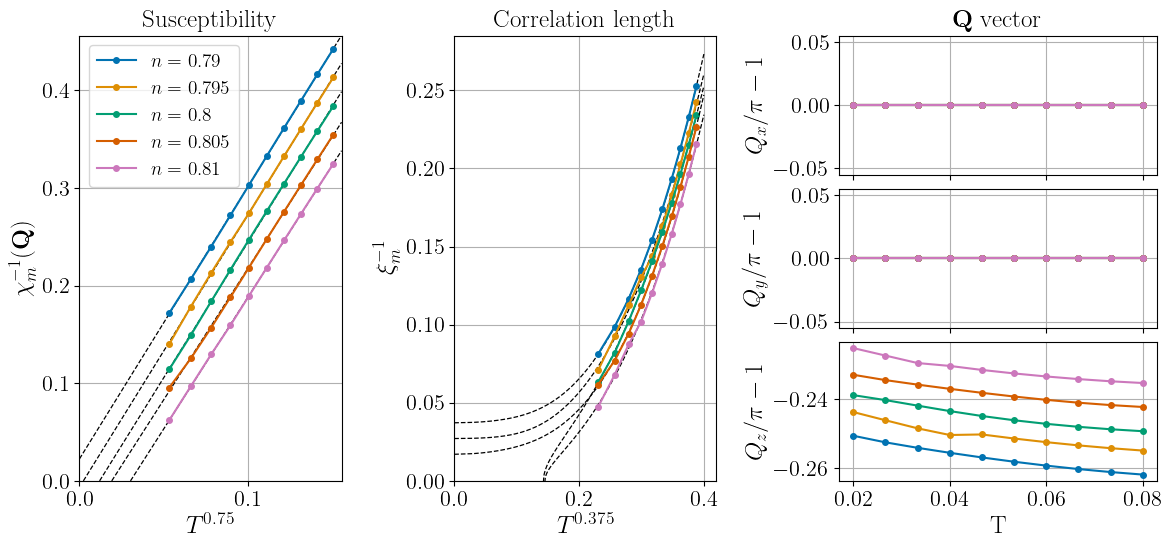

In [ ]:
U = 3
n_list = np.linspace(0.79, 0.81, 5)
T_list = np.linspace(0.02, 0.08, 10)
title = f'Cubic lattice, Lindhard, RPA (U={U})'

nk = 100
lat = LATTICE()
initialize_bz(lat, nk=nk, refine=False, ibz=True)

v = 0.05
niw = 512
results_list = []
for n in n_list:
    scba = SCBA(lat, niw, nk, disorder='nnn')
    #inputs = [{'v': v, 'beta': 1/T, 'n_goal': n, 'verbose': True} for T in T_list]
    #S_list = run_parallel(scba.run, inputs, workers=3)
    S_list = [None]
    mu = 0.
    for T in T_list:
        scba.run(v=v, beta=1/T, n_goal=n, init_S=S_list[-1], init_mu=mu, verbose=True)
        S_list.append(scba.S_iwk)
        mu = scba.run_stats['mu'][-1]
    S_list.pop(0)

    par_list = [{'U': U, 'n': n, 'T': T} for T in T_list]
    results_list.append(sweep_rpa(par_list, lat, nk=nk, niw=niw, S_list=S_list, get_xi=True, xi_range=[0,0,4e-2], fit=True, workers=5, niw_fit=True))
    del scba, S_list

fig = None
for results in results_list:
    n = results['par_list'][0]['n']
    Tc_chi = results['fitchi']['Xc']
    gamma = results['fitchi']['b']
    Tc_xi = results['fitxi']['Xc']
    nu = results['fitxi']['b']
    print(f"n = {n} :\n chi: gamma = {gamma:.3f}, Tc = {Tc_chi:.3f}, xi: nu = {nu:.3f}, Tc = {Tc_xi:.3f}")
    fig, fit = pcut_chi(results, 'T', plot_Q=(1,1,1), x_exp=(3/4,3/8), fit=True, label=rf'$n = {n:.4g}$', figure=fig)
    
    _, axs = fig
    for i, ax in enumerate(axs[:2]):
        ax.set_xlim(0, (T_list[-1])**x_exp[i]*1.03)
        ax.set_ylim(bottom=0)

plt.show()

n = 0.79 :
 chi: gamma = 0.759, Tc = -0.002, xi: nu = 1.109, Tc = -0.015
n = 0.795 :
 chi: gamma = 0.706, Tc = 0.001, xi: nu = 1.070, Tc = -0.010
n = 0.8 :
 chi: gamma = 0.710, Tc = 0.004, xi: nu = 0.945, Tc = 0.000
n = 0.805 :
 chi: gamma = 0.818, Tc = 0.004, xi: nu = 1.132, Tc = -0.009
n = 0.81 :
 chi: gamma = 0.754, Tc = 0.009, xi: nu = 1.068, Tc = -0.000


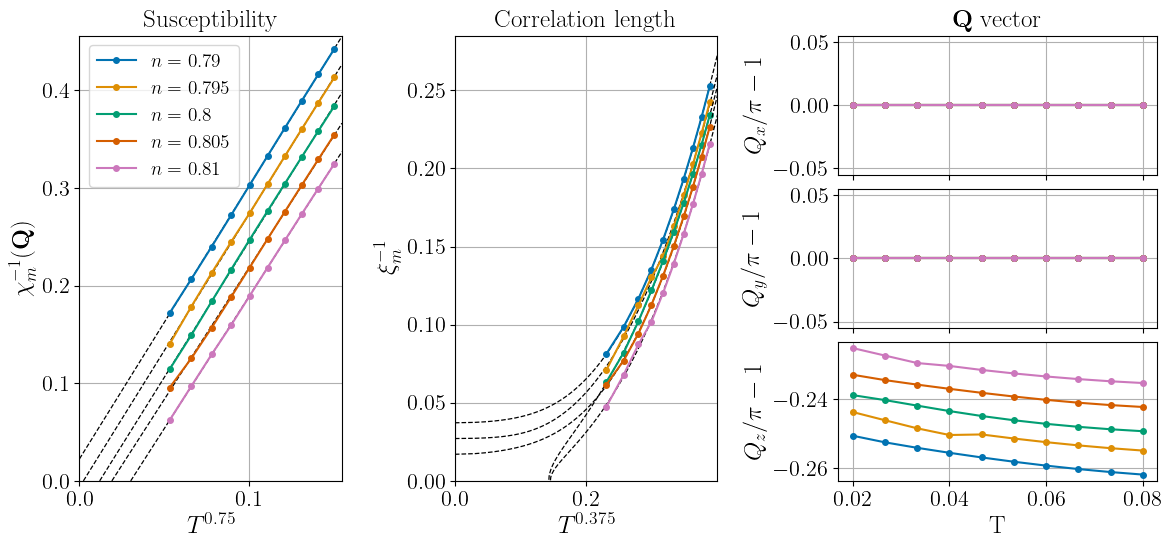

In [34]:
fig = None
for results in results_list:
    n = results['par_list'][0]['n']
    Tc_chi = results['fitchi']['Xc']
    gamma = results['fitchi']['b']
    Tc_xi = results['fitxi']['Xc']
    nu = results['fitxi']['b']
    print(f"n = {n} :\n chi: gamma = {gamma:.3f}, Tc = {Tc_chi:.3f}, xi: nu = {nu:.3f}, Tc = {Tc_xi:.3f}")
    fig, fit = pcut_chi(results, 'T', plot_Q=(1,1,1), x_exp=(3/4,3/8), fit=True, label=rf'$n = {n:.4g}$', figure=fig)
    
    _, axs = fig
    for i, ax in enumerate(axs[:2]):
        ax.set_xlim(0, (T_list[-1])**x_exp[i]*1.03)
        ax.set_ylim(bottom=0)

plt.show()

n = 0.78 :
 chi: gamma = 0.645, Tc = 0.006, xi: nu = 0.882, Tc = 0.005
n = 0.82 :
 chi: gamma = 0.690, Tc = 0.034, xi: nu = 0.579, Tc = 0.032


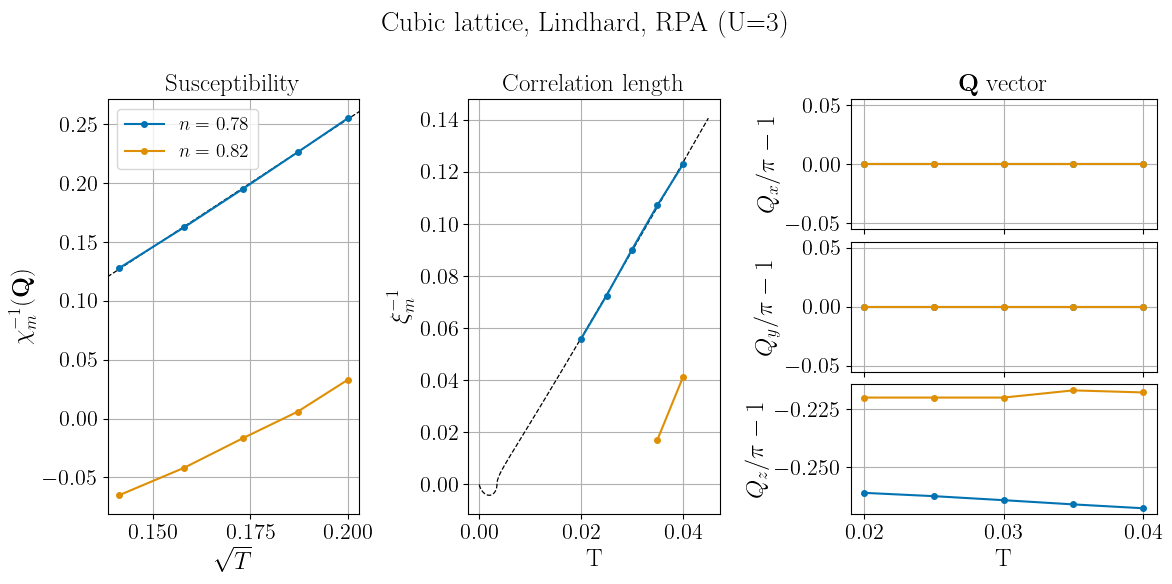

In [10]:

fig = None
for results in results_list:
    n = results['par_list'][0]['n']
    Tc_chi = results['fitchi']['Xc']
    gamma = results['fitchi']['b']
    Tc_xi = results['fitxi']['Xc']
    nu = results['fitxi']['b']
    print(f"n = {n} :\n chi: gamma = {gamma:.3f}, Tc = {Tc_chi:.3f}, xi: nu = {nu:.3f}, Tc = {Tc_xi:.3f}")
    fig, fit = pcut_chi(results, 'T', plot_Q=(1,1,1), x_exp=(0.5,1), fit=True,
                        title=title, label=rf'$n = {n:.4g}$', figure=fig)
    
    #_, axs = fig
    #for ax in axs[:2]:
    #    ax.set_xlim(left=0)
    #    ax.set_ylim(bottom=0)

plt.show()

In [6]:
"""
plot_sigma_kpath.py

Plot Re Σ(iω_n, k) along the simple-cubic high-symmetry path
    Γ(0,0,0) → X(π,0,0) → M(π,π,0) → Γ(0,0,0) → R(π,π,π)

for a selection of Matsubara frequencies.

Usage
-----
    fig, ax = plot_sigma_kpath(scba, n_iw_plot=[0, 1, 2, 5, 10, 20])
    fig.savefig('sigma_kpath.pdf', bbox_inches='tight')

Conventions assumed
-------------------
- scba.S_iwk      : (niw, Nk_ibz)   complex128, self-energy on IBZ
- scba.lat.k_vecs : (Nk_ibz, 3)     float, IBZ k-points in [0, 2pi]
- scba.lat.ibz_pos: (Nk_full,)      int,   maps full-BZ flat index -> IBZ index
- scba._last_beta : float            set by scba.run()
"""

import numpy as np
import matplotlib
matplotlib.rcParams['text.usetex'] = False   # use mathtext, not latex binary
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker


# ── high-symmetry points, simple cubic, k in [0, 2pi] ────────────────────────
_PI = np.pi
HS = {
    'G': np.array([0.,   0.,   0.  ]),
    'X': np.array([_PI,  0.,   0.  ]),
    'M': np.array([_PI,  _PI,  0.  ]),
    'R': np.array([_PI,  _PI,  _PI ]),
}
PATH        = ['G', 'X', 'M', 'G', 'R']
PATH_LABELS = [r'$\Gamma$', r'$X$', r'$M$', r'$\Gamma$', r'$R$']


def _build_path(n_pts_per_seg=120):
    """
    Return
      path_k  : (N, 3)        k-vectors along the path (not wrapped)
      arc     : (N,)          cumulative arc length
      hs_arc  : (n_seg+1,)    arc length at each HS point
    """
    segs   = list(zip(PATH[:-1], PATH[1:]))
    parts  = []
    hs_arc = [0.0]

    for a, b in segs:
        k0, k1 = HS[a], HS[b]
        ts     = np.linspace(0., 1., n_pts_per_seg, endpoint=False)
        parts.append(k0 + ts[:, None] * (k1 - k0))
        hs_arc.append(hs_arc[-1] + np.linalg.norm(k1 - k0))

    parts.append(HS[PATH[-1]][None, :])
    path_k = np.vstack(parts)
    diffs  = np.diff(path_k, axis=0)
    arc    = np.concatenate([[0.], np.cumsum(np.linalg.norm(diffs, axis=1))])
    return path_k, arc, np.array(hs_arc)


def _path_to_ibz(path_k, ibz_pos, nk):
    """
    Map each path k-point to the nearest IBZ index.

    ibz_pos has shape (Nk_full,) and maps full-BZ flat index -> IBZ index.
    We snap each path k to the nearest uniform grid point by rounding,
    then look up the IBZ index via ibz_pos.  Exact for any path point
    whose k-coordinates are multiples of 2pi/nk (all HS points satisfy this).
    """
    dk       = 2. * _PI / nk
    grid_idx = np.rint(path_k / dk).astype(int) % nk   # (N, 3)
    flat     = (grid_idx[:, 0] * nk + grid_idx[:, 1]) * nk + grid_idx[:, 2]
    return ibz_pos[flat]                                 # (N,)  IBZ indices


def plot_sigma_kpath(scba, n_iw_plot=None, n_pts_per_seg=120):
    """
    Parameters
    ----------
    scba          : converged SCBA instance
    n_iw_plot     : list of Matsubara indices to plot
                    (default: 0, 1 plus 6 log-spaced up to niw//4)
    n_pts_per_seg : k-points sampled per path segment

    Returns
    -------
    fig, ax
    """
    beta    = scba._last_beta
    niw     = scba.niw
    nk      = scba.nk
    ibz_pos = scba.lat.ibz_pos    # (Nk_full,)
    S_iwk   = scba.S_iwk          # (niw, Nk_ibz)

    # ── default frequency selection ──────────────────────────────────────────
    if n_iw_plot is None:
        hi = max(niw // 4, 6)
        n_iw_plot = sorted(set(
            [0, 1] + list(
                np.unique(np.logspace(0, np.log10(hi), 6)
                          .astype(int).clip(0, niw - 1))
            )
        ))[:8]

    # ── path and IBZ mapping ─────────────────────────────────────────────────
    path_k, arc, hs_arc = _build_path(n_pts_per_seg)
    ibz_idx = _path_to_ibz(path_k, ibz_pos, nk)         # (N,)

    # ── Matsubara frequencies ────────────────────────────────────────────────
    omega_n = (2 * np.arange(niw) + 1) * np.pi / beta

    # ── colour map ───────────────────────────────────────────────────────────
    cmap   = plt.get_cmap('plasma')
    n_freq = len(n_iw_plot)
    colors = [cmap(0.1 + 0.8 * i / max(n_freq - 1, 1)) for i in range(n_freq)]

    # ── figure ───────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(7.5, 4.2))

    for color, n in zip(colors, n_iw_plot):
        ReS = S_iwk[n].real[ibz_idx]
        lw  = 2.0 if n <= 1 else 1.3
        ax.plot(arc, ReS, color=color, lw=lw,
                label=r'$n=%d,\;i\omega_n=%.3f$' % (n, omega_n[n]))

    # ── high-symmetry verticals and ticks ────────────────────────────────────
    for x in hs_arc:
        ax.axvline(x, color='0.55', lw=0.9, ls='--', zorder=0)
    ax.axhline(0., color='0.4', lw=0.7, ls=':', zorder=0)

    ax.set_xticks(hs_arc)
    ax.set_xticklabels(PATH_LABELS, fontsize=13)
    ax.set_xlim(arc[0], arc[-1])

    ax.set_ylabel(r'$\mathrm{Re}\,\Sigma(i\omega_n,\mathbf{k})$', fontsize=12)

    v_str = ('v=%.2f' % scba._last_v) if hasattr(scba, '_last_v') else ''
    n_str = ('n=%.2f' % scba._last_n) if hasattr(scba, '_last_n') else ''
    ax.set_title(
        r'Re $\Sigma$ along $\Gamma$-X-M-$\Gamma$-R   '
        r'$\beta=%.0f$, %s, %s' % (beta, v_str, n_str),
        fontsize=11,
    )

    ax.legend(fontsize=8, ncol=2, framealpha=0.9,
              loc='best', title='Matsubara index', title_fontsize=8)
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
    fig.tight_layout()
    return fig, ax

SCBA: nk=50^3, niw=256, T=0.0100, mu=0.0000, v=0.100  [pyfftw]
Converged at step    8  diff=5.451e-12  mu=-0.538139
t′_eff(iω_n) from NNN disorder  [v=0.1000  nnn]
  ω_n → 0 extrapolation : t′(0) = -0.000876
  first 6 Matsubara values:
    iω_0 = 0.0314 :  t′ = -0.000881
    iω_1 = 0.0942 :  t′ = -0.000878
    iω_2 = 0.1571 :  t′ = -0.000864
    iω_3 = 0.2199 :  t′ = -0.000846
    iω_4 = 0.2827 :  t′ = -0.000828
    iω_5 = 0.3456 :  t′ = -0.000808


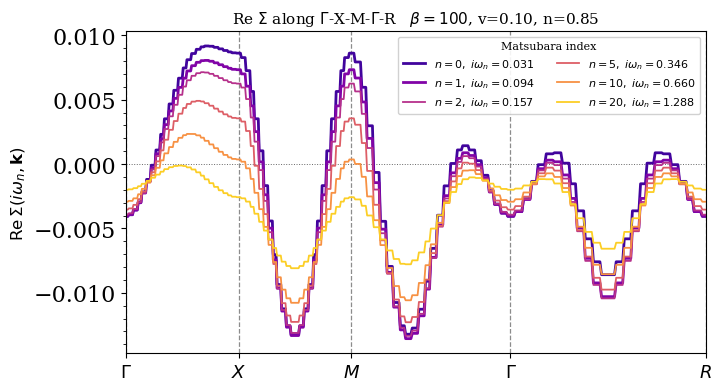

In [7]:
lat = LATTICE()
initialize_bz(lat, nk=50, refine=False, ibz=True)
scba = SCBA(lat, niw=256, nk=50)
scba.run(v=0.1, beta=1/0.01, n_goal=0.85)
scba.report_tprime(v=0.1)   # pretty-prints everything

fig, ax = plot_sigma_kpath(scba, n_iw_plot=[0, 1, 2, 5, 10, 20])
plt.show()

U: 3.000, n: 0.845: Completed 5 jobs in 2.6 seconds
U: 3.000, n: 0.845: Completed 5 jobs in 3.0 seconds
U: 3.000, n: 0.845: Completed 5 jobs in 3.4 seconds
U: 3.000, n: 0.845: Completed 5 jobs in 5.5 seconds
U: 3.000, n: 0.845: Completed 5 jobs in 4.7 seconds
U: 3.000, n: 0.845: Completed 5 jobs in 5.0 seconds
n = 0.845 :
 chi: gamma = 1.930, Tc = -0.057, xi: nu = 1.670, Tc = -0.066
n = 0.845 :
 chi: gamma = 1.759, Tc = -0.047, xi: nu = 1.607, Tc = -0.051
n = 0.845 :
 chi: gamma = 1.537, Tc = -0.038, xi: nu = 1.541, Tc = -0.039
n = 0.845 :
 chi: gamma = 1.644, Tc = -0.063, xi: nu = 1.698, Tc = -0.064
n = 0.845 :
 chi: gamma = 2.184, Tc = -0.072, xi: nu = 2.264, Tc = -0.071
n = 0.845 :
 chi: gamma = 1.989, Tc = -0.057, xi: nu = 1.983, Tc = -0.062


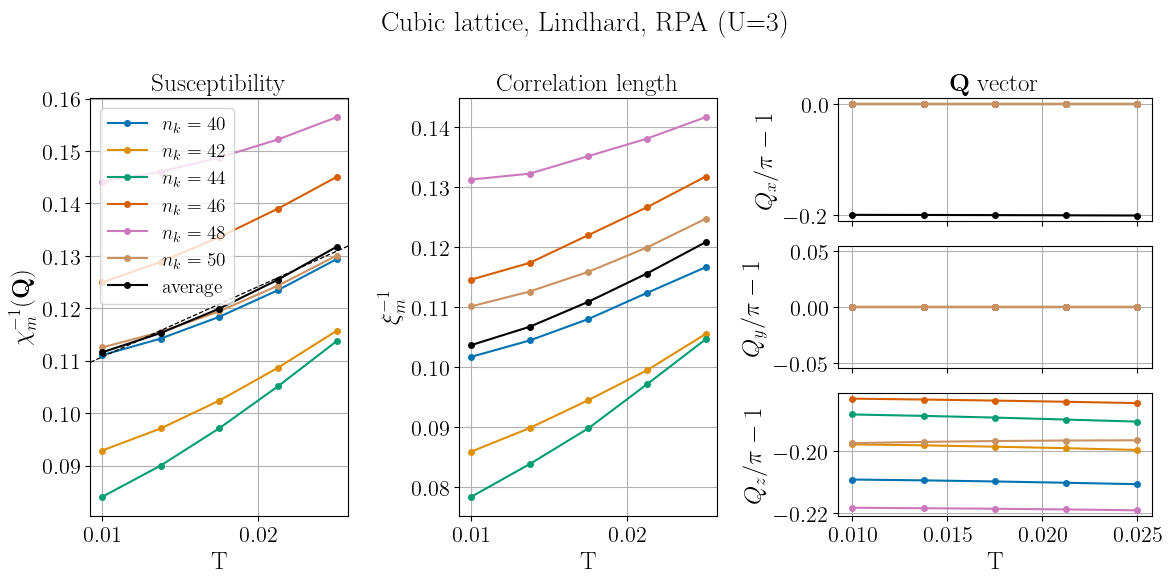

In [ ]:
U = 3
n_list = 0.857
T_list = np.linspace(0.01, 0.025, 5)
title = f'Cubic lattice, Lindhard, RPA (U={U})'

nk_list = np.arange(90, 101, 2)

v = 0.1
niw = 1024
results_list = []
for nk in nk_list:

    lat = LATTICE()
    initialize_bz(lat, nk=nk, refine=False, ibz=True)
    scba = SCBA(lat, niw, nk)

    inputs = [{'v': v, 'beta': 1/T, 'n_goal': n, 'verbose': False} for T in T_list]
    S_list = run_parallel(scba.run, inputs, workers=5)

    par_list = [{'U': U, 'n': n, 'T': T} for T in T_list]
    results_list.append(sweep_rpa(par_list, lat, nk=nk, niw=niw, S_list=S_list, get_xi=True, xi_range=[0,0,2e-2], fit=True, workers=5))

fig = None
for results in results_list:
    nk = results['nk']
    Tc_chi = results['fitchi']['Xc']
    gamma = results['fitchi']['b']
    Tc_xi = results['fitxi']['Xc']
    nu = results['fitxi']['b']
    print(f"n = {n} :\n chi: gamma = {gamma:.3f}, Tc = {Tc_chi:.3f}, xi: nu = {nu:.3f}, Tc = {Tc_xi:.3f}")
    fig, fit = pcut_chi(results, 'T', plot_Q=(1,1,1), x_exp=(1,1), fit=False,
                        title=title, label=rf'$n_k = {nk:.4g}$', figure=fig)
    
    #_, axs = fig
    #for ax in axs[:2]:
    #    ax.set_xlim(left=0)
    #    ax.set_ylim(bottom=0)

results_avg = results_list[-1].copy()
results_avg['invchi'] = sum([results['invchi'] for results in results_list])/len(results_list)
results_avg['invxi'] = sum([results['invxi'] for results in results_list])/len(results_list)
results_avg['Q'] = sum([results['Q'] for results in results_list])/len(results_list)

fig, fit = pcut_chi(results_avg, 'T', plot_Q=(0,0,1), x_exp=(1,1), fit=True,
                    title=title, label='average', figure=fig, color='black')

plt.show()

n = 0.855 :
 chi: gamma = 0.813, Tc = 0.021, xi: nu = 1.546, Tc = -0.130
n = 0.856 :
 chi: gamma = 1.059, Tc = 0.019, xi: nu = 1.543, Tc = -0.130


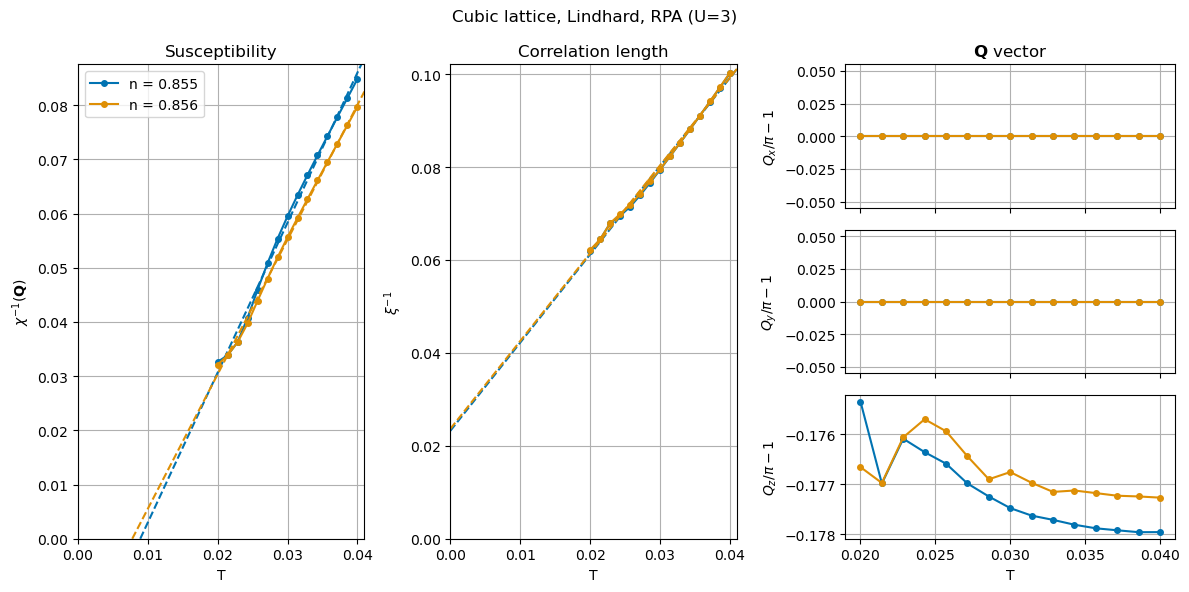

In [ ]:
fig = None
for results in results_list:
    n = results['par_list'][0]['n']
    Tc_chi = results['fitchi']['Xc']
    gamma = results['fitchi']['b']
    Tc_xi = results['fitxi']['Xc']
    nu = results['fitxi']['b']
    print(f"n = {n} :\n chi: gamma = {gamma:.3f}, Tc = {Tc_chi:.3f}, xi: nu = {nu:.3f}, Tc = {Tc_xi:.3f}")
    fig, fit = pcut_chi(results, 'T', plot_Q=(1,1,1), x_exp=(1,1), fit=True,
                        title=title, label=f'n = {n:.4g}', figure=fig)
    
    _, axs = fig
    for ax in axs[:2]:
        ax.set_xlim(left=0)
        ax.set_ylim(bottom=0)

plt.show()

Starting serial run at: 2026-06-08 09:24:14.669013
Starting serial run at: 2026-06-08 09:24:14.690620
Starting serial run at: 2026-06-08 09:24:14.720183
Starting serial run at: 2026-06-08 09:24:14.733919


Starting serial run at: 2026-06-08 09:24:14.898969


n: 0.845, U: 3.000: Completed 15 jobs in 84.7 seconds
n: 0.846, U: 3.000: Completed 15 jobs in 81.5 seconds
n: 0.847, U: 3.000: Completed 15 jobs in 82.1 seconds
n: 0.848, U: 3.000: Completed 15 jobs in 82.7 seconds
n: 0.849, U: 3.000: Completed 15 jobs in 82.2 seconds
n: 0.850, U: 3.000: Completed 15 jobs in 83.1 seconds
n = 0.845 :
 chi: gamma = 0.889, Tc = 0.011, xi: nu = 0.917, Tc = -0.002
n = 0.846 :
 chi: gamma = 1.072, Tc = 0.006, xi: nu = 1.038, Tc = -0.011
n = 0.847 :
 chi: gamma = 1.253, Tc = -0.014, xi: nu = 1.164, Tc = -0.026
n = 0.848 :
 chi: gamma = 1.413, Tc = -0.037, xi: nu = 1.278, Tc = -0.041
n = 0.849 :
 chi: gamma = 1.540, Tc = -0.054, xi: nu = 1.364, Tc = -0.051
n = 0.85 :
 chi: gamma = 1.632, Tc = -0.063, xi: nu = 1.411, Tc = -0.051


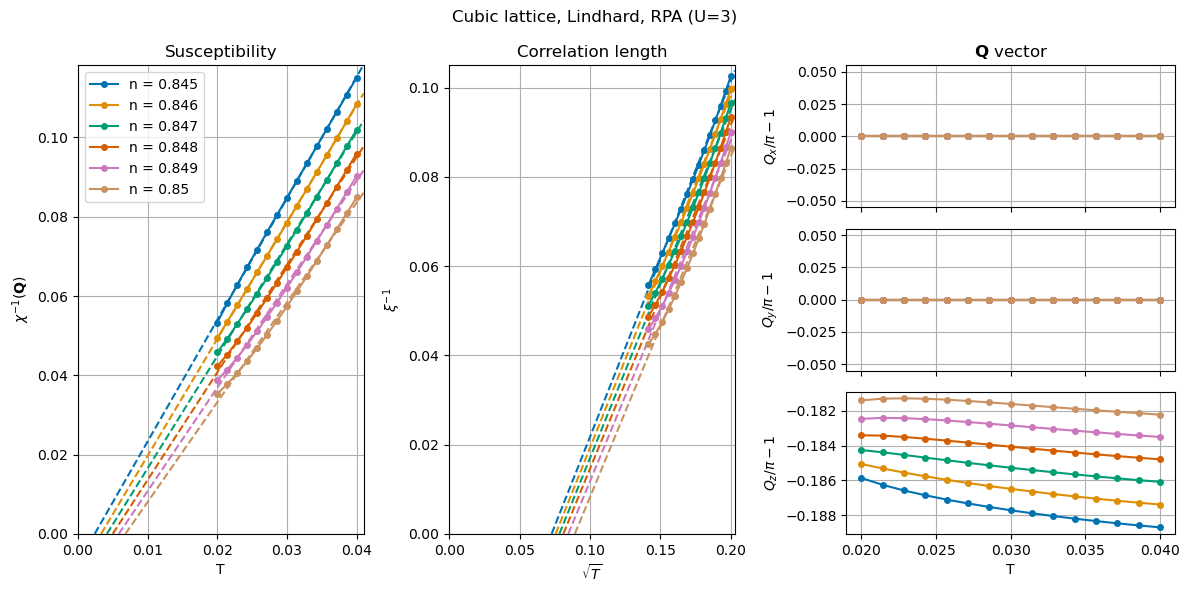

In [ ]:
U = 3
n_list = np.linspace(0.845, 0.85, 6)
T_list = np.linspace(0.02, 0.04, 15)
title = f'Cubic lattice, Lindhard, RPA (U={U})'

lat = LATTICE()
initialize_bz(lat, nk=150, refine=False, ibz=True)

Gamma = 0.05
niw = 256
results_list = []
for n in n_list:
    par_list = [{'U': U, 'n': n, 'T': T} for T in T_list]
    results_list.append(sweep_rpa(par_list, lat, niw=niw, S_list=-1j*Gamma, get_xi=True, xi_range=[0,0,2e-2], fit=True, workers=5))

fig = None
for results in results_list:
    n = results['par_list'][0]['n']
    Tc_chi = results['fitchi']['Xc']
    gamma = results['fitchi']['b']
    Tc_xi = results['fitxi']['Xc']
    nu = results['fitxi']['b']
    print(f"n = {n} :\n chi: gamma = {gamma:.3f}, Tc = {Tc_chi:.3f}, xi: nu = {nu:.3f}, Tc = {Tc_xi:.3f}")
    fig, fit = pcut_chi(results, 'T', plot_Q=(1,1,1), x_exp=(1,0.5), fit=True,
                        title=title, label=f'n = {n:.4g}', figure=fig)
    
    _, axs = fig
    for ax in axs[:2]:
        ax.set_xlim(left=0)
        ax.set_ylim(bottom=0)

plt.show()

0
1
2
3
4


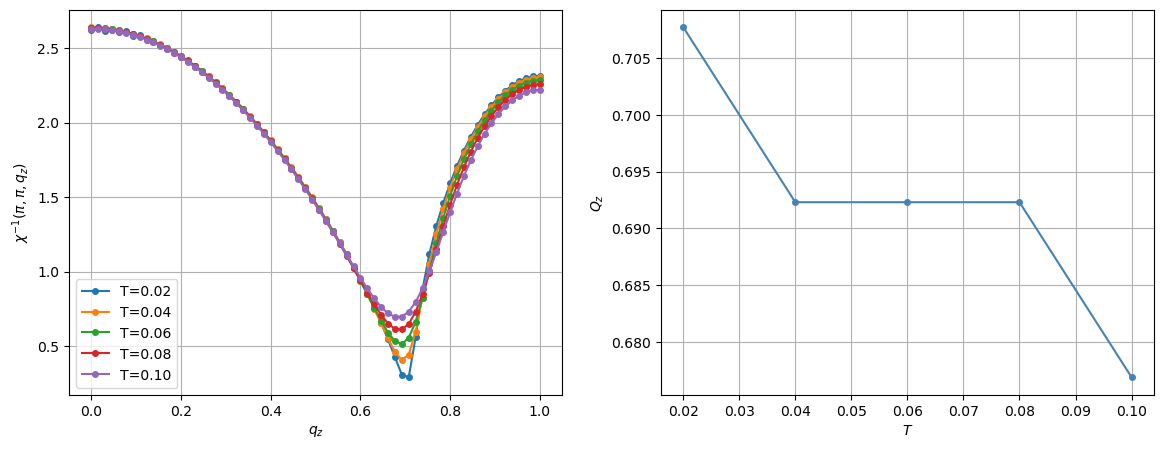

In [ ]:
n = 0.75
T_list = np.linspace(0.02, 0.1, 5)
U = 3
Gamma = 0.

nk = 130
niw = 256
lat = LATTICE()
lat.get_bz(nk, ibz=False)
lat.get_e_k()
#e_k = lat.unfold_f_k(lat.e_k)
e_k = lat.e_k
S_iwk, _ = get_iwk_arr(-1.j*Gamma, nk**3, niw=niw)

fig = plt.figure(figsize=(14, 5))
ax = [fig.add_subplot(1,2,1),
     fig.add_subplot(1,2,2)]

ax[0].set_xlabel('$q_z$')
ax[0].set_ylabel(r'$\chi^{-1}(\pi,\pi,q_z)$')

ax[1].set_xlabel('$T$')
ax[1].set_ylabel('$Q_z$')

Qz = []
for i, T in enumerate(T_list):
    mu = get_mu(lat.e_k, n, 1/T, S_iwk=-1.j*Gamma, ibz_w_k=lat.ibz_w_k)

    G_iwk = np.array(get_G_iwk(mu, 1/T, e_k, S_iwk, niw))
    
    invchi0_func = lambda niw: matsubara_rsp(1/T, G_iwk[:niw+1], nk)
    invchi0_grid = niw_extrapolate(invchi0_func, niw)

    #lat.fold_f_k(invchi0_grid)

    path_idx = []
    for j, k in enumerate(lat.k_vecs):
        if abs(k[0] - np.pi) < 1e-8:
            if abs(k[1] - np.pi) < 1e-8:
                if k[2] - np.pi < 1e-8:
                    path_idx.append(j)
    
    idx = np.argmin(invchi0_grid[path_idx])
    Qz.append(lat.k_vecs[path_idx][idx][-1]/np.pi)
    #if i%4 == 0:
    ax[0].plot(lat.k_vecs[path_idx][:,-1]/np.pi, invchi0_grid[path_idx]-U, 'o-', label=f'T={T:.2f}', markersize=4)
    print(i)

ax[1].plot(T_list, Qz, 'o-', markersize=4, color='steelblue')
ax[0].legend()

for a in ax:
    a.grid()
plt.show()

0
1
2
3
4


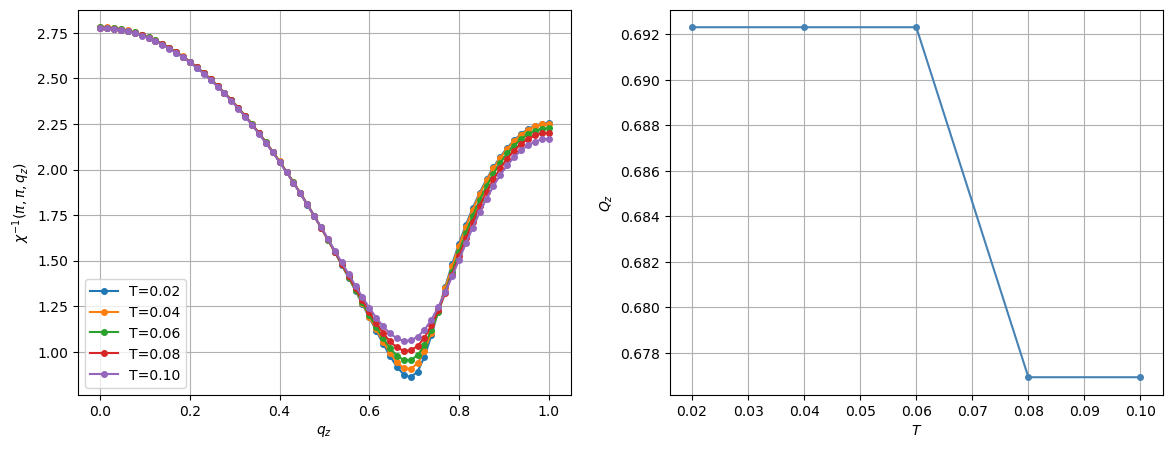

In [ ]:
n = 0.75
T_list = np.linspace(0.02, 0.1, 5)
U = 3
Gamma = 0.1

nk = 130
niw = 256
lat = LATTICE()
lat.get_bz(nk, ibz=False)
lat.get_e_k()
#e_k = lat.unfold_f_k(lat.e_k)
e_k = lat.e_k
S_iwk, _ = get_iwk_arr(-1.j*Gamma, nk**3, niw=niw)

fig = plt.figure(figsize=(14, 5))
ax = [fig.add_subplot(1,2,1),
     fig.add_subplot(1,2,2)]

ax[0].set_xlabel('$q_z$')
ax[0].set_ylabel(r'$\chi^{-1}(\pi,\pi,q_z)$')

ax[1].set_xlabel('$T$')
ax[1].set_ylabel('$Q_z$')

Qz = []
for i, T in enumerate(T_list):
    mu = get_mu(lat.e_k, n, 1/T, S_iwk=-1.j*Gamma, ibz_w_k=lat.ibz_w_k)

    G_iwk = np.array(get_G_iwk(mu, 1/T, e_k, S_iwk, niw))
    
    invchi0_func = lambda niw: matsubara_rsp(1/T, G_iwk[:niw+1], nk)
    invchi0_grid = niw_extrapolate(invchi0_func, niw)

    #lat.fold_f_k(invchi0_grid)

    path_idx = []
    for j, k in enumerate(lat.k_vecs):
        if abs(k[0] - np.pi) < 1e-8:
            if abs(k[1] - np.pi) < 1e-8:
                if k[2] - np.pi < 1e-8:
                    path_idx.append(j)
    
    idx = np.argmin(invchi0_grid[path_idx])
    Qz.append(lat.k_vecs[path_idx][idx][-1]/np.pi)
    #if i%4 == 0:
    ax[0].plot(lat.k_vecs[path_idx][:,-1]/np.pi, invchi0_grid[path_idx]-U, 'o-', label=f'T={T:.2f}', markersize=4)
    print(i)

ax[1].plot(T_list, Qz, 'o-', markersize=4, color='steelblue')
ax[0].legend()

for a in ax:
    a.grid()
plt.show()

In [ ]:
U = 3
n_list = np.linspace(0.84, 0.86, 5)
T_list = np.linspace(0.05, 0.2, 15)
par_list = [{'U': U, 'n': n, 'T': T_list} for n in n_list]
title = f'Cubic lattice, Lindhard, RPA (U={U})'

nk = 80
niw = 256
sweep_dict = [{'par_dict': par_dict, 'nk': nk, 'fit': True, 'S_iwk_list': -1j*0.1, 'method': 'matsubara', 'niw': niw, 'niw_extr': True, 'refine': True, 'refine_ratio': 2} for par_dict in par_list]
results_list = sweep_parallel(sweep_chirpa, sweep_dict, n_jobs=5)

fig = None
for results in results_list:
    n = results['par_list'][0]['n']
    Tc = results['Xc']
    ampl = results['ampl']
    gamma = results['gamma']
    print(f"n = {n} : ampl = {ampl}, exp = {gamma}, Tc = {Tc}")
    fig, fit = pcut_chi(results, 'T', plot_Q=(1,1,1), x_exp=1., fit=True,
                        title=title, label=f'n = {n}', figure=fig)
    
    _, axs = fig
    color = axs[0].lines[-1].get_color()
    #axs[0].plot(T_list**0.5, critical1(T_list, ampl, gamma, Tc))
    axs[0].scatter(-fit[1]/fit[0], 0., marker='*', s=100, edgecolors='black', color=color, zorder=100)
    #axs[1].axvline(np.sign(-fit[1]/fit[0])*(fit[1]/fit[0])**2, linestyle='--', color=color, zorder=100)

plt.show()

In [ ]:
U = 3
n_list = np.linspace(0.7, 1., 24)
T_list = np.linspace(0.1, 0.3, 10)

nk = 15

Gamma_list = [0., 0.05, 0.1]
for i, Gamma in enumerate(Gamma_list):

    file = f'{save_dir}/nTdiag_U3g{Gamma:.3f}'
    if os.path.exists(file):
        results = HDFread_list(file, ['Xc'])
        n_old = [par_list[0]['n'] for par_list in results['par_list']]
        Tc = np.interp(n_list, n_old, results['Xc'])
    else:
        print(f'file {file} does not exist!')

    par_list = []
    for j, n in enumerate(n_list):
        par_list.append({'U': U, 'n': n, 'T': T_list + max(Tc[j], 0.01)})

    sweep_dict = [{'par_dict': par_dict, 'nk': nk, 'fit': True, 'nk_avg': (10,1), 
                   'S_iwk_list': [1j*Gamma_list[i] for _ in T_list]} for par_dict in par_list]
    results = sweep_parallel(sweep_chirpa, sweep_dict, n_jobs=1, save_file=file)

    Tc = np.array([res['Xc'] for res in results])
    i_crit = np.argwhere(Tc > 0)[0,0]
    n_list = n_list[max(i_crit-2,0):]

: 

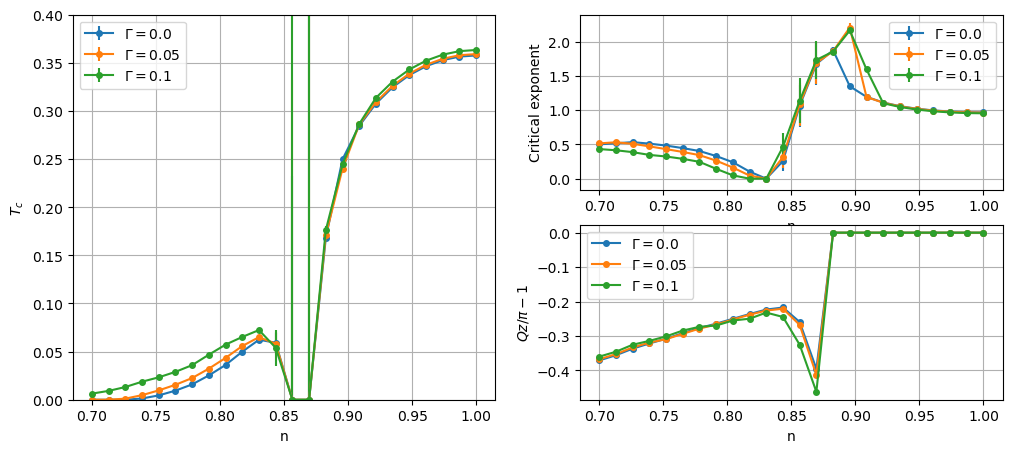

In [ ]:
fig = plt.figure(figsize=(12, 5))
ax = [fig.add_subplot(1,2,1),
      fig.add_subplot(2,2,2),
      fig.add_subplot(2,2,4)]
for a in ax:
    a.grid()
    a.set_xlabel('n')

ax[0].set_ylim(0., 0.4)

ax[0].set_ylabel('$T_c$')
ax[1].set_ylabel('Critical exponent')
ax[2].set_ylabel(r'$Qz/\pi-1$')

Gamma_list = [0., 0.05, 0.1]
for i, Gamma in enumerate(Gamma_list):

    results = HDFread_list(f'{save_dir}/nTdiag_U3g{Gamma:.3f}', 
                 ['Xc', 'Xc_err', 'gamma', 'gamma_err', 'Qc'])
    
    n_list = [par_list[0]['n'] for par_list in results['par_list']]
    Qz = [Q[-1]-1 for Q in results['Qc']]

    ax[0].errorbar(n_list, results['Xc'], results['Xc_err'], fmt='o-', label=f"$\Gamma={Gamma}$", markersize=4)
    ax[1].errorbar(n_list, results['gamma'], results['gamma_err'], fmt='o-', label=f"$\Gamma={Gamma}$", markersize=4)
    line = ax[2].plot(n_list, Qz, 'o-', label=f"$\Gamma={Gamma}$", markersize=4)

    color = line[0].get_color()
    n_crit = np.interp(0., results['Xc'], n_list)
    for a in ax:
        #a.axvline(n_crit, linestyle='--', color=color)
        a.legend()

    for a in ax:
        a.legend()

plt.show()

In [ ]:
U = 3
n_list = np.linspace(0.7, 1., 24)
T_list = np.linspace(0., 0.05, 6)

nk = 100

Gamma = 0.025
tp_list = [0.05, 0.1]
for i, tp in enumerate(tp_list):

    file = f'{save_dir}/nTdiag_U3g{Gamma:.3f}tp{tp:.2f}'
    if os.path.exists(file):
        results = HDFread_list(file, ['Xc'])
        n_old = [par_list[0]['n'] for par_list in results['par_list']]
        Tc = np.interp(n_list, n_old, results['Xc'])
    else:
        print(f'file {file} does not exist!')

    par_list = []
    for j, n in enumerate(n_list):
        par_list.append({'U': U, 'n': n, 'T': T_list + max(Tc[j], 0.005)})

    sweep_dict = [{'par_dict': par_dict, 'nk': nk, 'fit': True, 'nk_avg': (10,1), 'tp': tp,
                   'S_iwk_list': [1j*Gamma for _ in T_list]} for par_dict in par_list]
    results = sweep_parallel(sweep_chirpa, sweep_dict, n_jobs=6, save_file=file)

    Tc = np.array([res['Xc'] for res in results])
    i_crit = np.argwhere(Tc > 0)[0,0]
    n_list = n_list[max(i_crit-2,0):]

[Parallel(n_jobs=6)]: Using backend LokyBackend with 6 concurrent workers.
Starting serial run at: 2026-04-27 11:32:19.460754
Starting serial run at: 2026-04-27 11:32:19.460862
Starting serial run at: 2026-04-27 11:32:19.476135


Starting serial run at: 2026-04-27 11:32:19.517090
[Parallel(n_jobs=6)]: Done   1 tasks      | elapsed:  5.5min


Starting serial run at: 2026-04-27 11:37:48.664854


Starting serial run at: 2026-04-27 11:37:49.502659
[Parallel(n_jobs=6)]: Done   6 tasks      | elapsed:  5.8min


Starting serial run at: 2026-04-27 11:43:46.625501


...

Starting serial run at: 2026-04-27 12:07:12.018905


Starting serial run at: 2026-04-27 12:07:24.946133


Starting serial run at: 2026-04-27 12:07:25.619399
[Parallel(n_jobs=6)]: Done  13 tasks      | elapsed: 17.2min


Starting serial run at: 2026-04-27 12:12:50.348300
[Parallel(n_jobs=6)]: Done  16 out of  24 | elapsed: 17.7min remaining:  8.9min


Starting serial run at: 2026-04-27 12:13:25.034416
[Parallel(n_jobs=6)]: Done  19 out of  24 | elapsed: 23.3min remaining:  6.1min
[Parallel(n_jobs=6)]: Done  22 out of  24 | elapsed: 23.5min remaining:  2.1min
[Parallel(n_jobs=6)]: Done  24 out of  24 | elapsed: 23.6min finished


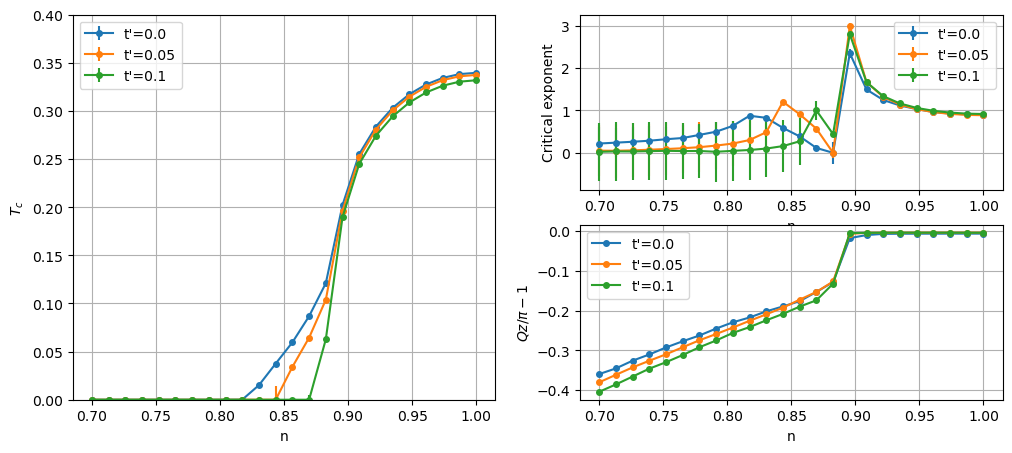

In [ ]:
fig = plt.figure(figsize=(12, 5))
ax = [fig.add_subplot(1,2,1),
      fig.add_subplot(2,2,2),
      fig.add_subplot(2,2,4)]
for a in ax:
    a.grid()
    a.set_xlabel('n')

ax[0].set_ylim(-0., 0.4)

ax[0].set_ylabel('$T_c$')
ax[1].set_ylabel('Critical exponent')
ax[2].set_ylabel(r'$Qz/\pi-1$')

Gamma = 0.025
tp_list = [0., 0.05, 0.1]
for i, tp in enumerate(tp_list):

    results = HDFread_list(f'{save_dir}/nTdiag_U3g{Gamma:.3f}tp{tp:.2f}', 
                 ['Xc', 'Xc_err', 'gamma', 'gamma_err', 'Qc'])
    
    n_list = [par_list[0]['n'] for par_list in results['par_list']]
    Qz = [Q[-1]-1 for Q in results['Qc']]

    ax[0].errorbar(n_list, results['Xc'], results['Xc_err'], fmt='o-', label=f"t'={tp}", markersize=4)
    ax[1].errorbar(n_list, results['gamma'], results['gamma_err'], fmt='o-', label=f"t'={tp}", markersize=4)
    line = ax[2].plot(n_list, Qz, 'o-', label=f"t'={tp}", markersize=4)
    color = line[0].get_color()

    n_crit = np.interp(0., results['Xc'], n_list)
    for a in ax:
        #a.axvline(n_crit, linestyle='--', color=color)
        a.legend()


plt.savefig(f'{save_dir}/g{Gamma:.3f}postp.png', dpi=100)
plt.show()

SCBA: nk=100^2, beta=10.00, mu=0.0000, scatt. pot.=1.000
Converged at step 15 with diff = 4.495e-11
0.538182094297202


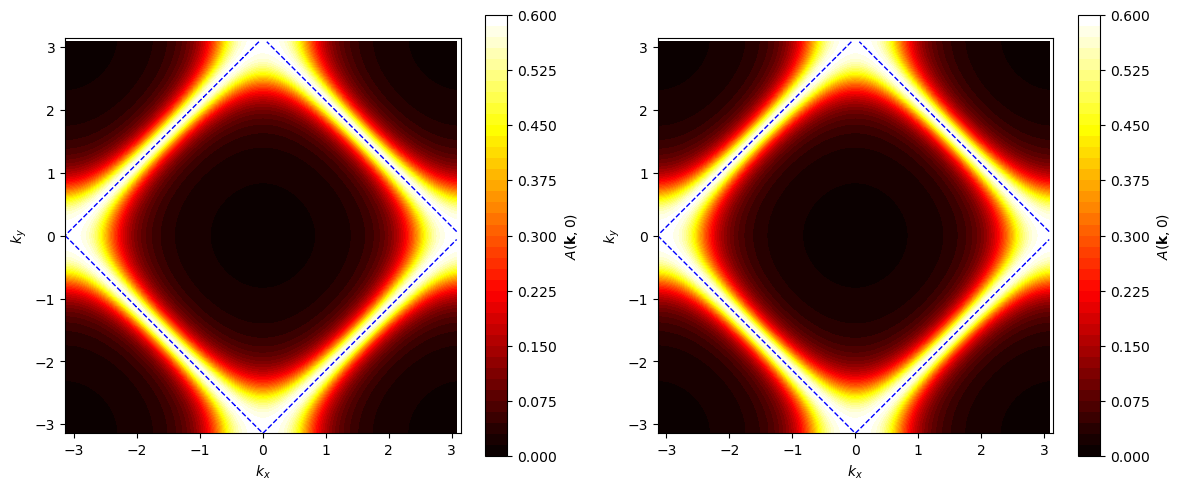

In [ ]:
square = LATTICE(dim=2)
nk = 100

square.get_e_k(nk)
eps = square.e_k.data[:,0,0].real
eps = eps.reshape(nk, nk)
eps = np.roll(np.roll(eps, nk//2, axis=0), nk//2, axis=1)

_, k_arr = square.get_k_mesh(nk)
kx = k_arr[:, 0].reshape(nk, nk) - np.pi
ky = k_arr[:, 1].reshape(nk, nk) - np.pi

T = 0.1
n = 1
mu = get_mu(square.e_k, n, 1/T)
v = 1.

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

square.get_e_k(nk=nk)
scba = SCBA(square, 1/T, nk=nk)
scba.run(v=v, n_goal=n, constant=True)
A1 = get_A_iw0k(scba.G_iwk).reshape(nk, nk)

S_iw = GfImFreq(beta=1/T, statistic='Fermion', n_points=scba.n_iw, target_shape=[1,1])
S_iw.data[:, 0, 0] = scba.S_iwk.data[:, :, 0, 0].mean(axis=1)

# Pade continue to real axis at omega=0
w_mesh = MeshReFreq(w_min=0.0, w_max=0.0, n_w=1)
S_w = GfReFreq(mesh=w_mesh, target_shape=[1,1])
S_w.set_from_pade(S_iw, n_points=60)

Gamma_eff = -S_w.data[0, 0, 0].imag
print(Gamma_eff)

A2 = (1/np.pi) * Gamma_eff / (Gamma_eff**2 + (eps - mu)**2)

vmax = max(A1.max(), A2.max())
vmin = min(A1.min(), A2.min())

ax = axes[0]
cf1 = axes[0].contourf(kx, ky, A1, levels=50, cmap='hot', vmax=vmax, vmin=vmin)
plt.colorbar(cf1, ax=ax, label=r'$A(\mathbf{k}, 0)$')
ax.contour(kx, ky, eps, levels=[mu], colors='blue', linewidths=1, linestyles='--')
ax.set_xlim(-np.pi, np.pi)
ax.set_ylim(-np.pi, np.pi)
ax.set_xlabel(r'$k_x$')
ax.set_ylabel(r'$k_y$')
ax.set_aspect('equal')

ax = axes[1]
cf2 = axes[1].contourf(kx, ky, A2, levels=50, cmap='hot', vmax=vmax, vmin=vmin)
plt.colorbar(cf2, ax=ax, label=r'$A(\mathbf{k}, 0)$')
ax.contour(kx, ky, eps, levels=[mu], colors='blue', linewidths=1, linestyles='--')
ax.set_xlim(-np.pi, np.pi)
ax.set_ylim(-np.pi, np.pi)
ax.set_xlabel(r'$k_x$')
ax.set_ylabel(r'$k_y$')
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

SCBA: nk=100^2, beta=10.00, mu=0.0000, scatt. pot.=1.000
Converged at step 11 with diff = 4.054e-11
0.1379977548712244


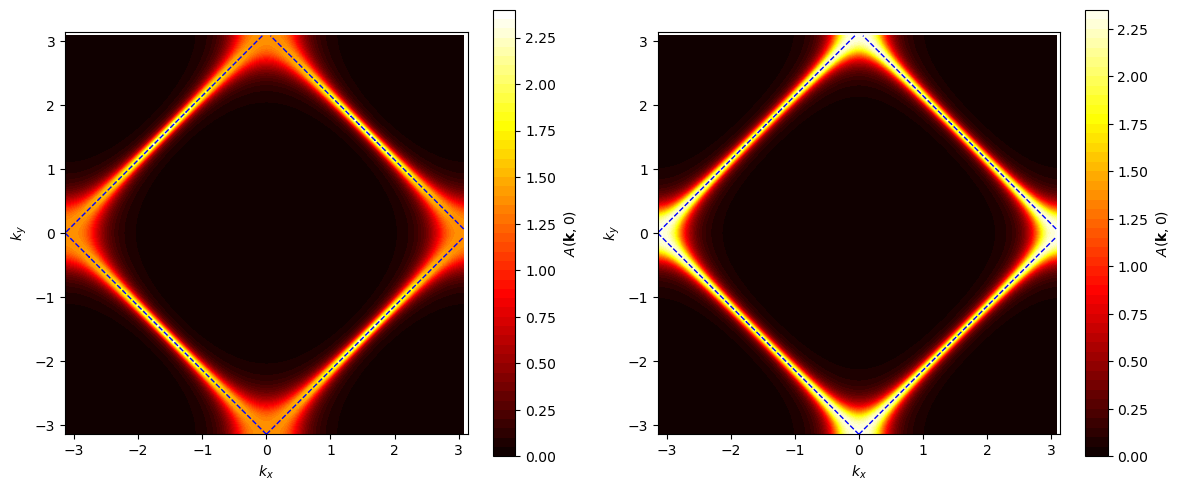

In [ ]:
square = LATTICE(dim=2)
nk = 100

square.get_e_k(nk)
eps = square.e_k.data[:,0,0].real
eps = eps.reshape(nk, nk)
eps = np.roll(np.roll(eps, nk//2, axis=0), nk//2, axis=1)

_, k_arr = square.get_k_mesh(nk)
kx = k_arr[:, 0].reshape(nk, nk) - np.pi
ky = k_arr[:, 1].reshape(nk, nk) - np.pi

T = 0.1
n = 1
mu = get_mu(square.e_k, n, 1/T)
v = 1.
xi = 0.2

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

square.get_e_k(nk=nk)
scba = SCBA(square, 1/T, xi=xi, nk=nk)
scba.run(v=v, n_goal=n, constant=False)
A1 = get_A_iw0k(scba.G_iwk).reshape(nk, nk)

S_iw = GfImFreq(beta=1/T, statistic='Fermion', n_points=scba.n_iw, target_shape=[1,1])
S_iw.data[:,0,0] = scba.S_iwk.data[:,:,0,0].mean(axis=1)

# Pade continue to real axis at omega=0
w_mesh = MeshReFreq(w_min=0.0, w_max=0.0, n_w=1)
S_w = GfReFreq(mesh=w_mesh, target_shape=[1,1])
S_w.set_from_pade(S_iw, n_points=60)

Gamma_eff = -S_w.data[0,0,0].imag
print(Gamma_eff)

A2 = (1/np.pi) * Gamma_eff / (Gamma_eff**2 + (eps - mu)**2)

vmax = max(A1.max(), A2.max())
vmin = min(A1.min(), A2.min())

ax = axes[0]
cf1 = axes[0].contourf(kx, ky, A1, levels=50, cmap='hot', vmax=vmax, vmin=vmin)
plt.colorbar(cf1, ax=ax, label=r'$A(\mathbf{k}, 0)$')
ax.contour(kx, ky, eps, levels=[mu], colors='blue', linewidths=1, linestyles='--')
ax.set_xlim(-np.pi, np.pi)
ax.set_ylim(-np.pi, np.pi)
ax.set_xlabel(r'$k_x$')
ax.set_ylabel(r'$k_y$')
ax.set_aspect('equal')

ax = axes[1]
cf2 = axes[1].contourf(kx, ky, A2, levels=50, cmap='hot', vmax=vmax, vmin=vmin)
plt.colorbar(cf2, ax=ax, label=r'$A(\mathbf{k}, 0)$')
ax.contour(kx, ky, eps, levels=[mu], colors='blue', linewidths=1, linestyles='--')
ax.set_xlim(-np.pi, np.pi)
ax.set_ylim(-np.pi, np.pi)
ax.set_xlabel(r'$k_x$')
ax.set_ylabel(r'$k_y$')
ax.set_aspect('equal')

plt.tight_layout()
plt.show()